# Paris-Duchesse Project - Part 1: Linear Relaxation

**Course:** Mathematics of Data Science - M1 IDD  
**Year:** 2025/2026  
**Authors:** Franck CHEN, Clémence JIN

---

## Introduction

This project optimizes the relocation plan during the renovation of Paris Duchesse University.

### Problem Data

- **12 offices:** A1, A2, B1, B2, B3, C1, C2, D1, D2, D3, E1, E2
- **18 people** distributed across 5 services:
  - Presidency (P): people 0-3
  - Optimization (O): people 4-5
  - Mathematics (M): people 6-9
  - Students (S): people 10-13
  - Theoretical CS (T): people 14-17
- **6 phases** (0 to 5) with sequential renovations:
  - Phase 0: Initial state (wing E closed)
  - Phase 1: Wing E opens, wing B under renovation
  - Phase 2: Wing D under renovation
  - Phase 3: Wing C under renovation
  - Phase 4: Wing A under renovation
  - Phase 5: Final state

### Initial Positions (Phase 0)

| Service | People | Office |
|---------|--------|--------|
| P | 0, 1 | A1 |
| P | 2, 3 | A2 |
| O | 4 | B1 |
| O | 5 | B3 |
| M | 6, 7 | D3 |
| M | 8 | D2 |
| M | 9 | B1 |
| S | 10, 11 | B2 |
| S | 12, 13 | C2 |
| T | 14 | D1 |
| T | 15 | B3 |
| T | 16, 17 | C1 |

### Final Assignments (Phase 5)

| Service | Offices |
|---------|----------|
| P | A1, A2 |
| O | E1, E2 |
| M | B1, B2, B3 |
| S | C1, C2 |
| T | D1, D2, D3 |

# Part 1 : Linear programming relaxation
## Question 1 Linear Program

### 1.1 Imports and configuration

In [33]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Office configuration
offices = ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'D1', 'D2', 'D3', 'E1', 'E2']
n_offices = 12
n_people = 18
n_phases = 6

# Services
services = {
    'P': [0, 1, 2, 3],           # Presidency
    'O': [4, 5],                  # Optimization
    'M': [6, 7, 8, 9],           # Mathematics
    'S': [10, 11, 12, 13],       # Students
    'T': [14, 15, 16, 17]        # Theoretical CS
}

# Mapping office -> index
office_idx = {b: i for i, b in enumerate(offices)}

print(f"Number of offices: {n_offices}")
print(f"Number of people: {n_people}")
print(f"Number of phases: {n_phases}")
print(f"\nVariables z: {n_people * n_offices * n_phases}")
print(f"Variables d: {n_people * n_offices * (n_phases-1)}")
print(f"Total variables: {n_people * n_offices * n_phases + n_people * n_offices * (n_phases-1)}")


Number of offices: 12
Number of people: 18
Number of phases: 6

Variables z: 1296
Variables d: 1080
Total variables: 2376


### 1.2 Definition of Variables, Constraints and Objective


In [34]:
# Decision variables
z = cp.Variable((n_people, n_offices, n_phases), nonneg=True)
d = cp.Variable((n_people, n_offices, n_phases-1), nonneg=True)

# Linearized objective function
objective = cp.Minimize(0.5 * cp.sum(d))

# List of constraints
constraints = []

print("="*60)
print("PROBLEM DEFINITION")
print("="*60)
print(f"Objective defined: minimize 0.5 * sum(d)\n")

count_c7 = 0
for k in range(n_people):
    for i in range(n_offices):
        for p in range(n_phases):
            constraints.append(z[k, i, p] <= 1)
            count_c7 += 1

print(f"C7 constraints (z <= 1) added: {count_c7}")
print(f"\nBound constraints (C7):")
print(f"  - z >= 0: handled by nonneg=True ({n_people * n_offices * n_phases} implicit constraints)")
print(f"  - z <= 1: explicitly added ({count_c7} constraints)")
print(f"  - d >= 0: handled by nonneg=True ({n_people * n_offices * (n_phases-1)} implicit constraints)")
print(f"\nExplicit constraints added: {len(constraints)}")


PROBLEM DEFINITION
Objective defined: minimize 0.5 * sum(d)

C7 constraints (z <= 1) added: 1296

Bound constraints (C7):
  - z >= 0: handled by nonneg=True (1296 implicit constraints)
  - z <= 1: explicitly added (1296 constraints)
  - d >= 0: handled by nonneg=True (1080 implicit constraints)

Explicit constraints added: 1296


In [35]:
# C1: Each person is in exactly 1 office per phase
for k in range(n_people):
    for p in range(n_phases):
        constraints.append(cp.sum(z[k, :, p]) == 1)

print(f"C1 - Uniqueness constraints: {n_people * n_phases}")

# C2: Maximum 2 people per office
for i in range(n_offices):
    for p in range(n_phases):
        constraints.append(cp.sum(z[:, i, p]) <= 2)

print(f"C2 - Capacity constraints: {n_offices * n_phases}")
print(f"Partial total: {len(constraints)} constraints")


C1 - Uniqueness constraints: 108
C2 - Capacity constraints: 72
Partial total: 1476 constraints


In [36]:
# C3: Linearization of |z[k,i,p] - z[k,i,p+1]|
for k in range(n_people):
    for i in range(n_offices):
        for p in range(n_phases - 1):
            # d[k,i,p] >= z[k,i,p] - z[k,i,p+1]
            constraints.append(d[k, i, p] >= z[k, i, p] - z[k, i, p+1])
            # d[k,i,p] >= z[k,i,p+1] - z[k,i,p]
            constraints.append(d[k, i, p] >= z[k, i, p+1] - z[k, i, p])

print(f"C3 - Linearization constraints: {2 * n_people * n_offices * (n_phases-1)}")
print(f"Partial total: {len(constraints)} constraints")


C3 - Linearization constraints: 2160
Partial total: 3636 constraints


In [37]:
# C4: Closed offices (renovations + unbuilt wing E)
closed_offices = {
    0: ['E1', 'E2'],             # Phase 0: wing E not built
    1: ['B1', 'B2', 'B3'],      # Phase 1: wing B renovation
    2: ['D1', 'D2', 'D3'],      # Phase 2: wing D renovation
    3: ['C1', 'C2'],             # Phase 3: wing C renovation
    4: ['A1', 'A2']              # Phase 4: wing A renovation
}

count_c4 = 0
for phase, offices_phase in closed_offices.items():
    for b in offices_phase:
        idx = office_idx[b]
        for k in range(n_people):
            constraints.append(z[k, idx, phase] == 0)
            count_c4 += 1

print(f"C4 - Closed office constraints:")
print(f"  Phase 0 (E1, E2): {18 * 2}")
print(f"  Phase 1 (B1, B2, B3): {18 * 3}")
print(f"  Phase 2 (D1, D2, D3): {18 * 3}")
print(f"  Phase 3 (C1, C2): {18 * 2}")
print(f"  Phase 4 (A1, A2): {18 * 2}")
print(f"  Total C4 constraints: {count_c4}")
print(f"Partial total: {len(constraints)} constraints")


C4 - Closed office constraints:
  Phase 0 (E1, E2): 36
  Phase 1 (B1, B2, B3): 54
  Phase 2 (D1, D2, D3): 54
  Phase 3 (C1, C2): 36
  Phase 4 (A1, A2): 36
  Total C4 constraints: 216
Partial total: 3852 constraints


In [38]:
# C5: Initial positions (phase 0)
initial_positions = {
    0: 'A1', 1: 'A1',           # Presidency
    2: 'A2', 3: 'A2',           # Presidency
    4: 'B1', 5: 'B3',           # Optimization
    6: 'D3', 7: 'D3',           # Mathematics
    8: 'D2', 9: 'B1',           # Mathematics
    10: 'B2', 11: 'B2',         # Students
    12: 'C2', 13: 'C2',         # Students
    14: 'D1', 15: 'B3',         # Theoretical CS
    16: 'C1', 17: 'C1'          # Theoretical CS
}

for k, b in initial_positions.items():
    idx = office_idx[b]
    constraints.append(z[k, idx, 0] == 1)

print(f"C5 - Initial positions: {len(initial_positions)}")

# C6: Final assignments by service (phase 5)
final_assignments = {
    'P': ['A1', 'A2'],          # Presidency → wing A
    'M': ['B1', 'B2', 'B3'],    # Mathematics → wing B
    'S': ['C1', 'C2'],          # Students → wing C
    'T': ['D1', 'D2', 'D3'],    # Theoretical CS → wing D
    'O': ['E1', 'E2']           # Optimization → wing E
}

count_c6 = 0

# Base constraints: each person must be in one office of their service
for service, offices_service in final_assignments.items():
    people = services[service]
    office_indices = [office_idx[b] for b in offices_service]
    for k in people:
        constraints.append(cp.sum([z[k, i, 5] for i in office_indices]) == 1)
        count_c6 += 1

print(f"C6 - Final assignments (base): {count_c6}")

# Additional constraints for exact distribution per office
count_c6_supp = 0

# Mathematics (M) in wing B: 1 in B1, 2 in B2, (1 in B3 implicit)
constraints.append(
    cp.sum([z[k, office_idx['B1'], 5] for k in services['M']]) == 1
)
constraints.append(
    cp.sum([z[k, office_idx['B2'], 5] for k in services['M']]) == 2
)
count_c6_supp += 2

# Theoretical CS (T) in wing D: 1 in D1, 2 in D2, (1 in D3 implicit)
constraints.append(
    cp.sum([z[k, office_idx['D1'], 5] for k in services['T']]) == 1
)
constraints.append(
    cp.sum([z[k, office_idx['D2'], 5] for k in services['T']]) == 2
)
count_c6_supp += 2

# Optimization (O) in wing E: 1 in E1, (1 in E2 implicit)
constraints.append(
    cp.sum([z[k, office_idx['E1'], 5] for k in services['O']]) == 1
)
count_c6_supp += 1

print(f"C6 - Exact distribution (additional): {count_c6_supp}")
print(f"C6 - Total: {count_c6 + count_c6_supp}")
print(f"\n=== TOTAL CONSTRAINTS: {len(constraints)} ===")


C5 - Initial positions: 18
C6 - Final assignments (base): 18
C6 - Exact distribution (additional): 5
C6 - Total: 23

=== TOTAL CONSTRAINTS: 3893 ===


## Question 2 : Compute a solution for your problem and its dual.

### 2.1 Solving with CVXPY


In [39]:
# Solving the primal problem
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.ECOS, verbose=True)
z_q1 = z.value

print("\n" + "="*70)
print("PRIMAL PROBLEM SOLUTION RESULTS")
print("="*70)
print(f"Status: {prob.status}")
print(f"Optimal objective value: {result:.6f}")
print(f"Number of moves: {result:.2f}")
print("="*70)


(CVXPY) Jan 28 03:11:06 AM: Your problem has 2376 variables, 3893 constraints, and 0 parameters.


                                     CVXPY                                     
                                     v1.7.5                                    


(CVXPY) Jan 28 03:11:06 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 28 03:11:06 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 28 03:11:06 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 28 03:11:06 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 28 03:11:06 AM: Compiling problem (target solver=ECOS).
(CVXPY) Jan 28 03:11:06 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jan 28 03:11:06 AM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jan 28 03:11:07 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 28 03:11:07 AM: Applying reduction ConeMatrixStuffing
/Users/macchenf/anaconda3/envs/opt_env/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
(CVXPY) Jan 28 03:11:10 AM: Applying reduction ECOS
(CVXPY) Jan 28 03:11:11 AM: Finished problem compilation (took 5.203e+00 seconds).
(CVXPY) Jan 28 03:11:11 AM: Invoking solver ECOS  to obtain a solution.
(CVXPY) Jan 28 03:11:11 AM: Problem status: optimal
(CVXPY) Jan 28 03:11:11 AM: Optimal value: 3.000e+01
(CVXPY) Jan 28 03:11:11 AM: Compilation took 5.203e+00 seconds
(CVXPY) Jan 28 03:11:11 AM: Solver (including time spent in interface) took 2.320e-02 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------

ECOS 2.0.10 - (C) embotech GmbH, Zurich Switzerland, 2012-15. Web: www.embotech.com/ECOS

It     pcost       dcost      gap   pres   dres    k/t    mu     step   sigma     IR    |   BT
 0  +1.937e-16  -1.440e+03  +1e+04  7e-01  1e+00  1e+00  2e+00    ---    ---    1  1  - |  -  - 
 1  -2.566e+00  -6.622e+02  +1e+04  3e-01  5e-01  3e+00  2e+00  0.3408  4e-01   1  0  1 |  0  0
 2  +1.762e+01  -6.660e+01  +3e+03  4e-02  5e-02  3e+00  6e-01  0.8996  2e-01   1  1  1 |  0  0
 3  +2.740e+01  -4.358e+00  +1e+03  1e-02  2e-02  1e+00  2e-01  0.6422  1e-01   1  1  1 |  0  0
 4  +2.913e+01  +1.224e+01  +8e+02  7e-03  8e-03  5e-01  1e-01  0.5048  1e-01   1  1  1 |  0  0
 5  +3.002e+01  +2.429e+01  +3e+02  2e-03  2e-03  1e-01  5e-02  0.7938  2e-01   1  1  1 |  0 

### 2.2 Visualization of Office Occupancy by Person


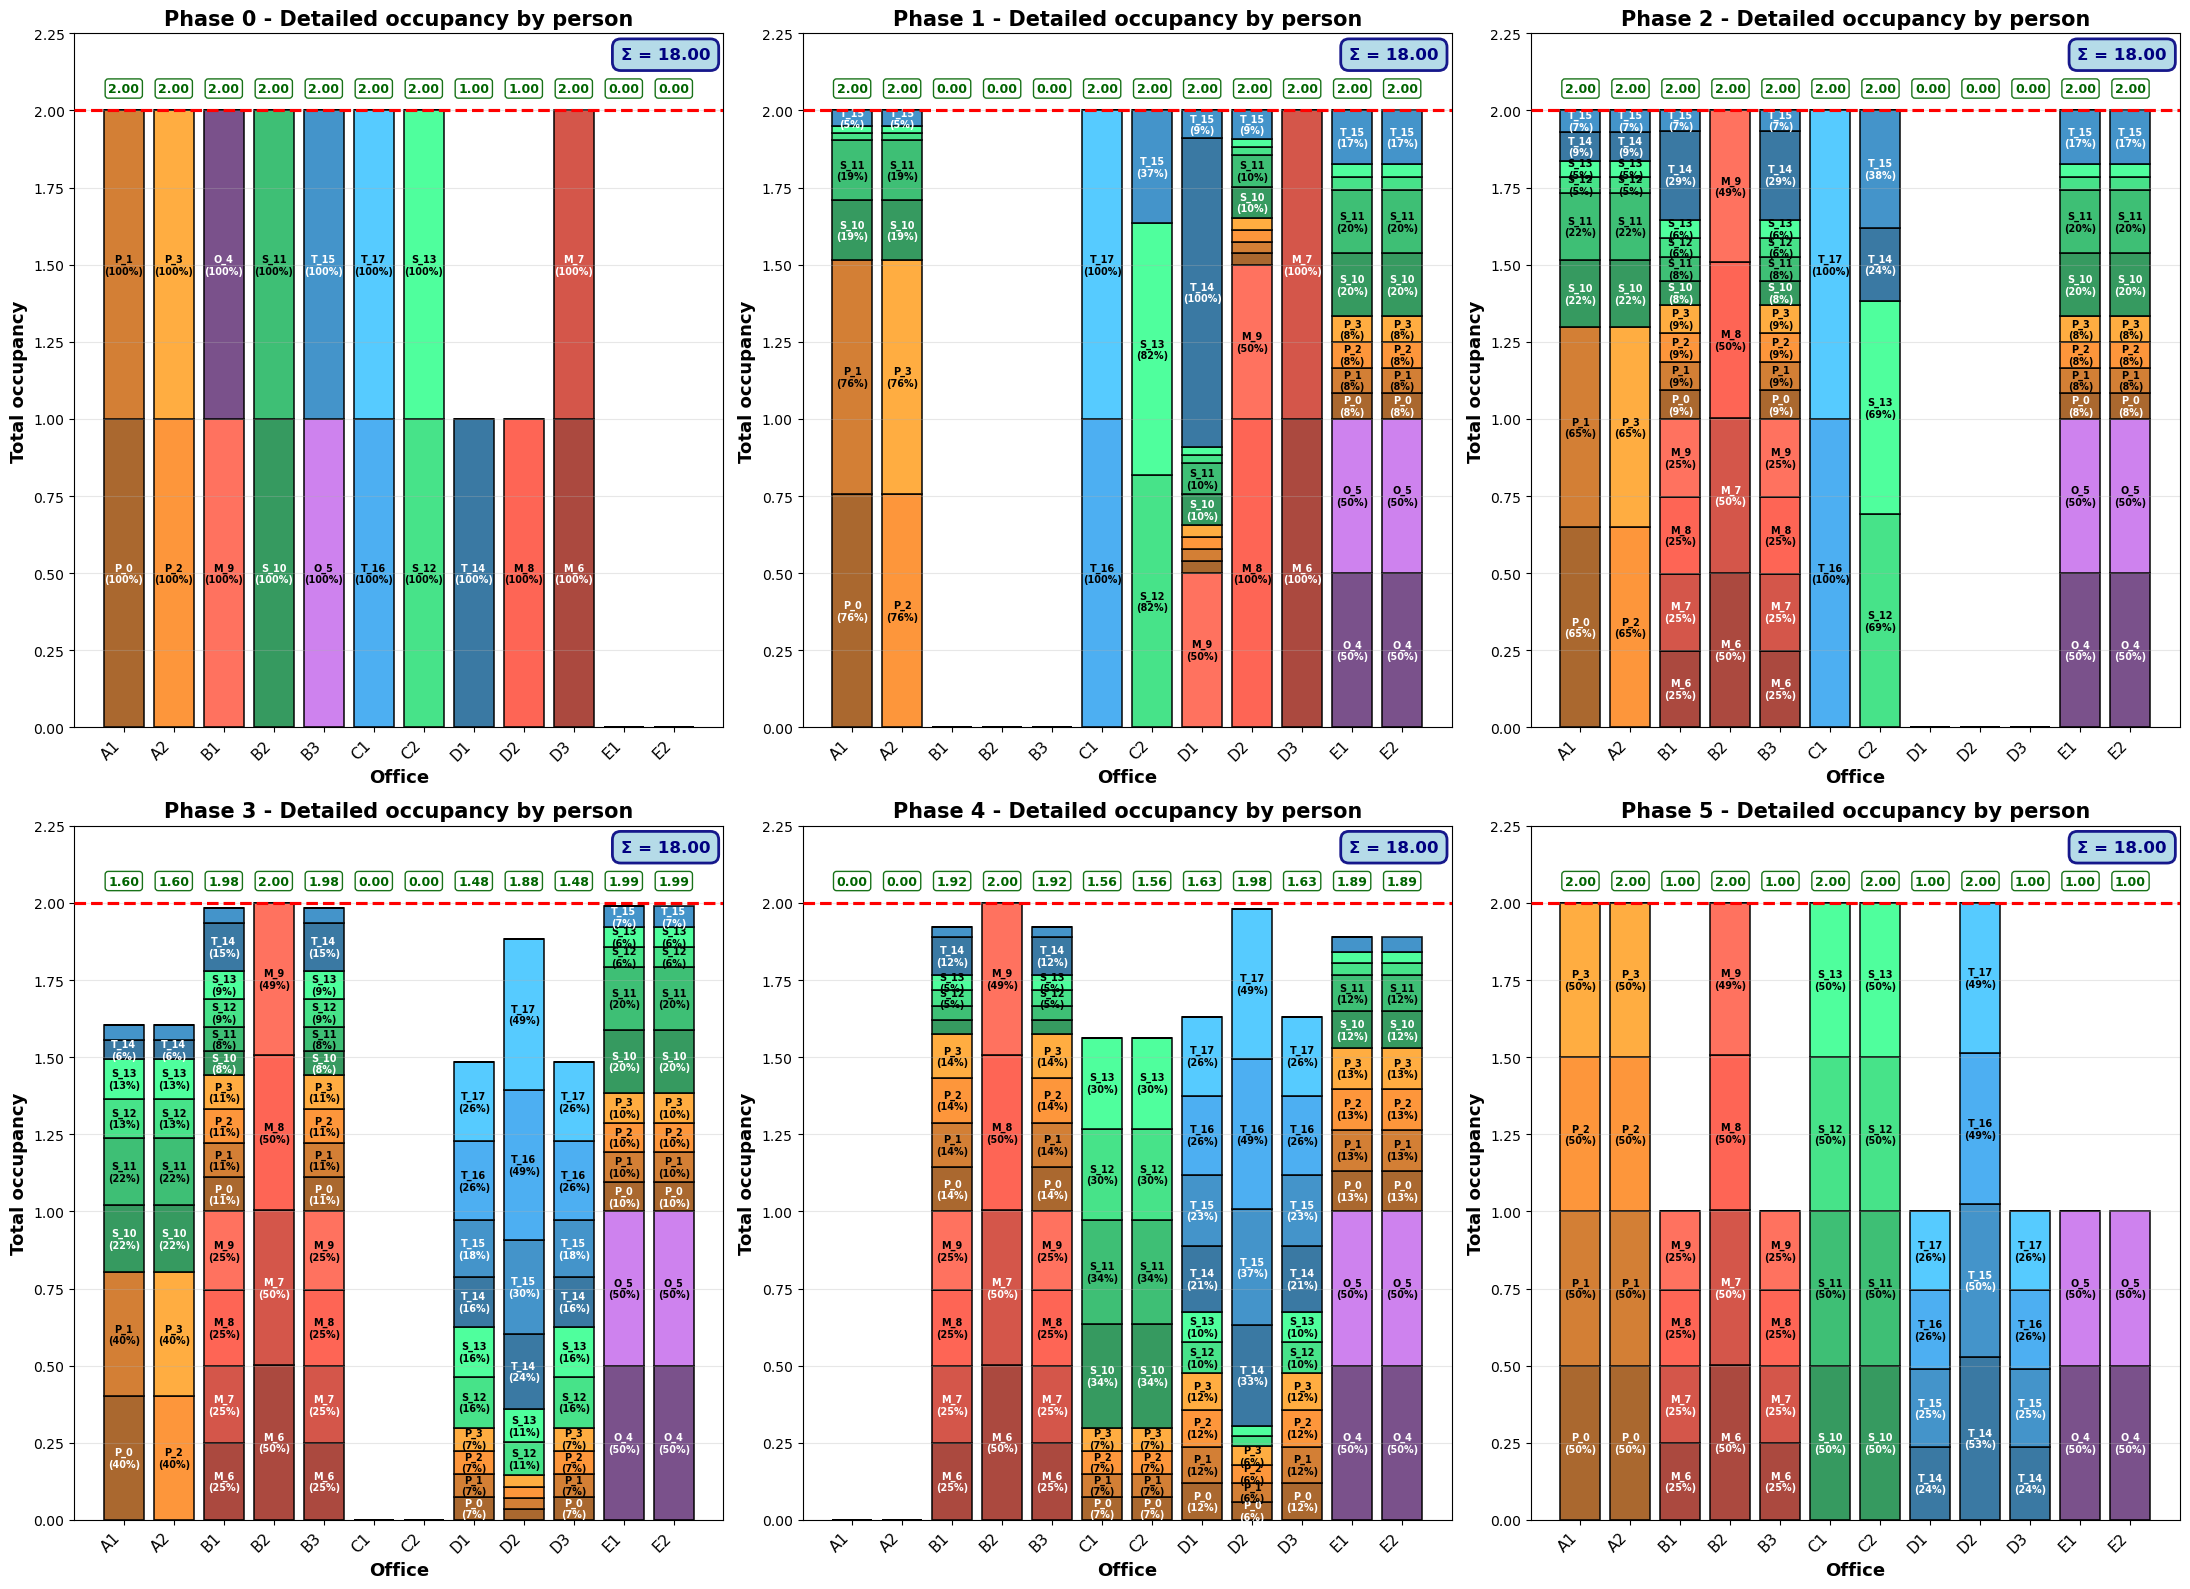


Graph saved: office_occupancy_detailed_q2.png


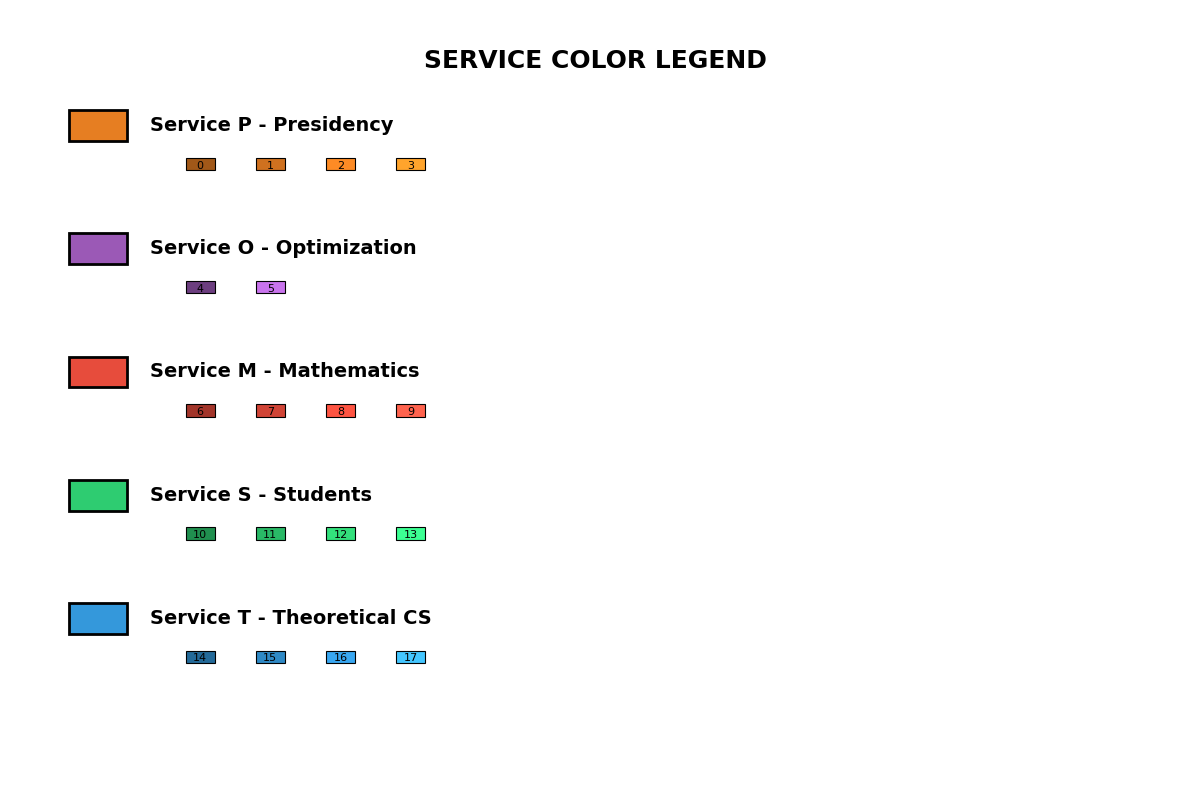

Legend saved: service_legend_q2.png

COLOR LEGEND
Service M - Mathematics (#e74c3c): people 6-9
  → Gradual shades to distinguish each person
Service P - Presidency (#e67e22): people 0-3
  → Gradual shades to distinguish each person
Service T - Theoretical CS (#3498db): people 14-17
  → Gradual shades to distinguish each person
Service S - Students (#2ecc71): people 10-13
  → Gradual shades to distinguish each person
Service O - Optimization (#9b59b6): people 4-5
  → Gradual shades to distinguish each person


In [40]:
if z.value is not None:
    # Define base colors per service
    service_colors_base = {
        'M': '#e74c3c',  # Red
        'P': '#e67e22',  # Orange
        'T': '#3498db',  # Blue
        'S': '#2ecc71',  # Green
        'O': '#9b59b6'   # Purple
    }
    
    # Function to generate shades of a base color
    def generate_color_shades(base_color, n_shades):
        """Generate n shades of a base color"""
        import matplotlib.colors as mcolors
        
        if n_shades == 1:
            return [base_color]
        
        # Convert hex to RGB
        rgb = mcolors.hex2color(base_color)
        
        # Generate shades by varying brightness
        shades = []
        for i in range(n_shades):
            # Brightness factor between 0.7 and 1.3
            factor = 0.7 + (i / max(n_shades - 1, 1)) * 0.6
            new_rgb = tuple(min(1.0, c * factor) for c in rgb)
            shades.append(mcolors.rgb2hex(new_rgb))
        
        return shades
    
    # Map person -> service and person -> color
    person_service = {}
    person_color = {}
    
    for service, people in services.items():
        base_color = service_colors_base[service]
        n_people_service = len(people)
        colors = generate_color_shades(base_color, n_people_service)
        
        for idx, k in enumerate(people):
            person_service[k] = service
            person_color[k] = colors[idx]
    
    # Office occupancy per phase with detail per person
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    for p in range(n_phases):
        ax = axes[p]
        
        # Collect people present in each office
        office_people = {i: [] for i in range(n_offices)}
        total_occupation = np.zeros(n_offices)
        
        for i in range(n_offices):
            for k in range(n_people):
                occupation = z.value[k, i, p]
                if occupation > 0.01:  # Threshold to ignore negligible values
                    office_people[i].append((k, occupation))
                    total_occupation[i] += occupation
            
            # Sort by service then by ID for visual consistency
            office_people[i].sort(key=lambda x: (person_service[x[0]], x[0]))
        
        # Stacked bar chart
        x_pos = np.arange(n_offices)
        bottom = np.zeros(n_offices)
        
        plotted_people = set()
        
        for i in range(n_offices):
            for k, occupation in office_people[i]:
                service = person_service[k]
                color = person_color[k]
                
                # Values vector for this office only
                values = np.zeros(n_offices)
                values[i] = occupation
                
                # Label for legend (once per person)
                label = f'{service}_{k}' if k not in plotted_people else None
                if k not in plotted_people:
                    plotted_people.add(k)
                
                # Draw bar
                bars = ax.bar(x_pos, values, bottom=bottom, 
                              color=color, 
                              alpha=0.9, 
                              edgecolor='black',
                              linewidth=1.2,
                              label=label)
                
                # Add label on bar
                if occupation > 0.05:
                    y_pos = bottom[i] + occupation/2
                    label_text = f'{service}_{k}\n({occupation:.0%})'
                    
                    # Determine text color based on background brightness
                    import matplotlib.colors as mcolors
                    rgb = mcolors.hex2color(color)
                    luminance = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
                    text_color = 'white' if luminance < 0.5 else 'black'
                    
                    ax.text(i, y_pos, label_text, 
                           ha='center', va='center',
                           fontsize=7, fontweight='bold',
                           color=text_color)
                
                bottom[i] += occupation
        
        # Max capacity line
        ax.axhline(y=2, color='red', linestyle='--', linewidth=2.25, 
                  label='Max capacity (2)', zorder=10)
        
        # Show total occupation above max line
        y_align = 2.05
        for i in range(n_offices):
            occ_total = total_occupation[i]
            text_color = 'red' if occ_total > 2.01 else 'darkgreen'
            fontweight = 'bold'
            
            ax.text(i, y_align, f'{occ_total:.2f}', 
                   ha='center', va='bottom',
                   fontsize=9, fontweight=fontweight,
                   color=text_color,
                   bbox=dict(boxstyle='round,pad=0.25', 
                             facecolor='white' if occ_total <= 2.01 else 'mistyrose',
                             edgecolor=text_color, 
                             linewidth=1.5 if occ_total > 2.01 else 1,
                             alpha=0.9))
        
        # Total sum in top-right corner
        total_sum = total_occupation.sum()
        ax.text(0.98, 0.98, f'Σ = {total_sum:.2f}', 
               transform=ax.transAxes,
               ha='right', va='top',
               fontsize=12, fontweight='bold',
               color='navy',
               bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor='lightblue',
                         edgecolor='navy', 
                         linewidth=2,
                         alpha=0.9))
        
        # Formatting
        ax.set_xlabel('Office', fontsize=13, fontweight='bold')
        ax.set_ylabel('Total occupancy', fontsize=13, fontweight='bold')
        ax.set_title(f'Phase {p} - Detailed occupancy by person', fontsize=15, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(offices, rotation=45, ha='right', fontsize=11)
        ax.set_ylim([0, 2.25])
        
        ax.grid(True, alpha=0.3, axis='y', zorder=0)
        
        # Highlight over-occupied offices
        for i in range(n_offices):
            if total_occupation[i] > 2.01:
                ax.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 2.25, 
                                           fill=False, edgecolor='red', 
                                           linewidth=3, linestyle=':', zorder=11))
                # Add alert marker
                ax.text(i, 2.42, '⚠', ha='center', va='top', 
                       fontsize=16, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('office_occupancy_detailed_q2.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("\nGraph saved: office_occupancy_detailed_q2.png")
    
    # Separate figure for legend
    fig_legend, ax_legend = plt.subplots(figsize=(12, 8))
    ax_legend.axis('off')
    
    # Legend title
    ax_legend.text(0.5, 0.95, 'SERVICE COLOR LEGEND', 
                   ha='center', va='top', fontsize=18, fontweight='bold',
                   transform=ax_legend.transAxes)
    
    service_names = {
        'M': 'Mathematics',
        'P': 'Presidency',
        'T': 'Theoretical CS',
        'S': 'Students',
        'O': 'Optimization'
    }
    
    y_start = 0.85
    y_step = 0.16
    
    # Sort services by first person ID
    services_sorted = sorted(service_colors_base.items(), key=lambda x: min(services[x[0]]))
    
    for idx, (service, base_color) in enumerate(services_sorted):
        people = services[service]
        y_pos = y_start - idx * y_step
        
        # Service name with base color
        ax_legend.add_patch(plt.Rectangle((0.05, y_pos - 0.02), 0.05, 0.04, 
                                         facecolor=base_color, 
                                         edgecolor='black', 
                                         linewidth=2,
                                         transform=ax_legend.transAxes))
        
        ax_legend.text(0.12, y_pos, f'Service {service} - {service_names[service]}', 
                       ha='left', va='center', fontsize=14, fontweight='bold',
                       transform=ax_legend.transAxes)
        
        # Show all people with shades
        colors = generate_color_shades(base_color, len(people))
        x_start = 0.15
        x_step = 0.06
        
        for i, k in enumerate(people):
            x_pos = x_start + (i % 10) * x_step
            y_sub = y_pos - 0.05 - (i // 10) * 0.025
            
            # Color square
            ax_legend.add_patch(plt.Rectangle((x_pos, y_sub - 0.008), 0.025, 0.016, 
                                             facecolor=colors[i], 
                                             edgecolor='black', 
                                             linewidth=0.8,
                                             transform=ax_legend.transAxes))
            
            # Person ID
            ax_legend.text(x_pos + 0.0125, y_sub - 0.002, f'{k}', 
                           ha='center', va='center', fontsize=8,
                           transform=ax_legend.transAxes)
    
    plt.tight_layout()
    plt.savefig('service_legend_q2.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Legend saved: service_legend_q2.png")
    
    # Print legend in console
    print("\n" + "="*70)
    print("COLOR LEGEND")
    print("="*70)
    for service, base_color in service_colors_base.items():
        people = services[service]
        print(f"Service {service} - {service_names[service]} ({base_color}): people {people[0]}-{people[-1]}")
        print(f"  → Gradual shades to distinguish each person")


## Solving the Dual Problem

### 2.3 Extracting Dual Variables

CVXPY automatically computes the dual variables when solving the primal problem. These variables can be accessed via the `.dual_value` attribute of each constraint.


In [41]:
if prob.status == 'optimal':
    print("\n" + "="*70)
    print("DUAL VARIABLE EXTRACTION")
    print("="*70)
    
    # Count constraints by type
    dual_values = {
        'C1_uniqueness': [],
        'C2_capacity': [],
        'C3_linearization': [],
        'C4_closed_offices': [],
        'C5_initial_positions': [],
        'C6_final_assignments': [],
        'C7_upper_bounds_z': []
    }
    
    # Constraints are in the order they were added
    constraint_index = 0
    
    # C7: z <= 1 (first added constraint, 1296 constraints)
    for _ in range(n_people * n_offices * n_phases):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C7_upper_bounds_z'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C7 (z <= 1): {len(dual_values['C7_upper_bounds_z'])} constraints")
    
    # C1: Uniqueness (108 constraints)
    for _ in range(n_people * n_phases):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C1_uniqueness'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C1 (uniqueness): {len(dual_values['C1_uniqueness'])} constraints")
    
    # C2: Capacity (72 constraints)
    for _ in range(n_offices * n_phases):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C2_capacity'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C2 (capacity): {len(dual_values['C2_capacity'])} constraints")
    
    # C3: Linearization (2160 constraints)
    n_c3 = 2 * n_people * n_offices * (n_phases - 1)
    for _ in range(n_c3):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C3_linearization'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C3 (linearization): {len(dual_values['C3_linearization'])} constraints")
    
    # C4: Closed offices (216 constraints)
    closed_offices_count = sum(len(offices_phase) for offices_phase in closed_offices.values())
    for _ in range(n_people * closed_offices_count):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C4_closed_offices'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C4 (closed offices): {len(dual_values['C4_closed_offices'])} constraints")
    
    # C5: Initial positions (18 constraints)
    for _ in range(n_people):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C5_initial_positions'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C5 (initial positions): {len(dual_values['C5_initial_positions'])} constraints")
    
    # C6: Final assignments (23 constraints)
    remaining = len(constraints) - constraint_index
    for _ in range(remaining):
        if constraint_index < len(constraints) and constraints[constraint_index].dual_value is not None:
            dual_values['C6_final_assignments'].append(constraints[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C6 (final assignments): {len(dual_values['C6_final_assignments'])} constraints")
    
    print(f"\nFinal index: {constraint_index}/{len(constraints)}")
    print(f"\nTotal extracted constraints: {sum(len(v) if isinstance(v, list) else 0 for v in dual_values.values())}")
else:
    print("\nThe problem was not solved optimally, no dual variables are available.")



DUAL VARIABLE EXTRACTION
✓ C7 (z <= 1): 1296 constraints
✓ C1 (uniqueness): 108 constraints
✓ C2 (capacity): 72 constraints
✓ C3 (linearization): 2160 constraints
✓ C4 (closed offices): 216 constraints
✓ C5 (initial positions): 18 constraints
✓ C6 (final assignments): 23 constraints

Final index: 3893/3893

Total extracted constraints: 3893


### 2.4 Checking Strong Duality


In [42]:
if prob.status == 'optimal' and z.value is not None:
    print("\n" + "="*70)
    print("STRONG DUALITY CHECK")
    print("="*70)
    
    # Optimal value of the primal
    primal_value = result
    print(f"\nOptimal PRIMAL value: {primal_value:.10f}")
    
    # For a minimization problem min c^T*x s.t. Ax<=b, Cx=d
    # The dual is: max b^T*mu + d^T*lambda
    # Dual value = -sum(constraint.dual_value * b)
    
    dual_value = 0.0
    
    # Contribution of C1 (uniqueness): -sum(lambda_C1 * 1)
    if dual_values['C1_uniqueness']:
        contrib_c1 = -np.sum(dual_values['C1_uniqueness'])
        dual_value += contrib_c1
        print(f"\nContribution C1 (uniqueness, b=1): {contrib_c1:.10f}")
    
    # Contribution of C2 (capacity): -sum(mu_C2 * 2)
    if dual_values['C2_capacity']:
        contrib_c2 = -2.0 * np.sum(dual_values['C2_capacity'])
        dual_value += contrib_c2
        print(f"Contribution C2 (capacity, b=2): {contrib_c2:.10f}")
    
    # Contribution of C4 (closed offices): 0
    print(f"Contribution C4 (closed offices, b=0): 0.0000000000")
    
    # Contribution of C5 (initial positions): -sum(lambda_C5 * 1)
    if dual_values['C5_initial_positions']:
        contrib_c5 = -np.sum(dual_values['C5_initial_positions'])
        dual_value += contrib_c5
        print(f"Contribution C5 (initial positions, b=1): {contrib_c5:.10f}")
    
    # Contribution of C6 (final assignments)
    if dual_values['C6_final_assignments']:
        lambda_c6 = np.array(dual_values['C6_final_assignments'])
        contrib_c6_base = -np.sum(lambda_c6[:18]) if len(lambda_c6) >= 18 else -np.sum(lambda_c6)
        if len(lambda_c6) >= 23:
            b_values = [1, 2, 1, 2, 1]
            contrib_c6_supp = -sum(lambda_c6[18 + i] * b_values[i] for i in range(5))
            contrib_c6 = contrib_c6_base + contrib_c6_supp
        else:
            contrib_c6 = contrib_c6_base
        dual_value += contrib_c6
        print(f"Contribution C6 (final assignments, variable b): {contrib_c6:.10f}")
    
    # Contribution of C7 (upper bounds z<=1): -sum(mu_z_sup * 1)
    if dual_values['C7_upper_bounds_z']:
        contrib_c7 = -np.sum(dual_values['C7_upper_bounds_z'])
        dual_value += contrib_c7
        print(f"Contribution C7 (upper bounds z<=1, b=1): {contrib_c7:.10f}")
    
    print(f"Contribution C3 (linearization, b=0): 0.0000000000")
    
    print(f"\nCalculated DUAL value: {dual_value:.10f}")
    print(f"\nGap (Primal - Dual): {abs(primal_value - dual_value):.2e}")
    
    if abs(primal_value - dual_value) < 1e-4:
        print("\n✓ STRONG DUALITY VERIFIED: Primal and dual values match!")
    else:
        print("\n⚠ WARNING: Significant gap between primal and dual")



STRONG DUALITY CHECK

Optimal PRIMAL value: 30.0000000000

Contribution C1 (uniqueness, b=1): 13.8158156855
Contribution C2 (capacity, b=2): -19.5396205634
Contribution C4 (closed offices, b=0): 0.0000000000
Contribution C5 (initial positions, b=1): 22.5613463032
Contribution C6 (final assignments, variable b): 17.5857991340
Contribution C7 (upper bounds z<=1, b=1): -4.4233405598
Contribution C3 (linearization, b=0): 0.0000000000

Calculated DUAL value: 29.9999999995

Gap (Primal - Dual): 5.27e-10

✓ STRONG DUALITY VERIFIED: Primal and dual values match!


## Question 3 : Solving with Separation Constraints (MILP)
### 3.1 Solving in CVXPY

In [43]:
# Adjacent offices
adjacencies = [
    ('A1', 'A2'),
    ('B1', 'B2'), ('B2', 'B3'),
    ('C1', 'C2'),
    ('D1', 'D2'), ('D2', 'D3'),
    # Newly added adjacencies
    ('E1', 'E2'), ('D2', 'E1'), ('E2', 'B2'),
    ('D1', 'C2'), ('C1', 'B3'), ('B1', 'A2'), ('D3', 'A1')
]

print(f"Number of adjacent pairs: {len(adjacencies)}")
print(f"Pairs: {adjacencies}")


constraints_sep = []

# Binary variables: one per adjacent office pair and per phase
n_pairs = len(adjacencies)
y = cp.Variable((n_pairs, n_phases), boolean=True)  # ← BINARY VARIABLES

# Big-M: maximum total capacity for an office pair (2 + 2 = 4)
M = 4

for idx_pair, (b1, b2) in enumerate(adjacencies):
    i1 = office_idx[b1]
    i2 = office_idx[b2]
    
    for p in range(n_phases):
        # Total number of P in the two adjacent offices
        sum_P = cp.sum([z[k, i1, p] for k in services['P']]) + \
                cp.sum([z[k, i2, p] for k in services['P']])
        
        # Total number of S in the two adjacent offices
        sum_S = cp.sum([z[k, i1, p] for k in services['S']]) + \
                cp.sum([z[k, i2, p] for k in services['S']])
        
        # If y = 1: P can occupy (sum_P allowed), S cannot (sum_S = 0)
        # If y = 0: S can occupy (sum_S allowed), P cannot (sum_P = 0)
        
        # Constraint: P can only be present if y = 1
        constraints_sep.append(sum_P <= M * y[idx_pair, p])
        
        # Constraint: S can only be present if y = 0
        constraints_sep.append(sum_S <= M * (1 - y[idx_pair, p]))

print(f"\nP-S separation constraints (with binary variables):")
print(f"  Binary variables y: {n_pairs * n_phases}")
print(f"  Big-M constraints: {2 * n_pairs * n_phases}")
print(f"  Total: {len(constraints_sep)} constraints")
print(f"\nIMPORTANT: This problem is now a Mixed-Integer Linear Program (MILP).")
print(f"   z variables remain continuous in [0,1], but y variables are binary {0,1}.")
print(f"   It is no longer a pure linear relaxation.")


Number of adjacent pairs: 13
Pairs: [('A1', 'A2'), ('B1', 'B2'), ('B2', 'B3'), ('C1', 'C2'), ('D1', 'D2'), ('D2', 'D3'), ('E1', 'E2'), ('D2', 'E1'), ('E2', 'B2'), ('D1', 'C2'), ('C1', 'B3'), ('B1', 'A2'), ('D3', 'A1')]

P-S separation constraints (with binary variables):
  Binary variables y: 78
  Big-M constraints: 156
  Total: 156 constraints

IMPORTANT: This problem is now a Mixed-Integer Linear Program (MILP).
   z variables remain continuous in [0,1], but y variables are binary (0, 1).
   It is no longer a pure linear relaxation.


In [44]:
# Solving the problem with P–S separation (MILP)
prob_q3 = cp.Problem(objective, constraints + constraints_sep)

print("Solving in progress with MILP solver...")
print("This may take significantly more time than a standard LP.\n")

# List of MILP solvers available in CVXPY
solvers_to_try = [
    (cp.CBC, 'CBC'),
]

result_q3 = None
solver_used = None

for solver, solver_name in solvers_to_try:
    try:
        print(f"Trying {solver_name}...")
        result_q3 = prob_q3.solve(solver=solver, verbose=False)
        if prob_q3.status in ['optimal', 'optimal_inaccurate']:
            solver_used = solver_name
            print(f"✓ Solution found with {solver_name}\n")
            break
        else:
            print(f"  Status: {prob_q3.status}\n")
    except Exception as e:
        print(f"Error with {solver_name}: {e}\n")

if result_q3 is None or prob_q3.status not in ['optimal', 'optimal_inaccurate']:
    print("ERROR: No MILP solver could solve the problem.")
    print("\nPossible solutions:")
    print("1. Install a MILP solver: pip install cvxpy[CBC] or pip install cvxpy[GLPK]")
    print("2. Use the linear approximation formulation (sum_P + sum_S <= 1)")
    print("3. Check that the constraints are not too restrictive (infeasibility)")
else:
    print("\n" + "="*70)
    print("COMPARISON OF RESULTS")
    print("="*70)
    print(f"Without P–S separation (pure LP):")
    print(f"  Solver: standard LP")
    print(f"  Optimal value: {result:.6f}")
    print(f"  Number of moves: {result:.2f}")
    print(f"\nWith P–S separation (MILP with binary variables):")
    print(f"  Solver used: {solver_used}")
    print(f"  Status: {prob_q3.status}")
    print(f"  Optimal value: {result_q3:.6f}")
    print(f"  Number of moves: {result_q3:.2f}")
    
    if result > 0:
        increase = ((result_q3 - result) / result * 100)
        print(f"\nImpact of the separation constraint:")
        print(f"  Increase: {increase:.2f}%")
        print(f"  Additional moves: {(result_q3 - result):.2f}")


Solving in progress with MILP solver...
This may take significantly more time than a standard LP.

Trying CBC...


/Users/macchenf/anaconda3/envs/opt_env/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


✓ Solution found with CBC


COMPARISON OF RESULTS
Without P–S separation (pure LP):
  Solver: standard LP
  Optimal value: 30.000000
  Number of moves: 30.00

With P–S separation (MILP with binary variables):
  Solver used: CBC
  Status: optimal
  Optimal value: 30.000000
  Number of moves: 30.00

Impact of the separation constraint:
  Increase: -0.00%
  Additional moves: -0.00


### 3.2 Visualization of the solution with P–S separation


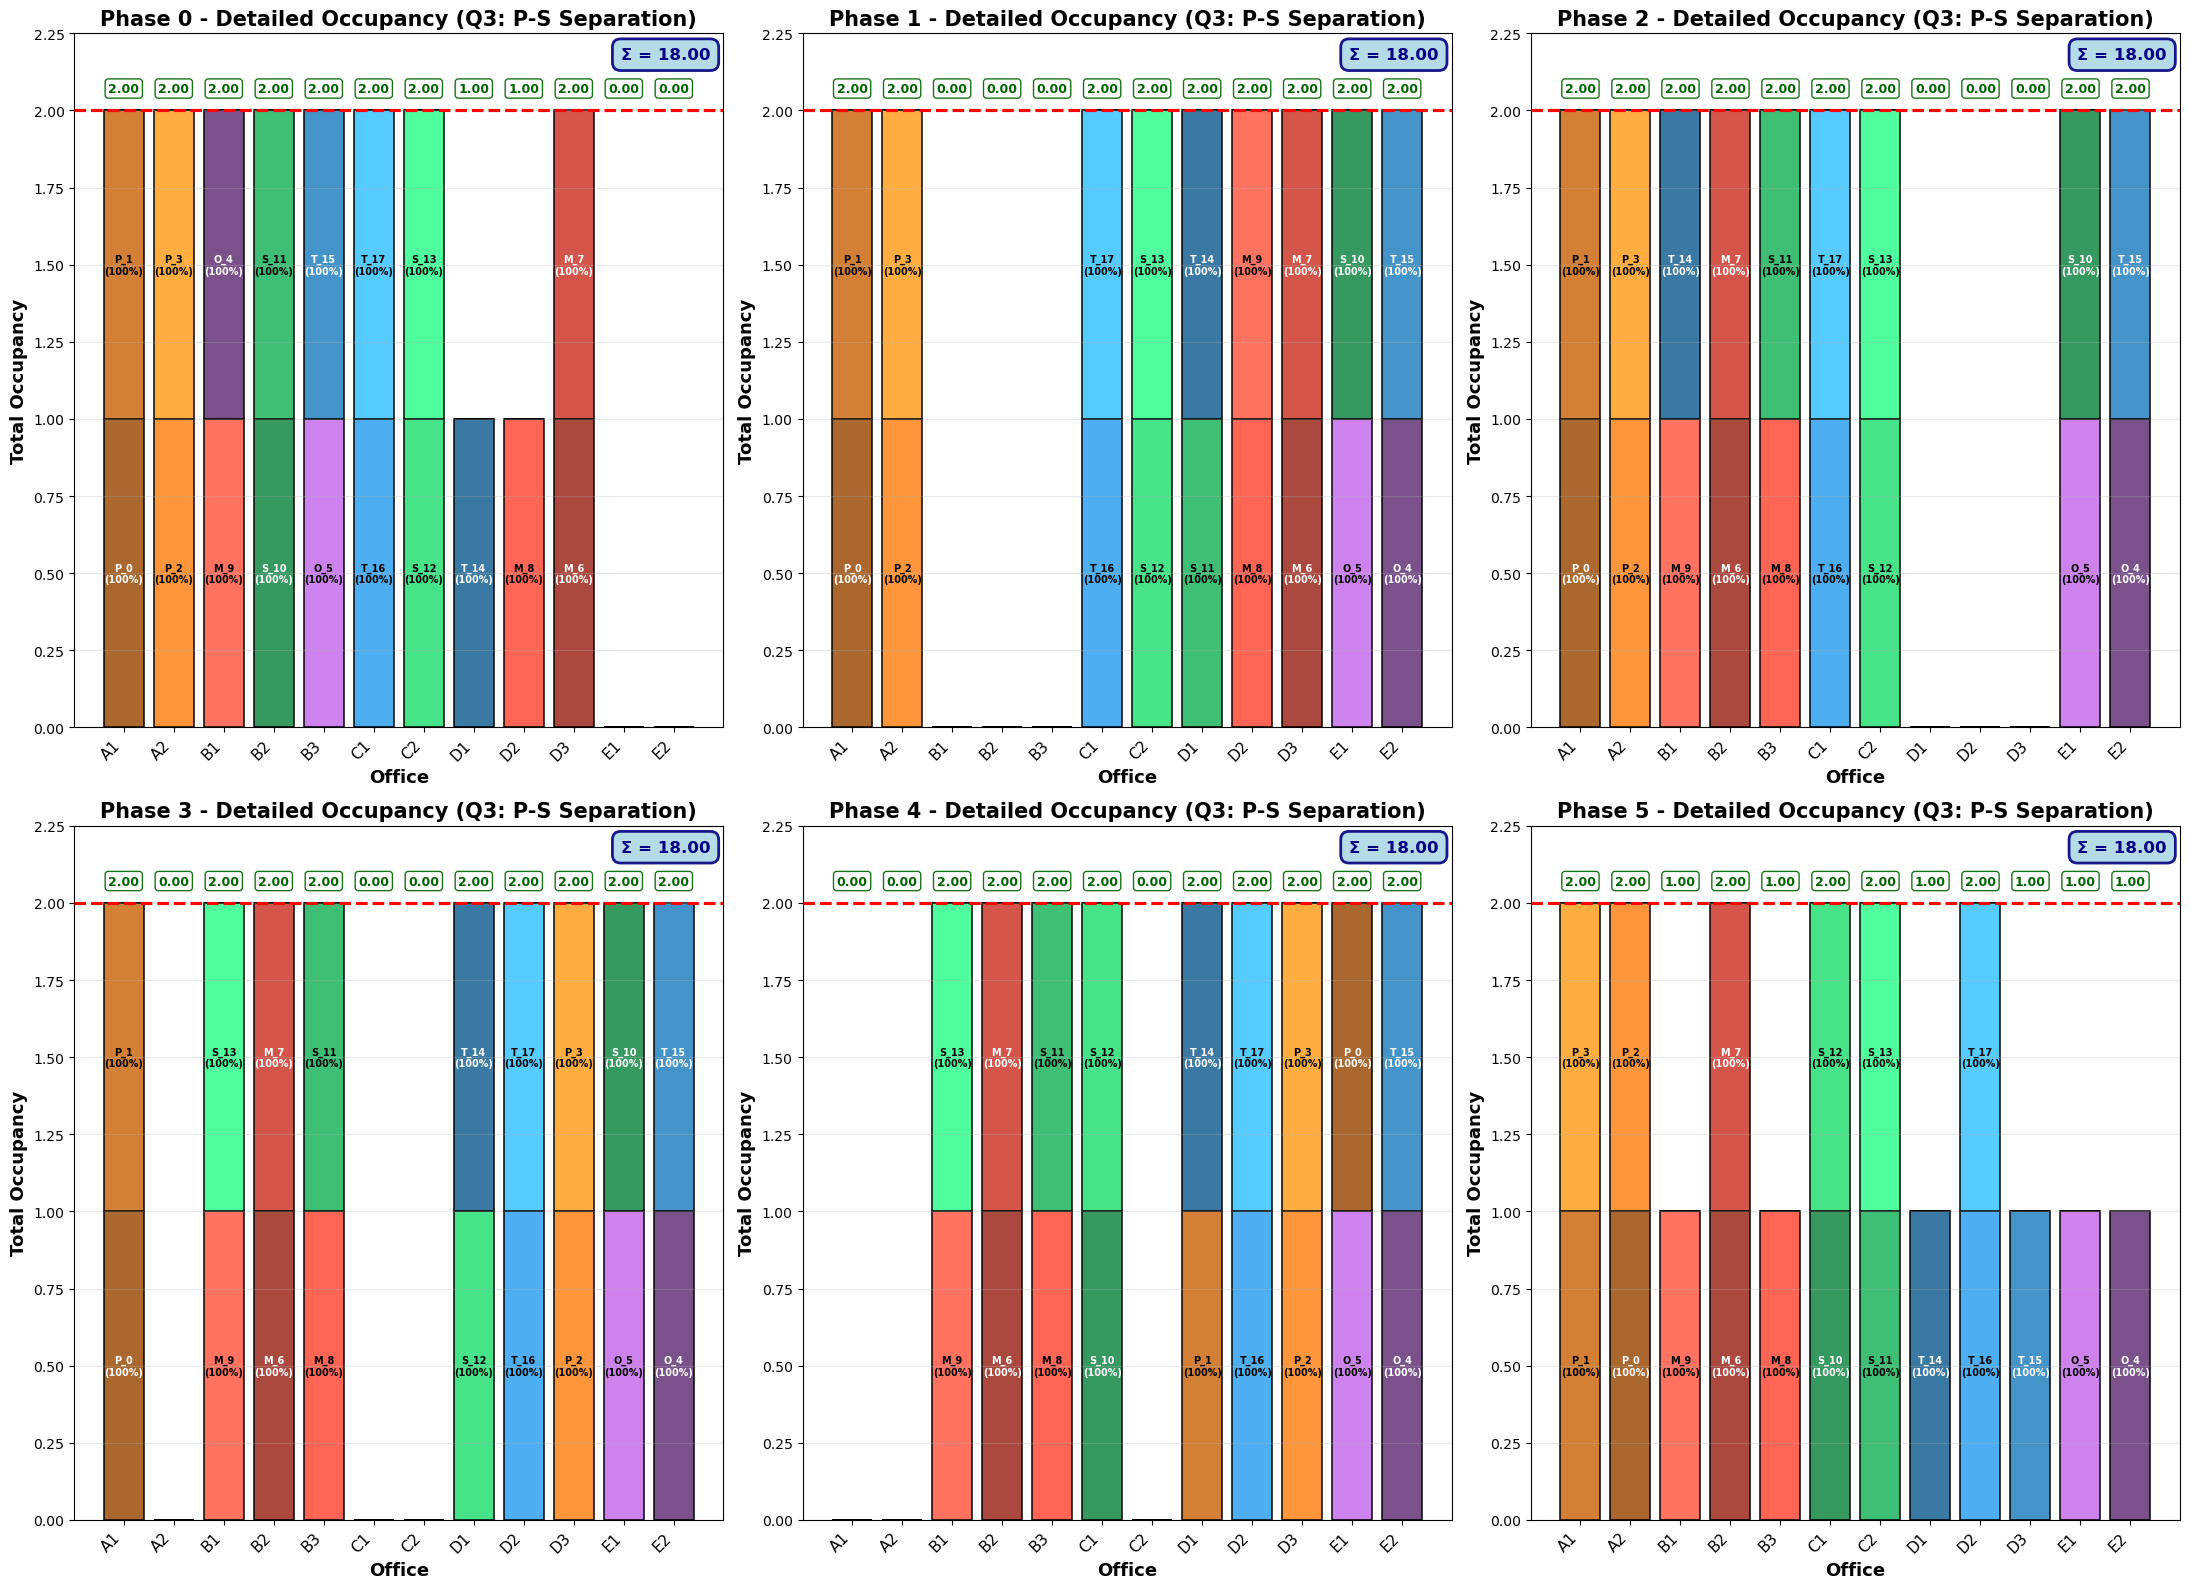


Chart saved: occupation_bureaux_detaillee_q3.png

✓ NO P-S SEPARATION VIOLATIONS
Separation constraints are respected at all phases!


In [45]:
if z.value is not None and prob_q3.status == 'optimal':
    # Define colors per service (same as Q2)
    service_colors_base = {
        'M': '#e74c3c',  # Red
        'P': '#e67e22',  # Orange
        'T': '#3498db',  # Blue
        'S': '#2ecc71',  # Green
        'O': '#9b59b6'   # Purple
    }
    
    # Function to generate shades of a color
    def generate_color_shades(base_color, n_shades):
        """Generates n shades of a base color"""
        import matplotlib.colors as mcolors
        
        if n_shades == 1:
            return [base_color]
        
        # Convert hex to RGB
        rgb = mcolors.hex2color(base_color)
        
        # Generate shades by varying brightness
        shades = []
        for i in range(n_shades):
            factor = 0.7 + (i / max(n_shades - 1, 1)) * 0.6
            new_rgb = tuple(min(1.0, c * factor) for c in rgb)
            shades.append(mcolors.rgb2hex(new_rgb))
        
        return shades
    
    # Map person -> service and person -> color
    person_service = {}
    person_color = {}
    
    for service, persons in services.items():
        base_color = service_colors_base[service]
        n_persons_service = len(persons)
        colors = generate_color_shades(base_color, n_persons_service)
        
        for idx, k in enumerate(persons):
            person_service[k] = service
            person_color[k] = colors[idx]
    
    # Office occupation per phase with individual detail (Q3)
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    # Track potential P-S separation violations
    adjacency_violations = []
    
    for p in range(n_phases):
        ax = axes[p]
        
        # Collect people in each office
        office_people = {i: [] for i in range(n_offices)}
        office_total_occupancy = np.zeros(n_offices)
        
        for i in range(n_offices):
            for k in range(n_people):
                occupancy = z.value[k, i, p]
                if occupancy > 0.01:
                    office_people[i].append((k, occupancy))
                    office_total_occupancy[i] += occupancy
            
            office_people[i].sort(key=lambda x: (person_service[x[0]], x[0]))
        
        # Check adjacency violations P-S for this phase
        phase_violations = []
        for (b1, b2) in adjacencies:
            i1, i2 = office_idx[b1], office_idx[b2]
            
            p_in_b1 = sum([occ for k, occ in office_people[i1] if k in services['P']])
            s_in_b2 = sum([occ for k, occ in office_people[i2] if k in services['S']])
            
            p_in_b2 = sum([occ for k, occ in office_people[i2] if k in services['P']])
            s_in_b1 = sum([occ for k, occ in office_people[i1] if k in services['S']])
            
            if (p_in_b1 > 0.01 and s_in_b2 > 0.01):
                phase_violations.append((i1, i2))
                adjacency_violations.append((p, b1, b2, p_in_b1, s_in_b2))
            if (p_in_b2 > 0.01 and s_in_b1 > 0.01):
                phase_violations.append((i2, i1))
                adjacency_violations.append((p, b2, b1, p_in_b2, s_in_b1))
        
        # Stacked bars
        x_pos = np.arange(n_offices)
        bottom = np.zeros(n_offices)
        traced_people = set()
        
        for i in range(n_offices):
            for k, occupancy in office_people[i]:
                service = person_service[k]
                color = person_color[k]
                values = np.zeros(n_offices)
                values[i] = occupancy
                
                label = f'{service}_{k}' if k not in traced_people else None
                if k not in traced_people:
                    traced_people.add(k)
                
                bars = ax.bar(x_pos, values, bottom=bottom, 
                              color=color, alpha=0.9, 
                              edgecolor='black', linewidth=1.2, label=label)
                
                if occupancy > 0.05:
                    y_pos = bottom[i] + occupancy/2
                    label_text = f'{service}_{k}\n({occupancy:.0%})'
                    import matplotlib.colors as mcolors
                    rgb = mcolors.hex2color(color)
                    luminance = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
                    text_color = 'white' if luminance < 0.5 else 'black'
                    ax.text(i, y_pos, label_text, ha='center', va='center', fontsize=7, fontweight='bold', color=text_color)
                
                bottom[i] += occupancy
        
        # Max capacity line
        ax.axhline(y=2, color='red', linestyle='--', linewidth=2.25, label='Max capacity (2)', zorder=10)
        
        y_align = 2.05
        for i in range(n_offices):
            total_occ = office_total_occupancy[i]
            text_color = 'red' if total_occ > 2.01 else 'darkgreen'
            ax.text(i, y_align, f'{total_occ:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=text_color, bbox=dict(boxstyle='round,pad=0.25', facecolor='white' if total_occ <= 2.01 else 'mistyrose', edgecolor=text_color, linewidth=1.5 if total_occ > 2.01 else 1, alpha=0.9))
        
        total_sum = office_total_occupancy.sum()
        ax.text(0.98, 0.98, f'Σ = {total_sum:.2f}', transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold', color='navy', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='navy', linewidth=2, alpha=0.9))
        
        # Highlight offices with adjacency violations
        offices_with_violation = set()
        for (i1, i2) in phase_violations:
            offices_with_violation.add(i1)
            offices_with_violation.add(i2)
        
        for i in offices_with_violation:
            ax.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 2.25, fill=False, edgecolor='purple', linewidth=3, linestyle=':', zorder=11))
            ax.text(i, 2.42, '⚠️', ha='center', va='top', fontsize=16, color='purple', fontweight='bold')
        
        # Formatting
        ax.set_xlabel('Office', fontsize=13, fontweight='bold')
        ax.set_ylabel('Total Occupancy', fontsize=13, fontweight='bold')
        title = f'Phase {p} - Detailed Occupancy (Q3: P-S Separation)'
        if phase_violations:
            title += f' [{len(phase_violations)} violations]'
        ax.set_title(title, fontsize=15, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(offices, rotation=45, ha='right', fontsize=11)
        ax.set_ylim([0, 2.25])
        ax.grid(True, alpha=0.3, axis='y', zorder=0)
    
    plt.tight_layout()
    plt.savefig('occupation_bureaux_detaillee_q3.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("\nChart saved: occupation_bureaux_detaillee_q3.png")
    
    # Report violations
    if adjacency_violations:
        print("\n" + "="*70)
        print("P-S SEPARATION VIOLATIONS DETECTED")
        print("="*70)
        for phase, b1, b2, occ_p, occ_s in adjacency_violations:
            print(f"Phase {phase}: {b1} (P:{occ_p:.2f}) adjacent to {b2} (S:{occ_s:.2f})")
        print(f"\nTotal violations: {len(adjacency_violations)}")
    else:
        print("\n" + "="*70)
        print("✓ NO P-S SEPARATION VIOLATIONS")
        print("="*70)
        print("Separation constraints are respected at all phases!")


---

# Part 2: Penalized Problem

## Question 5: Adding a Penalty for Convergence Toward the Final Allocation
### 5.1 Solving the penalized problem


In [46]:
# Penalization parameter
lambda_penalty = 100

print("="*70)
print("QUESTION 5: PENALIZED PROBLEM")
print("="*70)
print(f"Penalization parameter λ = {lambda_penalty}\n")

# Variables of the penalized problem (reuse of z and d from Q1)
# New variables e for penalty linearization
e = cp.Variable((n_people, n_offices, n_phases), nonneg=True)

# New objective function with penalty
objective_penalized = cp.Minimize(
    0.5 * cp.sum(d) + lambda_penalty * cp.sum(e)
)

# Constraints of the penalized problem = constraints from Q1 + new C8 constraints
constraints_penalized = constraints.copy()

# C8: Linearization constraints for e_{k,i,p} >= |z_{k,i,p} - z_{k,i,5}|
print("Adding penalty constraints (C8)...")
count_c8 = 0

for k in range(n_people):
    for i in range(n_offices):
        for p in range(n_phases):
            # e[k,i,p] >= z[k,i,p] - z[k,i,5]
            constraints_penalized.append(e[k, i, p] >= z[k, i, p] - z[k, i, 5])
            count_c8 += 1
            
            # e[k,i,p] >= z[k,i,5] - z[k,i,p]
            constraints_penalized.append(e[k, i, p] >= z[k, i, 5] - z[k, i, p])
            count_c8 += 1

print(f"C8 constraints added: {count_c8}")
print(f"Total constraints in penalized problem: {len(constraints_penalized)}\n")

# Solving the penalized problem
prob_penalized = cp.Problem(objective_penalized, constraints_penalized)

print("Solving the penalized primal problem...")
result_penalized = prob_penalized.solve(solver=cp.ECOS, verbose=True)
z_q4 = z.value.copy()
e_q4 = e.value.copy()

print("\n" + "="*70)
print("RESULTS OF THE PENALIZED PRIMAL PROBLEM")
print("="*70)
print(f"Status: {prob_penalized.status}")
print(f"Total optimal value: {result_penalized:.6f}")

if z.value is not None and d.value is not None and e.value is not None:
    # Decomposition of the optimal value
    cost_moves = 0.5 * np.sum(d.value)
    cost_penalty = lambda_penalty * np.sum(e.value)
    
    print(f"\nObjective decomposition:")
    print(f"  Moving cost: {cost_moves:.6f}")
    print(f"  Penalty cost (λ × Σe): {cost_penalty:.6f}")
    print(f"  Number of moves: {cost_moves:.2f}")
    print(f"  Total distance to final allocation: {np.sum(e.value):.6f}")
    
    # Comparison with Q1 (without penalty)
    print(f"\n" + "="*70)
    print("COMPARISON Q1 vs Q4")
    print("="*70)
    print(f"Q1 (without penalty):")
    print(f"  Number of moves: {result:.2f}")
    print(f"\nQ4 (with penalty λ={lambda_penalty}):")
    print(f"  Number of moves: {cost_moves:.2f}")
    print(f"  Increase: {(cost_moves - result):.2f} moves")
    if result > 0:
        print(f"  Relative increase: {((cost_moves - result) / result * 100):.2f}%")
else:
    print("\nError: solution not available")


QUESTION 5: PENALIZED PROBLEM
Penalization parameter λ = 100

Adding penalty constraints (C8)...
C8 constraints added: 2592
Total constraints in penalized problem: 6485

Solving the penalized primal problem...
                                     CVXPY                                     
                                     v1.7.5                                    


(CVXPY) Jan 28 03:11:32 AM: Your problem has 3672 variables, 6485 constraints, and 0 parameters.
(CVXPY) Jan 28 03:11:33 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 28 03:11:33 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 28 03:11:33 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 28 03:11:33 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 28 03:11:33 AM: Compiling problem (target solver=ECOS).
(CVXPY) Jan 28 03:11:33 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jan 28 03:11:33 AM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jan 28 03:11:34 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 28 03:11:34 AM: Applying reduction ConeMatrixStuffing
/Users/macchenf/anaconda3/envs/opt_env/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
(CVXPY) Jan 28 03:11:41 AM: Applying reduction ECOS
(CVXPY) Jan 28 03:11:41 AM: Finished problem compilation (took 8.403e+00 seconds).
(CVXPY) Jan 28 03:11:41 AM: Invoking solver ECOS  to obtain a solution.
(CVXPY) Jan 28 03:11:41 AM: Problem status: optimal
(CVXPY) Jan 28 03:11:41 AM: Optimal value: 5.238e+03
(CVXPY) Jan 28 03:11:41 AM: Compilation took 8.403e+00 seconds
(CVXPY) Jan 28 03:11:41 AM: Solver (including time spent in interface) took 3.300e-02 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------

ECOS 2.0.10 - (C) embotech GmbH, Zurich Switzerland, 2012-15. Web: www.embotech.com/ECOS

It     pcost       dcost      gap   pres   dres    k/t    mu     step   sigma     IR    |   BT
 0  +4.808e-15  -1.440e+03  +3e+05  8e-01  3e-02  1e+00  3e+01    ---    ---    1  1  - |  -  - 
 1  +3.323e+02  +1.045e+01  +6e+04  2e-01  6e-03  7e-01  7e+00  0.7895  2e-02   1  1  1 |  0  0
 2  +7.869e+02  +5.906e+02  +4e+04  5e-02  3e-03  2e+00  4e+00  0.7323  4e-01   1  1  1 |  0  0
 3  +1.863e+03  +1.734e+03  +2e+04  3e-02  2e-03  2e+00  2e+00  0.6133  4e-01   1  1  1 |  0  0
 4  +3.094e+03  +3.012e+03  +1e+04  3e-02  1e-03  1e+00  2e+00  0.4541  2e-01   1  1  1 |  0  0
 5  +3.722e+03  +3.665e+03  +1e+04  2e-02  8e-04  1e+00  1e+00  0.3191  1e-01   1  1  1 |  0 

## Resolution of the penalized dual problem
### 5.2 Extraction of the dual variables of the penalized problem

In [47]:
if prob_penalized.status == 'optimal':
    print("\n" + "="*70)
    print("EXTRACTION OF DUAL VARIABLES FOR THE PENALIZED PROBLEM")
    print("="*70)
    
    # Count constraints by type
    dual_values_penalized = {
        'C1_unicite': [],
        'C2_capacite': [],
        'C3_linearisation': [],
        'C4_fermes': [],
        'C5_init': [],
        'C6_final': [],
        'C7_bornes_sup_z': [],
        'C8_penalty_plus': [],
        'C8_penalty_minus': []
    }
    
    # Constraints are in the order in which they were added
    constraint_index = 0
    
    # C7: z <= 1 (first added constraint, 1296 constraints)
    for _ in range(n_people * n_offices * n_phases):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C7_bornes_sup_z'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C7 (z <= 1): {len(dual_values_penalized['C7_bornes_sup_z'])} constraints")
    
    # C1: Uniqueness (108 constraints)
    for _ in range(n_people * n_phases):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C1_unicite'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C1 (uniqueness): {len(dual_values_penalized['C1_unicite'])} constraints")
    
    # C2: Capacity (72 constraints)
    for _ in range(n_offices * n_phases):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C2_capacite'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C2 (capacity): {len(dual_values_penalized['C2_capacite'])} constraints")
    
    # C3: Linearization (2160 constraints)
    n_c3 = 2 * n_people * n_offices * (n_phases - 1)
    for _ in range(n_c3):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C3_linearisation'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C3 (linearization): {len(dual_values_penalized['C3_linearisation'])} constraints")
    
    # C4: Closed offices (216 constraints)
    bureaux_fermes_count = sum(len(bureaux_phase) for bureaux_phase in closed_offices.values())
    for _ in range(n_people * bureaux_fermes_count):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C4_fermes'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C4 (closed offices): {len(dual_values_penalized['C4_fermes'])} constraints")
    
    # C5: Initial positions (18 constraints)
    for _ in range(n_people):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C5_init'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C5 (initial positions): {len(dual_values_penalized['C5_init'])} constraints")
    
    # C6: Final assignments (23 constraints)
    for _ in range(23):
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C6_final'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    print(f"✓ C6 (final assignments): {len(dual_values_penalized['C6_final'])} constraints")
    
    # C8: Penalty constraints (2592 constraints = 2 × 18 × 12 × 6)
    # Alternating between C8+ and C8-
    n_c8_half = n_people * n_offices * n_phases
    for _ in range(n_c8_half):
        # C8+: e >= z - z_final
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C8_penalty_plus'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
        
        # C8-: e >= z_final - z
        if constraint_index < len(constraints_penalized) and \
           constraints_penalized[constraint_index].dual_value is not None:
            dual_values_penalized['C8_penalty_minus'].append(
                constraints_penalized[constraint_index].dual_value)
        constraint_index += 1
    
    print(f"✓ C8+ (penalty +): {len(dual_values_penalized['C8_penalty_plus'])} constraints")
    print(f"✓ C8- (penalty -): {len(dual_values_penalized['C8_penalty_minus'])} constraints")
    
    print(f"\nFinal index: {constraint_index}/{len(constraints_penalized)}")
    total_dual = sum(len(v) if isinstance(v, list) else 0 
                     for v in dual_values_penalized.values())
    print(f"Total extracted constraints: {total_dual}")
    
    # Statistics on penalty multipliers
    print("\n" + "="*70)
    print("STATISTICS ON PENALTY MULTIPLIERS (C8)")
    print("="*70)
    
    mu_c8_plus = np.array(dual_values_penalized['C8_penalty_plus'])
    mu_c8_minus = np.array(dual_values_penalized['C8_penalty_minus'])
    
    print(f"\nMultipliers μ^C8+:")
    print(f"  Min: {np.min(mu_c8_plus):.6f}")
    print(f"  Max: {np.max(mu_c8_plus):.6f}")
    print(f"  Mean: {np.mean(mu_c8_plus):.6f}")
    print(f"  Number > 0: {np.sum(mu_c8_plus > 1e-6)}")
    
    print(f"\nMultipliers μ^C8-:")
    print(f"  Min: {np.min(mu_c8_minus):.6f}")
    print(f"  Max: {np.max(mu_c8_minus):.6f}")
    print(f"  Mean: {np.mean(mu_c8_minus):.6f}")
    print(f"  Number > 0: {np.sum(mu_c8_minus > 1e-6)}")
    
    # Check stationarity condition on e
    # λ - μ^C8+ - μ^C8- - μ^e_L = 0
    # If e > 0, then μ^e_L = 0, so μ^C8+ + μ^C8- = λ
    mu_c8_sum = mu_c8_plus + mu_c8_minus
    
    print(f"\nChecking stationarity condition on e:")
    print(f"  μ^C8+ + μ^C8- (mean): {np.mean(mu_c8_sum):.6f}")
    print(f"  Expected value ≈ λ = {lambda_penalty} (if e > 0)")
    
    # Identify (k,i,p) where e > 0 (deviation from final allocation)
    if e.value is not None:
        deviations_actives = np.sum(e.value > 1e-6)
        print(f"\nNumber of active deviations (e > 0): {deviations_actives}/{e.value.size}")
        
        # Check that for these deviations, μ^C8+ + μ^C8- ≈ λ
        e_flat = e.value.flatten()
        active_indices = e_flat > 1e-6
        
        if np.sum(active_indices) > 0:
            mu_sum_active = mu_c8_sum[active_indices]
            print(f"  For e > 0: μ^C8+ + μ^C8- (mean) = {np.mean(mu_sum_active):.6f}")
            print(f"  Deviation from λ: {np.abs(np.mean(mu_sum_active) - lambda_penalty):.6f}")

else:
    print("\nThe problem was not solved optimally, no dual variables available.")



EXTRACTION OF DUAL VARIABLES FOR THE PENALIZED PROBLEM
✓ C7 (z <= 1): 1296 constraints
✓ C1 (uniqueness): 108 constraints
✓ C2 (capacity): 72 constraints
✓ C3 (linearization): 2160 constraints
✓ C4 (closed offices): 216 constraints
✓ C5 (initial positions): 18 constraints
✓ C6 (final assignments): 23 constraints
✓ C8+ (penalty +): 1296 constraints
✓ C8- (penalty -): 1296 constraints

Final index: 6485/6485
Total extracted constraints: 6485

STATISTICS ON PENALTY MULTIPLIERS (C8)

Multipliers μ^C8+:
  Min: 0.000000
  Max: 100.000000
  Mean: 39.022322
  Number > 0: 1256

Multipliers μ^C8-:
  Min: 0.000000
  Max: 100.000000
  Mean: 34.464477
  Number > 0: 1208

Checking stationarity condition on e:
  μ^C8+ + μ^C8- (mean): 73.486799
  Expected value ≈ λ = 100 (if e > 0)

Number of active deviations (e > 0): 128/1296
  For e > 0: μ^C8+ + μ^C8- (mean) = 100.000000
  Deviation from λ: 0.000000


### 5.3 Verification of strong duality for the penalized problem

In [48]:
if prob_penalized.status == 'optimal' and z.value is not None:
    print("\n" + "="*70)
    print("VERIFICATION OF STRONG DUALITY (PENALIZED PROBLEM)")
    print("="*70)
    
    # Optimal value of the penalized primal
    primal_value_penalized = result_penalized
    print(f"\nOptimal value of the PENALIZED PRIMAL: {primal_value_penalized:.10f}")
    
    # Computation of the dual value
    # For a minimization problem min c^T*x s.t. Ax<=b, Cx=d
    # The dual is: max b^T*mu + d^T*lambda
    # The dual value = -sum(constraint.dual_value * b)
    
    dual_value_penalized = 0.0
    
    # Contribution of C1 (uniqueness): -sum(lambda_C1 * 1)
    if dual_values_penalized['C1_unicite']:
        contrib_c1 = -np.sum(dual_values_penalized['C1_unicite'])
        dual_value_penalized += contrib_c1
        print(f"\nContribution C1 (uniqueness, b=1): {contrib_c1:.10f}")
    
    # Contribution of C2 (capacity): -sum(mu_C2 * 2)
    if dual_values_penalized['C2_capacite']:
        contrib_c2 = -2.0 * np.sum(dual_values_penalized['C2_capacite'])
        dual_value_penalized += contrib_c2
        print(f"Contribution C2 (capacity, b=2): {contrib_c2:.10f}")
    
    # Contribution of C4 (closed offices): 0
    print(f"Contribution C4 (closed offices, b=0): 0.0000000000")
    
    # Contribution of C5 (initial positions): -sum(lambda_C5 * 1)
    if dual_values_penalized['C5_init']:
        contrib_c5 = -np.sum(dual_values_penalized['C5_init'])
        dual_value_penalized += contrib_c5
        print(f"Contribution C5 (initial positions, b=1): {contrib_c5:.10f}")
    
    # Contribution of C6 (final assignments)
    if dual_values_penalized['C6_final']:
        lambda_c6 = np.array(dual_values_penalized['C6_final'])
        contrib_c6_base = -np.sum(lambda_c6[:18]) if len(lambda_c6) >= 18 else -np.sum(lambda_c6)
        if len(lambda_c6) >= 23:
            b_values = [1, 2, 1, 2, 1]
            contrib_c6_supp = -sum(lambda_c6[18 + i] * b_values[i] for i in range(5))
            contrib_c6 = contrib_c6_base + contrib_c6_supp
        else:
            contrib_c6 = contrib_c6_base
        dual_value_penalized += contrib_c6
        print(f"Contribution C6 (final assignments, variable b): {contrib_c6:.10f}")
    
    # Contribution of C7 (bounds z<=1): -sum(mu_z_sup * 1)
    if dual_values_penalized['C7_bornes_sup_z']:
        contrib_c7 = -np.sum(dual_values_penalized['C7_bornes_sup_z'])
        dual_value_penalized += contrib_c7
        print(f"Contribution C7 (bounds z<=1, b=1): {contrib_c7:.10f}")
    
    # Contribution of C3 (linearization of d, b=0): 0
    print(f"Contribution C3 (linearization of d, b=0): 0.0000000000")
    
    # Contribution of C8 (penalty, b=0): 0
    print(f"Contribution C8 (penalty, b=0): 0.0000000000")
    
    print(f"\nComputed value of the PENALIZED DUAL: {dual_value_penalized:.10f}")
    print(f"\nGap (Primal - Dual): {abs(primal_value_penalized - dual_value_penalized):.2e}")
    
    if abs(primal_value_penalized - dual_value_penalized) < 1e-4:
        print("\n✓ STRONG DUALITY VERIFIED: Primal and dual values match!")
    else:
        print("\n⚠ WARNING: Significant gap between primal and dual")
    
    # Comparison with Q2 (non-penalized problem)
    print("\n" + "="*70)
    print("DUAL COMPARISON Q2 vs Q4")
    print("="*70)
    print(f"\nNote: The optimal values of the duals Q2 and Q4 are identical")
    print(f"because the equality constraints and their right-hand side b are the same.")
    print(f"Only the structure changes via the new constraints C8.")
    print(f"Dual Q2 (without penalty): {dual_value:.10f}")
    print(f"Dual Q4 (with penalty): {dual_value_penalized:.10f}")
    print(f"Difference: {abs(dual_value_penalized - dual_value):.2e}")



VERIFICATION OF STRONG DUALITY (PENALIZED PROBLEM)

Optimal value of the PENALIZED PRIMAL: 5238.0000000983

Contribution C1 (uniqueness, b=1): -469.8997889146
Contribution C2 (capacity, b=2): -1506.2688729620
Contribution C4 (closed offices, b=0): 0.0000000000
Contribution C5 (initial positions, b=1): 2831.0732233337
Contribution C6 (final assignments, variable b): 4758.7026477787
Contribution C7 (bounds z<=1, b=1): -375.6072093948
Contribution C3 (linearization of d, b=0): 0.0000000000
Contribution C8 (penalty, b=0): 0.0000000000

Computed value of the PENALIZED DUAL: 5237.9999998409

Gap (Primal - Dual): 2.57e-07

✓ STRONG DUALITY VERIFIED: Primal and dual values match!

DUAL COMPARISON Q2 vs Q4

Note: The optimal values of the duals Q2 and Q4 are identical
because the equality constraints and their right-hand side b are the same.
Only the structure changes via the new constraints C8.
Dual Q2 (without penalty): 29.9999999995
Dual Q4 (with penalty): 5237.9999998409
Difference: 5.21e+

### 5.4 Visualization of the penalized solution

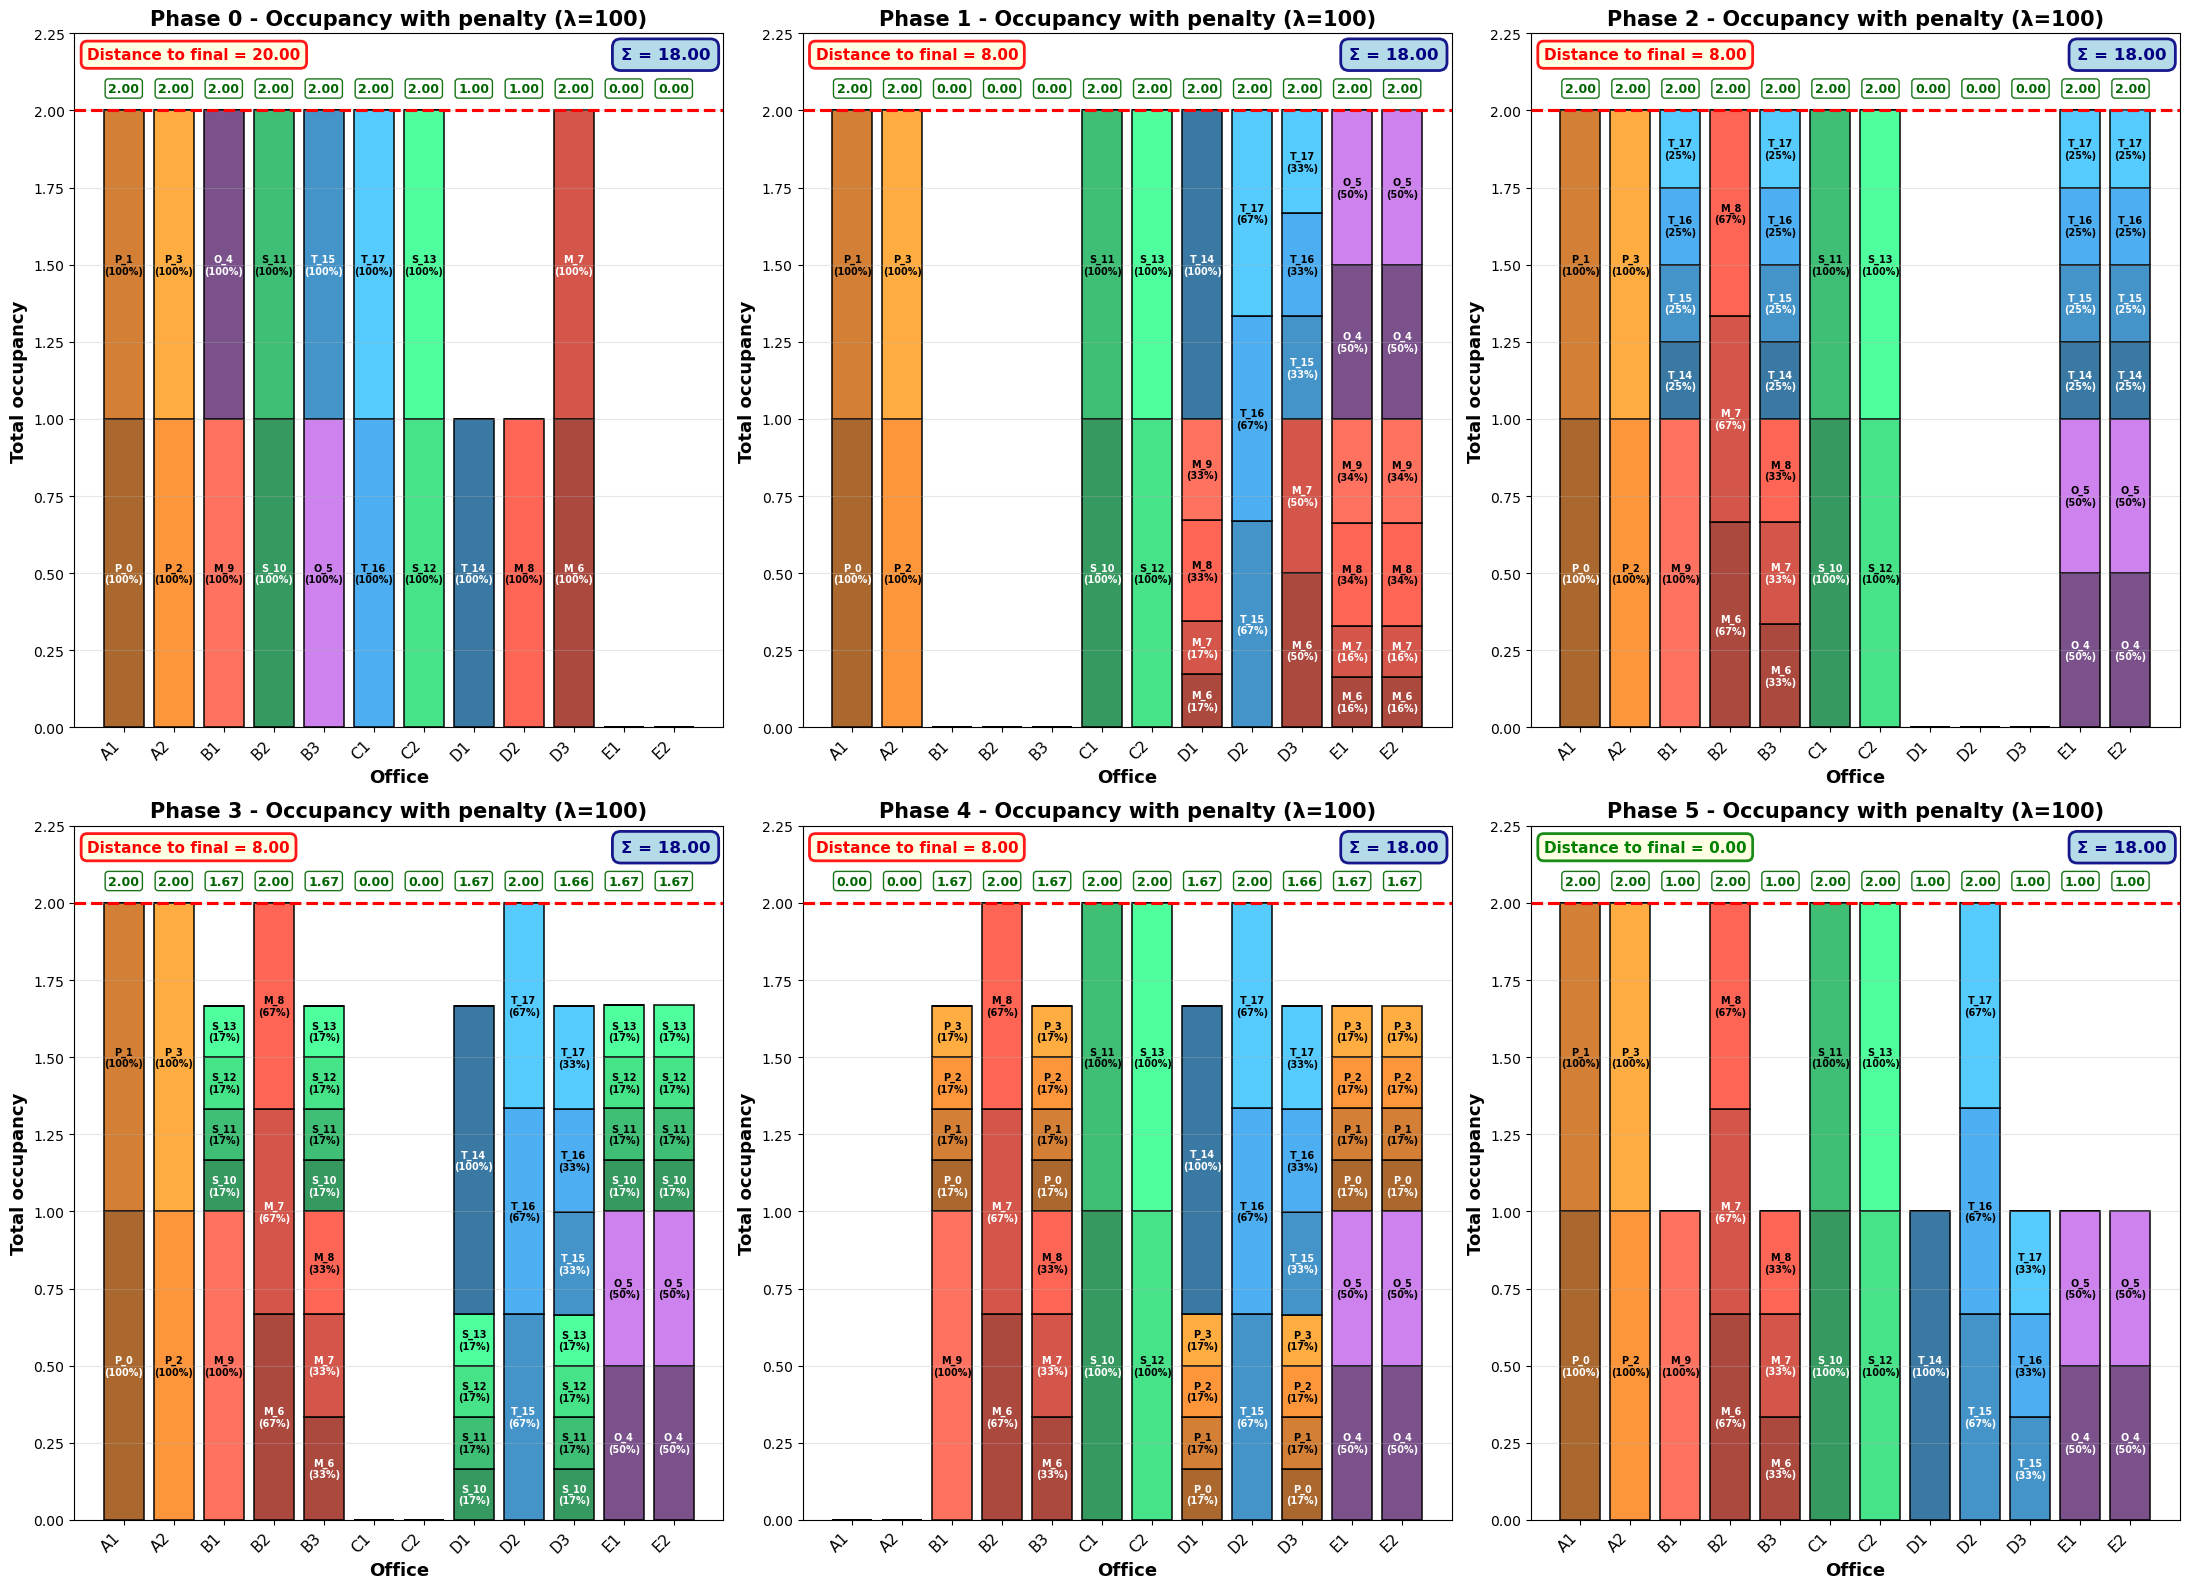


Figure saved: office_occupancy_detailed_q4.png

COMPARATIVE SUMMARY Q1 vs Q4

Q1 (without penalty):
  Moves: 30.00
  Total distance to final allocation: N/A

Q4 (with penalty λ=100):
  Moves: 38.00
  Total distance to final allocation: 52.00
  Increase in moves: +8.00
  Relative increase: +26.67%

Distance to final allocation by phase:
  Phase 0:  20.00  ✗ Far
  Phase 1:   8.00  ✗ Far
  Phase 2:   8.00  ✗ Far
  Phase 3:   8.00  ✗ Far
  Phase 4:   8.00  ✗ Far
  Phase 5:   0.00  ✓ Close


In [49]:
if z.value is not None and prob_penalized.status == 'optimal':
    # Define colors by service (same as Q2)
    service_colors_base = {
        'M': '#e74c3c',  # Red
        'P': '#e67e22',  # Orange
        'T': '#3498db',  # Blue
        'S': '#2ecc71',  # Green
        'O': '#9b59b6'   # Purple
    }
    
    # Function to generate shades of a color
    def generate_color_shades(base_color, n_shades):
        """Generate n shades of a base color"""
        import matplotlib.colors as mcolors
        
        if n_shades == 1:
            return [base_color]
        
        # Convert hex to RGB
        rgb = mcolors.hex2color(base_color)
        
        # Generate shades by varying brightness
        shades = []
        for i in range(n_shades):
            # Brightness factor between 0.6 and 1.2
            factor = 0.7 + (i / max(n_shades - 1, 1)) * 0.6
            new_rgb = tuple(min(1.0, c * factor) for c in rgb)
            shades.append(mcolors.rgb2hex(new_rgb))
        
        return shades
    
    # Create mappings: person -> service and person -> color
    personne_service = {}
    personne_couleur = {}
    
    for service, personnes in services.items():
        base_color = service_colors_base[service]
        n_personnes_service = len(personnes)
        couleurs = generate_color_shades(base_color, n_personnes_service)
        
        for idx, k in enumerate(personnes):
            personne_service[k] = service
            personne_couleur[k] = couleurs[idx]
    
    # Office occupancy per phase with per-person detail (Q4)
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    for p in range(n_phases):
        ax = axes[p]
        
        # For each office, collect present persons
        bureau_personnes = {i: [] for i in range(n_offices)}
        bureau_occupation_totale = np.zeros(n_offices)
        
        for i in range(n_offices):
            for k in range(n_people):
                occupation = z.value[k, i, p]
                if occupation > 0.01:  # Threshold to ignore negligible values
                    bureau_personnes[i].append((k, occupation))
                    bureau_occupation_totale[i] += occupation
            
            # Sort by service then by ID for visual consistency
            bureau_personnes[i].sort(key=lambda x: (personne_service[x[0]], x[0]))
        
        # Create stacked bars
        x_pos = np.arange(n_offices)
        bottom = np.zeros(n_offices)
        
        # Plot each person individually
        personnes_tracees = set()
        
        for i in range(n_offices):
            for k, occupation in bureau_personnes[i]:
                service = personne_service[k]
                couleur = personne_couleur[k]
                
                values = np.zeros(n_offices)
                values[i] = occupation
                
                label = f'{service}_{k}' if k not in personnes_tracees else None
                if k not in personnes_tracees:
                    personnes_tracees.add(k)
                
                ax.bar(
                    x_pos, values, bottom=bottom,
                    color=couleur, alpha=0.9,
                    edgecolor='black', linewidth=1.2,
                    label=label
                )
                
                if occupation > 0.05:
                    y_pos = bottom[i] + occupation / 2
                    label_text = f'{service}_{k}\n({occupation:.0%})'
                    
                    import matplotlib.colors as mcolors
                    rgb = mcolors.hex2color(couleur)
                    luminance = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
                    text_color = 'white' if luminance < 0.5 else 'black'
                    
                    ax.text(
                        i, y_pos, label_text,
                        ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color=text_color
                    )
                
                bottom[i] += occupation
        
        # Maximum capacity line
        ax.axhline(
            y=2, color='red', linestyle='--', linewidth=2.25,
            label='Max capacity (2)', zorder=10
        )
        
        # Display occupancy values above the red line
        y_align = 2.05
        for i in range(n_offices):
            occ_totale = bureau_occupation_totale[i]
            text_color = 'red' if occ_totale > 2.01 else 'darkgreen'
            
            ax.text(
                i, y_align, f'{occ_totale:.2f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color=text_color,
                bbox=dict(
                    boxstyle='round,pad=0.25',
                    facecolor='white' if occ_totale <= 2.01 else 'mistyrose',
                    edgecolor=text_color,
                    linewidth=1.5 if occ_totale > 2.01 else 1,
                    alpha=0.9
                )
            )
        
        # Total occupancy (top-right)
        somme_totale = bureau_occupation_totale.sum()
        ax.text(
            0.98, 0.98, f'Σ = {somme_totale:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=12, fontweight='bold',
            color='navy',
            bbox=dict(
                boxstyle='round,pad=0.5',
                facecolor='lightblue',
                edgecolor='navy',
                linewidth=2,
                alpha=0.9
            )
        )
        
        # Distance to final allocation (top-left)
        if e.value is not None:
            distance_phase = np.sum(e.value[:, :, p])
            color_dist = 'green' if distance_phase < 0.1 else 'orange' if distance_phase < 1 else 'red'
            
            ax.text(
                0.02, 0.98, f'Distance to final = {distance_phase:.2f}',
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=11, fontweight='bold',
                color=color_dist,
                bbox=dict(
                    boxstyle='round,pad=0.4',
                    facecolor='lightyellow',
                    edgecolor=color_dist,
                    linewidth=2,
                    alpha=0.9
                )
            )
        
        # Formatting
        ax.set_xlabel('Office', fontsize=13, fontweight='bold')
        ax.set_ylabel('Total occupancy', fontsize=13, fontweight='bold')
        ax.set_title(
            f'Phase {p} - Occupancy with penalty (λ={lambda_penalty})',
            fontsize=15, fontweight='bold'
        )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(offices, rotation=45, ha='right', fontsize=11)
        ax.set_ylim([0, 2.25])
        ax.grid(True, alpha=0.3, axis='y', zorder=0)
        
        # Highlight over-occupied offices
        for i in range(n_offices):
            if office_total_occupancy[i] > 2.01:
                ax.add_patch(
                    plt.Rectangle(
                        (i-0.4, 0), 0.8, 2.25,
                        fill=False, edgecolor='red',
                        linewidth=3, linestyle=':', zorder=11
                    )
                )
                ax.text(i, 2.42, '⚠️', ha='center', va='top',
                        fontsize=16, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('office_occupancy_detailed_q4.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("\nFigure saved: office_occupancy_detailed_q4.png")
    
    # Comparative summary
    print("\n" + "="*70)
    print("COMPARATIVE SUMMARY Q1 vs Q4")
    print("="*70)
    
    if d.value is not None and e.value is not None:
        moves_q4 = 0.5 * np.sum(d.value)
        total_distance_q4 = np.sum(e.value)
        
        print(f"\nQ1 (without penalty):")
        print(f"  Moves: {result:.2f}")
        print(f"  Total distance to final allocation: N/A")
        
        print(f"\nQ4 (with penalty λ={lambda_penalty}):")
        print(f"  Moves: {moves_q4:.2f}")
        print(f"  Total distance to final allocation: {total_distance_q4:.2f}")
        print(f"  Increase in moves: +{(moves_q4 - result):.2f}")
        
        if result > 0:
            print(f"  Relative increase: +{((moves_q4 - result) / result * 100):.2f}%")
        
        print(f"\nDistance to final allocation by phase:")
        for p in range(n_phases):
            dist_p = np.sum(e.value[:, :, p])
            status = "✓ Close" if dist_p < 0.1 else "→ Intermediate" if dist_p < 1 else "✗ Far"
            print(f"  Phase {p}: {dist_p:6.2f}  {status}")


### 5.5 Analysis of convergence toward the final allocation


COMPARISON: CONVERGENCE WITH AND WITHOUT PENALTY
Phase 0 (no penalty): distance = 29.019811
Phase 1 (no penalty): distance = 25.165905
Phase 2 (no penalty): distance = 18.000000
Phase 3 (no penalty): distance = 14.309762
Phase 4 (no penalty): distance = 11.760117
Phase 5 (no penalty): distance = 0.000000

Phase 0 (penalty λ=100): distance = 20.000000
Phase 1 (penalty λ=100): distance = 8.000000
Phase 2 (penalty λ=100): distance = 8.000000
Phase 3 (penalty λ=100): distance = 8.000000
Phase 4 (penalty λ=100): distance = 8.000000
Phase 5 (penalty λ=100): distance = 0.000000


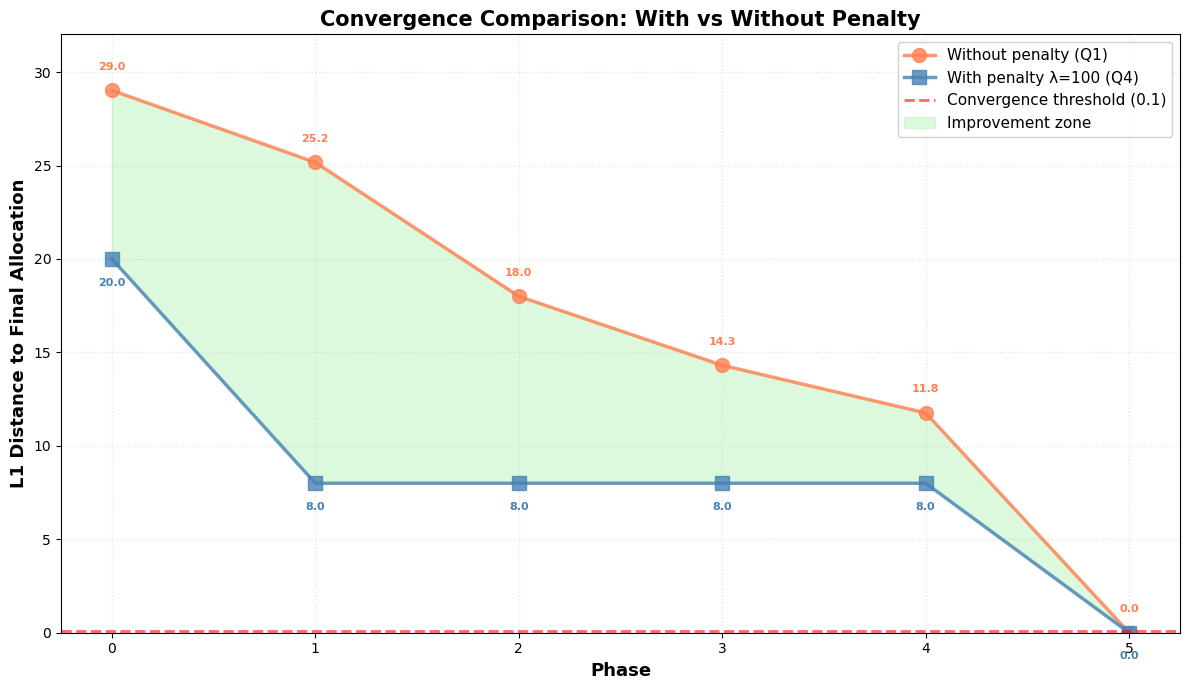


SUMMARY STATISTICS

Total cumulative distance (sum over all phases):
  Without penalty: 98.26
  With penalty:    52.00
  Reduction:       46.26 (47.1%)

Phase-by-phase comparison:
Phase    No Penalty      With Penalty    Improvement    
------------------------------------------------------------
0        29.02           20.00           9.02           
1        25.17           8.00            17.17          
2        18.00           8.00            10.00          
3        14.31           8.00            6.31           
4        11.76           8.00            3.76           
5        0.00            0.00            0.00           

Chart saved: convergence_comparison_q1_vs_q4.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*70)
print("COMPARISON: CONVERGENCE WITH AND WITHOUT PENALTY")
print("="*70)

# NOTE: You need to run this code after solving BOTH problems:
# 1. First solve Q1 (without penalty) and save: z_q1 = z.value.copy()
# 2. Then solve Q4 (with penalty) and save: z_q4 = z.value.copy() and e_q4 = e.value.copy()

# Compute distances for solution WITHOUT penalty (Q1)
distances_no_penalty = []
for p in range(n_phases):
    distance = 0.0
    for k in range(n_people):
        for i in range(n_offices):
            distance += abs(z_q1[k, i, p] - z_q1[k, i, 5])
    distances_no_penalty.append(distance)
    print(f"Phase {p} (no penalty): distance = {distance:.6f}")

print()

# Compute distances for solution WITH penalty (Q4)
distances_penalty = []
for p in range(n_phases):
    distance = np.sum(e_q4[:, :, p])
    distances_penalty.append(distance)
    print(f"Phase {p} (penalty λ={lambda_penalty}): distance = {distance:.6f}")

# Comparison visualization
fig, ax = plt.subplots(figsize=(12, 7))

phases = list(range(n_phases))

# Plot both curves
ax.plot(phases, distances_no_penalty, marker='o', linewidth=2.5, 
        markersize=10, color='coral', label='Without penalty (Q1)', 
        linestyle='-', alpha=0.8)

ax.plot(phases, distances_penalty, marker='s', linewidth=2.5, 
        markersize=10, color='steelblue', label=f'With penalty λ={lambda_penalty} (Q4)', 
        linestyle='-', alpha=0.8)

# Convergence threshold line
convergence_threshold = 0.1
ax.axhline(y=convergence_threshold, color='red', linestyle='--', 
           linewidth=2, label=f'Convergence threshold ({convergence_threshold})', 
           alpha=0.6)

# Fill area between curves to show improvement
ax.fill_between(phases, distances_no_penalty, distances_penalty, 
                where=(np.array(distances_no_penalty) >= np.array(distances_penalty)),
                color='lightgreen', alpha=0.3, label='Improvement zone')

# Add value labels on points
for p in phases:
    # Label for no penalty
    ax.text(p, distances_no_penalty[p] + 1, f'{distances_no_penalty[p]:.1f}', 
           ha='center', va='bottom', fontsize=8, color='coral', fontweight='bold')
    
    # Label for penalty
    ax.text(p, distances_penalty[p] - 1, f'{distances_penalty[p]:.1f}', 
           ha='center', va='top', fontsize=8, color='steelblue', fontweight='bold')

# Styling
ax.set_xlabel('Phase', fontsize=13, fontweight='bold')
ax.set_ylabel('L1 Distance to Final Allocation', fontsize=13, fontweight='bold')
ax.set_title('Convergence Comparison: With vs Without Penalty', 
            fontsize=15, fontweight='bold')
ax.set_xticks(phases)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Set y-axis to start from 0 for better visualization
ax.set_ylim(bottom=0, top=max(max(distances_no_penalty), max(distances_penalty)) + 3)

plt.tight_layout()
plt.savefig('convergence_comparison_q1_vs_q4.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

total_distance_no_penalty = sum(distances_no_penalty)
total_distance_penalty = sum(distances_penalty)

print(f"\nTotal cumulative distance (sum over all phases):")
print(f"  Without penalty: {total_distance_no_penalty:.2f}")
print(f"  With penalty:    {total_distance_penalty:.2f}")
print(f"  Reduction:       {total_distance_no_penalty - total_distance_penalty:.2f} ({100*(total_distance_no_penalty - total_distance_penalty)/total_distance_no_penalty:.1f}%)")

print(f"\nPhase-by-phase comparison:")
print(f"{'Phase':<8} {'No Penalty':<15} {'With Penalty':<15} {'Improvement':<15}")
print("-" * 60)
for p in phases:
    improvement = distances_no_penalty[p] - distances_penalty[p]
    print(f"{p:<8} {distances_no_penalty[p]:<15.2f} {distances_penalty[p]:<15.2f} {improvement:<15.2f}")

print("\nChart saved: convergence_comparison_q1_vs_q4.png")

---
# Part 3: Semidefinite programming relaxation
## Question 7: Compute the solution to your semidefinite program
### 7.1 Solving SDP

In [51]:
import cvxpy as cp
import numpy as np
import pickle
import os
import time

# Cache file
CACHE_FILE = 'sdp_scs_compiled.pkl'

K = 18
offices = ['A1', 'A2', 'B1', 'B2', 'B3', 'C1', 'C2', 'D1', 'D2', 'D3', 'E1', 'E2']
I = len(offices)
office_idx = {b: i for i, b in enumerate(offices)}
P = 6

services = {
    'P': [0, 1, 2, 3], 'O': [4, 5], 'M': [6, 7, 8, 9],
    'S': [10, 11, 12, 13], 'T': [14, 15, 16, 17]
}

closed_offices = {
    0: ['E1', 'E2'], 1: ['B1', 'B2', 'B3'], 2: ['D1', 'D2', 'D3'],
    3: ['C1', 'C2'], 4: ['A1', 'A2']
}

initial_positions = {
    0: 'A1', 1: 'A1', 2: 'A2', 3: 'A2', 4: 'B1', 5: 'B3',
    6: 'D3', 7: 'D3', 8: 'D2', 9: 'B1', 10: 'B2', 11: 'B2',
    12: 'C2', 13: 'C2', 14: 'D1', 15: 'B3', 16: 'C1', 17: 'C1'
}

final_allocations = {
    'P': ['A1', 'A2'],
    'M': ['B1', 'B2', 'B3'],
    'S': ['C1', 'C2'],
    'T': ['D1', 'D2', 'D3'],
    'O': ['E1', 'E2']
}

N = K * I * P
n_vars_sym = N * (N + 1) // 2
print(f"Dimension: N = {N}")
print(f"Variables with symmetry: {n_vars_sym:,}")

def phi(k, i, p):
    return k * I * P + i * P + p

U = cp.Variable((N, N), symmetric=True)
u = cp.Variable(N)

print("\n" + "="*70)
print("OBJECTIVE CONSTRUCTION")
print("="*70)

# Compute all terms U[phi(k,i,p), phi(k,i,p+1)]
U_transition_terms = []
for k in range(K):
    for p in range(P-1):
        for i in range(I):
            U_transition_terms.append(U[phi(k, i, p), phi(k, i, p+1)])

n_terms = len(U_transition_terms)
print(f"Number of U terms: {n_terms}")
print(f"  = K × (P-1) × I = {K} × {P-1} × {I} = {K*(P-1)*I}")

# Corrected formula:
# sum(U_terms) = K×(P-1)×I - 4D
# therefore: 4D = K×(P-1)×I - sum(U_terms)
# therefore: D = (K×(P-1)×I - sum(U_terms)) / 4

baseline = K * (P - 1) * I
objective = cp.Minimize(0.25 * (baseline - cp.sum(U_transition_terms)))

print(f"\nObjective: min( 0.25 × ({baseline} - sum(U_terms)) )")
print(f"  = min( 0.25 × (1080 - sum(U_terms)) )")
print(f"\nInterpretation:")
print(f"  If D relocations → sum(U_terms) = {baseline} - 4D")
print(f"  → obj = 0.25 × 4D = D ✓")

print("\n" + "="*70)
print("CONSTRAINTS CONSTRUCTION")
print("="*70)

constraints = [U >> 0]

# Main SDP constraint: [U u; u^T 1] ⪰ 0
M = cp.bmat([[U, cp.reshape(u, (N, 1), order='F')], 
             [cp.reshape(u, (1, N), order='F'), np.array([[1]])]])
constraints.append(M >> 0)

# Diagonal normalization
for j in range(N):
    constraints.append(U[j, j] == 1)

constraints.append(u >= -1)
constraints.append(u <= 1)

print("C1: One person / one office per phase...")
for k in range(K):
    for p in range(P):
        # sum_i u[phi(k,i,p)] = 2 - I
        # (1 office +1, I-1 offices -1) = 1 + (-1)(I-1) = 2-I
        sum_u = cp.sum([u[phi(k, i, p)] for i in range(I)])
        constraints.append(sum_u == 2 - I)

print("C2: Office capacity (max 2 persons)...")
for i in range(I):
    for p in range(P):
        # sum_k u[phi(k,i,p)] ≤ 4 - K
        # (2 persons +1, K-2 persons -1) = 2 + (-1)(K-2) = 4-K
        sum_u = cp.sum([u[phi(k, i, p)] for k in range(K)])
        constraints.append(sum_u <= 4 - K)

print("C4: Closed offices...")
for p in range(P):
    if p in closed_offices:
        for bf in closed_offices[p]:
            i = office_idx[bf]
            for k in range(K):
                constraints.append(u[phi(k, i, p)] == -1)

print("C5: Initial positions (phase 0)...")
for k in range(K):
    i_init = office_idx[initial_positions[k]]
    for i in range(I):
        idx = phi(k, i, 0)
        if i == i_init:
            constraints.append(u[idx] == 1)
        else:
            constraints.append(u[idx] == -1)

print("C6: Final allocations (phase 5)...")
for service, service_offices in final_allocations.items():
    people = services[service]
    office_indices = [office_idx[b] for b in service_offices]
    for k in people:
        # Person k must be in exactly one office of their service
        # sum_i u[phi(k,i,5)] = 2 - len(service_offices)
        sum_expr = cp.sum([u[phi(k, i, 5)] for i in office_indices])
        constraints.append(sum_expr == 2 - len(office_indices))

# Service-specific constraints (exact distribution)
# Mathematics (M) in wing B: 1 in B1, 2 in B2, 1 in B3
constraints.append(
    cp.sum([u[phi(k, office_idx['B1'], 5)] for k in services['M']]) == 2*1 - len(services['M'])
)
constraints.append(
    cp.sum([u[phi(k, office_idx['B2'], 5)] for k in services['M']]) == 2*2 - len(services['M'])
)

# Theoretical CS (T) in wing D: 1 in D1, 2 in D2, 1 in D3
constraints.append(
    cp.sum([u[phi(k, office_idx['D1'], 5)] for k in services['T']]) == 2*1 - len(services['T'])
)
constraints.append(
    cp.sum([u[phi(k, office_idx['D2'], 5)] for k in services['T']]) == 2*2 - len(services['T'])
)

# Optimization (O) in wing E: 1 in E1, 1 in E2
constraints.append(
    cp.sum([u[phi(k, office_idx['E1'], 5)] for k in services['O']]) == 2*1 - len(services['O'])
)

print(f"\nTotal constraints: {len(constraints)}")
print(f"  - 2 SDP matrix constraints")
print(f"  - {len(constraints)-2} scalar constraints")

problem = cp.Problem(objective, constraints)

print("\n" + "="*70)
print("COMPILATION")
print("="*70)

if os.path.exists(CACHE_FILE):
    print(f"✓ Compilation found in {CACHE_FILE}")
    print(f"  Size: {os.path.getsize(CACHE_FILE)/1e6:.1f} MB")
    print("  Loading...")
    
    with open(CACHE_FILE, 'rb') as f:
        cache_data = pickle.load(f)
    
    print("✓ Loaded!")
    
else:
    print("First run: compilation needed")
    
    start = time.time()
    
    data, chain, inverse_data = problem.get_problem_data(solver=cp.SCS)
    
    compile_time = time.time() - start
    
    cache_data = {
        'data': data,
        'chain': chain,
        'inverse_data': inverse_data,
        'compile_time': compile_time
    }
    
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f"✓ Compilation finished in {compile_time/60:.1f} minutes")
    print(f"✓ Saved in {CACHE_FILE} ({os.path.getsize(CACHE_FILE)/1e6:.1f} MB)")


Dimension: N = 1296
Variables with symmetry: 840,456

OBJECTIVE CONSTRUCTION
Number of U terms: 1080
  = K × (P-1) × I = 18 × 5 × 12 = 1080

Objective: min( 0.25 × (1080 - sum(U_terms)) )
  = min( 0.25 × (1080 - sum(U_terms)) )

Interpretation:
  If D relocations → sum(U_terms) = 1080 - 4D
  → obj = 0.25 × 4D = D ✓

CONSTRAINTS CONSTRUCTION
C1: One person / one office per phase...
C2: Office capacity (max 2 persons)...
C4: Closed offices...
C5: Initial positions (phase 0)...
C6: Final allocations (phase 5)...

Total constraints: 1935
  - 2 SDP matrix constraints
  - 1933 scalar constraints

COMPILATION
First run: compilation needed
Estimated time: 20-30 minutes
This step is done only once!

✓ Compilation finished in 3.8 minutes
✓ Saved in sdp_scs_compiled.pkl (206.3 MB)


In [ ]:
print("\n" + "="*70)
print("SDP SOLUTION WITH SCS")
print("="*70)
print(f"Estimated time: 1-2 hours\n")

start_time = time.time()

problem.solve(
    solver=cp.SCS, 
    verbose=True,
    warm_start=True,
    eps_abs=1e-6,          
    eps_rel=1e-6,
    max_iters=10000,       
    alpha=1.5,             
    scale=1.0,             
    normalize=True,
    acceleration_lookback=20,
    use_indirect=False
)

solve_time = time.time() - start_time
print(f"\n✓ Solution completed in {solve_time/60:.1f} minutes")

print(f"\n{'='*70}")
print("RESULTS")
print(f"{'='*70}")
print(f"Status: {problem.status}")

if problem.value is not None:
    print(f"\nSDP objective value: {problem.value:.4f}")
    print(f"  (Reminder: optimal MIP solution = 30 relocations)")
    
    if u.value is None:
        print(f"\nERROR: Variables have no value")
        print(f"   This indicates that the solver did not converge correctly")
    elif problem.status in ['optimal', 'optimal_inaccurate']:
        u_val = u.value
        
        print(f"\n{'='*70}")
        print("SDP SOLUTION ANALYSIS")
        print(f"{'='*70}")
        
        print(f"\nStatistics on u:")
        print(f"  Min: {np.min(u_val):.4f}")
        print(f"  Max: {np.max(u_val):.4f}")
        print(f"  Mean: {np.mean(u_val):.4f}")
        
        binary_approx = np.abs(u_val)
        frac_binary = np.mean(binary_approx > 0.9)
        frac_fractional = np.mean((binary_approx > 0.1) & (binary_approx < 0.9))
        print(f"  ~Binary fraction (|u|>0.9): {100*frac_binary:.1f}%")
        print(f"  Fractional fraction (0.1<|u|<0.9): {100*frac_fractional:.1f}%")
        
        # Check constraints
        print(f"\nConstraint check:")
        violations_c1 = 0
        for k in range(K):
            for p in range(P):
                sum_u = sum(u_val[phi(k, i, p)] for i in range(I))
                expected = 2 - I
                if abs(sum_u - expected) > 0.01:
                    violations_c1 += 1
        print(f"  C1 (one person/one office): {violations_c1} violations")
        
        print(f"\n{'='*70}")
        print("Detailed relocation calculation will be done in the visualization")
        print(f"{'='*70}")
else:
    print("Solution failed")


(CVXPY) Jan 28 03:15:36 AM: Your problem has 1680912 variables, 3366348 constraints, and 0 parameters.
(CVXPY) Jan 28 03:15:36 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 28 03:15:36 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 28 03:15:36 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 28 03:15:36 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 28 03:15:36 AM: Using cached ASA map, for faster compilation (bypassing reduction chain).
(CVXPY) Jan 28 03:15:36 AM: Finished problem compilation (took 3.929e-02 seconds).
(CVXPY) Jan 28 03:15:36 AM: Invoking solver SCS  to obtain a solution.



SDP SOLUTION WITH SCS
⏱️ Estimated time: 1-2 hours

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.8 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 841752, constraints m: 1686732
cones: 	  z: primal zero

/Users/macchenf/anaconda3/envs/opt_env/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Jan 28 03:44:58 PM: Problem status: optimal_inaccurate
(CVXPY) Jan 28 03:44:58 PM: Optimal value: 2.462e+01
(CVXPY) Jan 28 03:44:58 PM: Compilation took 3.929e-02 seconds
(CVXPY) Jan 28 03:44:58 PM: Solver (including time spent in interface) took 4.496e+04 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

✓ Solution completed in 749.4 minutes

RESULTS
Status: optimal_inaccurate

SDP objective value: 24.6198
  (Reminder: optimal MIP solution = 30 relocations)

SDP SOLUTION ANALYSIS

Statistics on u:
  Min: -1.0001
  Max: 1.0001
  Mean: -0.8333
  ~Binary fraction (|u|>0.9): 78.5%
  Fractional fraction (0.1<|u|<0.9): 17.0%

Constraint check:
  C1 (one person/one office): 0 violations

Detailed relocation calculation will be done in the visualization


### 7.2 Visualization of the fractional SDP solution


GENERATING SDP VISUALIZATION

Calculating fractional relocations per phase...
  Phase 0→1: 6.31 relocations
  Phase 1→2: 6.82 relocations
  Phase 2→3: 6.14 relocations
  Phase 3→4: 5.16 relocations
  Phase 4→5: 6.14 relocations
  TOTAL: 30.57 relocations


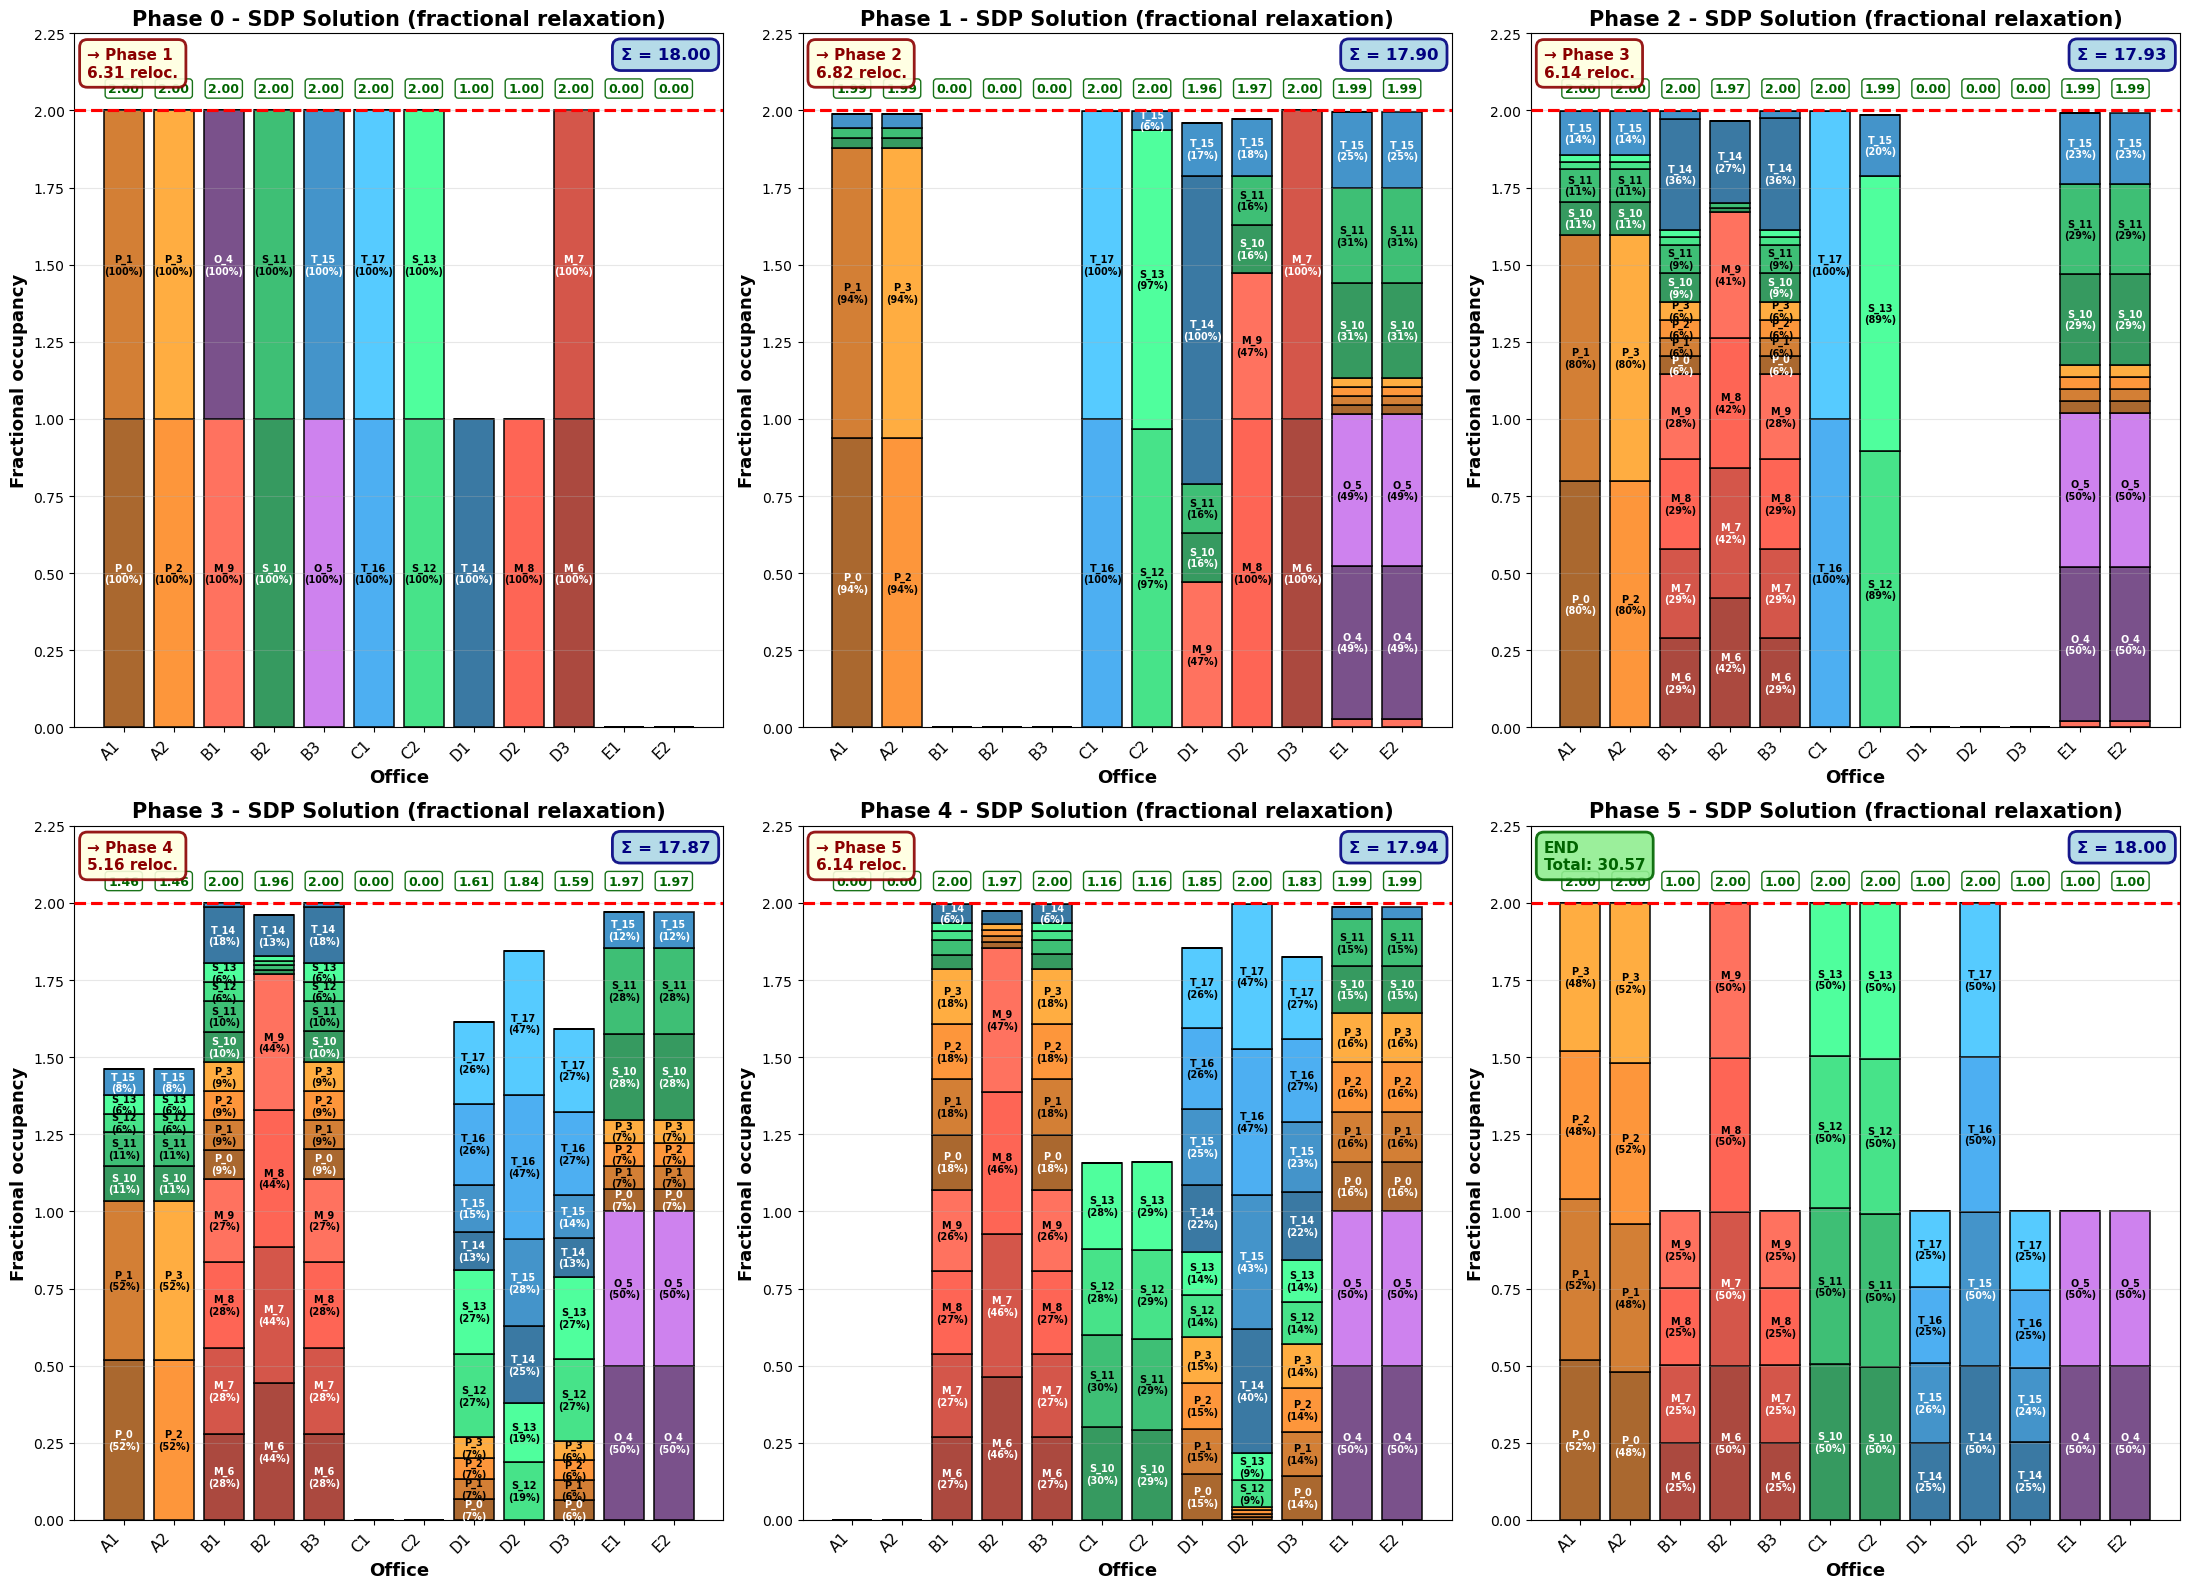


✓ Plot saved: occupation_bureaux_sdp_fractionnaire.png

FRACTIONALITY ANALYSIS

Statistics on z_sdp (occupancy):
  ~Binary values (≈0 or ≈1): 953/1296 (73.5%)
  Fractional values (0.01-0.99): 343/1296 (26.5%)
  Min: -0.0001, Max: 1.0001
  Mean: 0.0833, Median: 0.0000

Distribution of values in [0.1, 0.9]:
  [0.1, 0.9]: 219 values (16.9%)
  [0.2, 0.8]: 157 values (12.1%)
  [0.3, 0.7]: 76 values (5.9%)
  [0.4, 0.6]: 68 values (5.2%)
  [0.5, 0.5]: 0 values (0.0%)
  [0.6, 0.4]: 0 values (0.0%)
  [0.7, 0.3]: 0 values (0.0%)
  [0.8, 0.2]: 0 values (0.0%)
  [0.9, 0.1]: 0 values (0.0%)

RELOCATIONS SUMMARY (SDP)
Phase 0→1: 6.31 relocations
Phase 1→2: 6.82 relocations
Phase 2→3: 6.14 relocations
Phase 3→4: 5.16 relocations
Phase 4→5: 6.14 relocations

TOTAL: 30.57 relocations
SDP objective value: 24.62
Optimal MIP solution: 30 relocations



In [53]:
# ============================================================================
# VISUALIZATION OF THE FRACTIONAL SDP SOLUTION
# ============================================================================

if problem.status in ['optimal', 'optimal_inaccurate'] and u.value is not None:
    print("\n" + "="*70)
    print("GENERATING SDP VISUALIZATION")
    print("="*70)
    
    # Reconstruct z from u for visualization
    # z[k,i,p] ≈ (1 + u[phi(k,i,p)]) / 2
    z_sdp = np.zeros((K, I, P))
    
    for k in range(K):
        for i in range(I):
            for p in range(P):
                z_sdp[k, i, p] = (1 + u.value[phi(k, i, p)]) / 2
    
    # CALCULATE RELOCATIONS PER PHASE (same method as LP)
    print("\nCalculating fractional relocations per phase...")
    relocations_per_phase = []
    
    for p in range(P-1):
        relocations = 0
        for k in range(K):
            # Absolute difference between each office's occupancy
            diff_total = 0
            for i in range(I):
                diff = abs(z_sdp[k, i, p+1] - z_sdp[k, i, p])
                diff_total += diff
            
            # Sum of absolute differences = 2 * (# relocations)
            relocations += diff_total / 2
        
        relocations_per_phase.append(relocations)
        print(f"  Phase {p}→{p+1}: {relocations:.2f} relocations")
    
    total_relocations = sum(relocations_per_phase)
    print(f"  TOTAL: {total_relocations:.2f} relocations")
    
    # Create an object "z_value" compatible with visualization code
    class SDPVisualizationWrapper:
        def __init__(self, z_array):
            self.value = z_array
    
    z_vis = SDPVisualizationWrapper(z_sdp)
    
    # ========================================================================
    # VISUALIZATION (adapted from LP)
    # ========================================================================
    
    # Define colors by service
    service_colors_base = {
        'M': '#e74c3c',  # Red
        'P': '#e67e22',  # Orange
        'T': '#3498db',  # Blue
        'S': '#2ecc71',  # Green
        'O': '#9b59b6'   # Purple
    }
    
    def generate_color_shades(base_color, n_shades):
        """Generate n shades of a base color"""
        import matplotlib.colors as mcolors
        
        if n_shades == 1:
            return [base_color]
        
        rgb = mcolors.hex2color(base_color)
        shades = []
        for i in range(n_shades):
            factor = 0.7 + (i / max(n_shades - 1, 1)) * 0.6
            new_rgb = tuple(min(1.0, c * factor) for c in rgb)
            shades.append(mcolors.rgb2hex(new_rgb))
        
        return shades
    
    # Create mapping person -> service and person -> color
    person_service = {}
    person_color = {}
    
    for service, persons in services.items():
        base_color = service_colors_base[service]
        n_persons_service = len(persons)
        colors = generate_color_shades(base_color, n_persons_service)
        
        for idx, k in enumerate(persons):
            person_service[k] = service
            person_color[k] = colors[idx]
    
    service_names = {
        'M': 'Mathematics',
        'P': 'Presidency',
        'T': 'Theoretical CS',
        'S': 'Students',
        'O': 'Optimization'
    }
    
    # Office occupancy per phase
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    for p in range(P):
        ax = axes[p]
        
        # For each office, collect the people present
        office_persons = {i: [] for i in range(I)}
        office_total_occupancy = np.zeros(I)
        
        for i in range(I):
            for k in range(K):
                occupancy = z_vis.value[k, i, p]
                if occupancy > 0.01:
                    office_persons[i].append((k, occupancy))
                    office_total_occupancy[i] += occupancy
            
            office_persons[i].sort(key=lambda x: (person_service[x[0]], x[0]))
        
        # Create stacked bars
        x_pos = np.arange(I)
        bottom = np.zeros(I)
        
        plotted_persons = set()
        
        for i in range(I):
            for k, occupancy in office_persons[i]:
                service = person_service[k]
                color = person_color[k]
                
                values = np.zeros(I)
                values[i] = occupancy
                
                label = f'{service}_{k}' if k not in plotted_persons else None
                if k not in plotted_persons:
                    plotted_persons.add(k)
                
                bars = ax.bar(x_pos, values, bottom=bottom, 
                              color=color, 
                              alpha=0.9, 
                              edgecolor='black',
                              linewidth=1.2,
                              label=label)
                
                if occupancy > 0.05:
                    y_pos = bottom[i] + occupancy/2
                    label_text = f'{service}_{k}\n({occupancy:.0%})'
                    
                    import matplotlib.colors as mcolors
                    rgb = mcolors.hex2color(color)
                    luminance = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
                    text_color = 'white' if luminance < 0.5 else 'black'
                    
                    ax.text(i, y_pos, label_text, 
                           ha='center', va='center',
                           fontsize=7, fontweight='bold',
                           color=text_color)
                
                bottom[i] += occupancy
        
        # Max capacity line
        ax.axhline(y=2, color='red', linestyle='--', linewidth=2.25, 
                  label='Max capacity (2)', zorder=10)
        
        # Display occupancy above the red line
        y_align = 2.05
        for i in range(I):
            total_occ = office_total_occupancy[i]
            text_color = 'red' if total_occ > 2.01 else 'darkgreen'
            fontweight = 'bold'
            
            ax.text(i, y_align, f'{total_occ:.2f}', 
                   ha='center', va='bottom',
                   fontsize=9, fontweight=fontweight,
                   color=text_color,
                   bbox=dict(boxstyle='round,pad=0.25', 
                            facecolor='white' if total_occ <= 2.01 else 'mistyrose',
                            edgecolor=text_color, 
                            linewidth=1.5 if total_occ > 2.01 else 1,
                            alpha=0.9))
        
        # Total occupancy sum
        total_sum = office_total_occupancy.sum()
        ax.text(0.98, 0.98, f'Σ = {total_sum:.2f}', 
               transform=ax.transAxes,
               ha='right', va='top',
               fontsize=12, fontweight='bold',
               color='navy',
               bbox=dict(boxstyle='round,pad=0.5', 
                        facecolor='lightblue',
                        edgecolor='navy', 
                        linewidth=2,
                        alpha=0.9))
        
        # Display number of relocations for this transition
        if p < P-1:
            relocations_transition = relocations_per_phase[p]
            ax.text(0.02, 0.98, f'→ Phase {p+1}\n{relocations_transition:.2f} reloc.', 
                   transform=ax.transAxes,
                   ha='left', va='top',
                   fontsize=11, fontweight='bold',
                   color='darkred',
                   bbox=dict(boxstyle='round,pad=0.5', 
                            facecolor='lightyellow',
                            edgecolor='darkred', 
                            linewidth=2,
                            alpha=0.9))
        else:
            # Last phase: display total
            ax.text(0.02, 0.98, f'END\nTotal: {total_relocations:.2f}', 
                   transform=ax.transAxes,
                   ha='left', va='top',
                   fontsize=11, fontweight='bold',
                   color='darkgreen',
                   bbox=dict(boxstyle='round,pad=0.5', 
                            facecolor='lightgreen',
                            edgecolor='darkgreen', 
                            linewidth=2,
                            alpha=0.9))
        
        # Formatting
        ax.set_xlabel('Office', fontsize=13, fontweight='bold')
        ax.set_ylabel('Fractional occupancy', fontsize=13, fontweight='bold')
        ax.set_title(f'Phase {p} - SDP Solution (fractional relaxation)', 
                    fontsize=15, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(offices, rotation=45, ha='right', fontsize=11)
        ax.set_ylim([0, 2.25])
        
        ax.grid(True, alpha=0.3, axis='y', zorder=0)
        
        # Highlight over-occupied offices
        for i in range(I):
            if office_total_occupancy[i] > 2.01:
                ax.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 2.25, 
                                          fill=False, edgecolor='red', 
                                          linewidth=3, linestyle=':', zorder=11))
                ax.text(i, 2.42, '⚠', ha='center', va='top', 
                       fontsize=16, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('occupation_bureaux_sdp_fractionnaire.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("\n✓ Plot saved: occupation_bureaux_sdp_fractionnaire.png")
    
    # Fractionality statistics
    print("\n" + "="*70)
    print("FRACTIONALITY ANALYSIS")
    print("="*70)
    
    z_flat = z_sdp.flatten()
    n_binary = np.sum((z_flat < 0.01) | (z_flat > 0.99))
    n_fractional = np.sum((z_flat >= 0.01) & (z_flat <= 0.99))
    
    print(f"\nStatistics on z_sdp (occupancy):")
    print(f"  ~Binary values (≈0 or ≈1): {n_binary}/{len(z_flat)} ({100*n_binary/len(z_flat):.1f}%)")
    print(f"  Fractional values (0.01-0.99): {n_fractional}/{len(z_flat)} ({100*n_fractional/len(z_flat):.1f}%)")
    print(f"  Min: {np.min(z_flat):.4f}, Max: {np.max(z_flat):.4f}")
    print(f"  Mean: {np.mean(z_flat):.4f}, Median: {np.median(z_flat):.4f}")
    
    # Distribution of fractional values
    print(f"\nDistribution of values in [0.1, 0.9]:")
    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        n_above = np.sum((z_flat >= threshold) & (z_flat <= 1-threshold))
        print(f"  [{threshold:.1f}, {1-threshold:.1f}]: {n_above} values ({100*n_above/len(z_flat):.1f}%)")
    
    # Summary of relocations
    print(f"\n" + "="*70)
    print("RELOCATIONS SUMMARY (SDP)")
    print("="*70)
    for p in range(P-1):
        print(f"Phase {p}→{p+1}: {relocations_per_phase[p]:.2f} relocations")
    print(f"\nTOTAL: {total_relocations:.2f} relocations")
    print(f"SDP objective value: {problem.value:.2f}")
    print(f"Optimal MIP solution: 30 relocations")
    
    print("\n" + "="*70)

else:
    print("\nCannot generate visualization: SDP solution not available")


## Question 8 : Randomized Rounding
### 8.1 GOEMANS-WILLIAMSON Randomized rounding

In [54]:
# ============================================================================
# GOEMANS-WILLIAMSON RANDOMIZED ROUNDING
# ============================================================================

if problem.status in ['optimal', 'optimal_inaccurate'] and u.value is not None and U.value is not None:
    print("\n" + "="*70)
    print("GOEMANS-WILLIAMSON RANDOMIZED ROUNDING")
    print("="*70)
    
    U_val = U.value
    
    # Check positive semidefiniteness of U
    eigvals = np.linalg.eigvalsh(U_val)
    min_eig = np.min(eigvals)
    
    print(f"\nSpectrum of U:")
    print(f"  λ_min = {min_eig:.2e}")
    print(f"  λ_max = {np.max(eigvals):.2e}")
    
    # Regularize if necessary
    if min_eig < -1e-6:
        epsilon = -min_eig + 1e-6
        print(f"  Regularization needed: add {epsilon:.2e}×I")
        U_val = U_val + epsilon * np.eye(N)
        min_eig = np.min(np.linalg.eigvalsh(U_val))
        print(f"  ✓ New λ_min = {min_eig:.2e}")
    
    # Cholesky decomposition
    try:
        L = np.linalg.cholesky(U_val)
        print(f"\n✓ Cholesky decomposition successful")
        print(f"  Dimension of L: {L.shape}")
    except np.linalg.LinAlgError as e:
        print(f"\nCholesky error: {e}")
        print("Cannot perform randomized rounding")
        U_val = None
    
    if U_val is not None:
        # Generate rounded solutions
        n_samples = 100000
        print(f"\n{'='*70}")
        print(f"GENERATING {n_samples} ROUNDED SOLUTIONS")
        print(f"{'='*70}")
        
        solutions = []
        costs = []
        feasible_count = 0
        
        np.random.seed(42)  # For reproducibility
        
        for s in range(n_samples):
            # Goemans-Williamson sampling
            r = np.random.randn(N)
            r = r / np.linalg.norm(r)
            u_sample = L.T @ r
            u_binary = np.sign(u_sample)
            u_binary[u_binary == 0] = -1
            
            # Convert to binary x
            x_binary = (1 + u_binary) / 2
            
            # Check feasibility and compute cost
            feasible = True
            violations = []
            
            # C1: Each person in exactly one office
            for k in range(K):
                for p in range(P):
                    sum_x = sum(x_binary[phi(k, i, p)] for i in range(I))
                    if abs(sum_x - 1) > 1e-6:
                        feasible = False
                        violations.append(f"C1: person {k}, phase {p}")
                        break
                if not feasible:
                    break
            
            # C2: Office capacity (only if C1 OK)
            if feasible:
                for i in range(I):
                    for p in range(P):
                        sum_x = sum(x_binary[phi(k, i, p)] for k in range(K))
                        if sum_x > 2 + 1e-6:
                            feasible = False
                            violations.append(f"C2: office {offices[i]}, phase {p}")
                            break
                    if not feasible:
                        break
            
            # Compute cost (number of relocations)
            movements = 0
            for k in range(K):
                for i in range(I):
                    for p in range(P-1):
                        x_p = x_binary[phi(k, i, p)]
                        x_p1 = x_binary[phi(k, i, p+1)]
                        movements += abs(x_p - x_p1) / 2
            
            movements = int(round(movements))
            
            solutions.append({
                'u': u_binary.copy(),
                'x': x_binary.copy(),
                'cost': movements,
                'feasible': feasible,
                'violations': violations
            })
            
            costs.append(movements)
            if feasible:
                feasible_count += 1
            
            if (s+1) % 20 == 0:
                print(f"  [{s+1}/{n_samples}] Feasible: {feasible_count}, Costs: min={min(costs)}, avg={np.mean(costs):.1f}")
        
        # Statistics
        print(f"\n{'='*70}")
        print("GENERATED SOLUTIONS STATISTICS")
        print(f"{'='*70}")
        
        print(f"\nFeasibility:")
        print(f"  Feasible solutions: {feasible_count}/{n_samples} ({100*feasible_count/n_samples:.1f}%)")
        print(f"  Infeasible solutions: {n_samples - feasible_count}/{n_samples}")
        
        print(f"\nCosts (number of relocations):")
        print(f"  Minimum: {min(costs)}")
        print(f"  Maximum: {max(costs)}")
        print(f"  Average: {np.mean(costs):.2f}")
        print(f"  Median: {np.median(costs):.0f}")
        print(f"  Std dev: {np.std(costs):.2f}")
        
        # Cost distribution
        print(f"\nCost distribution:")
        unique_costs, counts = np.unique(costs, return_counts=True)
        for cost, count in zip(unique_costs, counts):
            bar = '█' * int(count / n_samples * 50)
            print(f"  {cost:3d} relocations: {bar} ({count})")
        
        # Best feasible solution
        if feasible_count > 0:
            feasible_solutions = [s for s in solutions if s['feasible']]
            best_feasible = min(feasible_solutions, key=lambda s: s['cost'])
            
            print(f"\n{'='*70}")
            print("BEST FEASIBLE SOLUTION")
            print(f"{'='*70}")
            print(f"  Cost: {best_feasible['cost']} relocations")
            print(f"  Optimal MIP solution: 30 relocations")
            print(f"  Gap: {best_feasible['cost'] - 30} relocations")
            
            # Save for visualization
            best_solution = best_feasible
        else:
            print(f"\nNo feasible solution found!")
            print(f"   All solutions violate at least one constraint.")
            
            # Still take the best (even infeasible) for analysis
            best_solution = min(solutions, key=lambda s: s['cost'])
            print(f"\nBest solution (INFEASIBLE):")
            print(f"  Cost: {best_solution['cost']} relocations")
            print(f"  Violations: {len(best_solution['violations'])}")
            if len(best_solution['violations']) <= 5:
                for v in best_solution['violations']:
                    print(f"    - {v}")
        
        # Comparison with bounds
        print(f"\n{'='*70}")
        print("COMPARISON WITH BOUNDS")
        print(f"{'='*70}")
        print(f"  SDP bound (relaxation):          {problem.value:.2f}")
        print(f"  Fractional relocations (u):      {total_relocations:.2f}")
        print(f"  Best randomized rounding:         {best_solution['cost']}")
        print(f"  Optimal MIP solution:             30")
        
        print(f"\n  Interpretation:")
        print(f"    - SDP bound {problem.value:.2f} ≤ Optimal (30): ✓")
        if best_solution['cost'] >= 30:
            print(f"    - Rounded {best_solution['cost']} ≥ Optimal (30): ✓")
        else:
            print(f"    - Rounded {best_solution['cost']} < Optimal (30): ⚠️ (likely infeasible)")

else:
    print("\nCannot perform randomized rounding: SDP solution not available")
    best_solution = None



GOEMANS-WILLIAMSON RANDOMIZED ROUNDING

Spectrum of U:
  λ_min = -5.27e-04
  λ_max = 1.12e+03
  Regularization needed: add 5.28e-04×I
  ✓ New λ_min = 1.00e-06

✓ Cholesky decomposition successful
  Dimension of L: (1296, 1296)

GENERATING 100000 ROUNDED SOLUTIONS
  [20/100000] Feasible: 0, Costs: min=186, avg=208.6
  [40/100000] Feasible: 0, Costs: min=186, avg=207.7
  [60/100000] Feasible: 0, Costs: min=186, avg=207.6
  [80/100000] Feasible: 0, Costs: min=174, avg=206.8
  [100/100000] Feasible: 0, Costs: min=174, avg=206.6
  [120/100000] Feasible: 0, Costs: min=174, avg=207.0
  [140/100000] Feasible: 0, Costs: min=174, avg=206.7
  [160/100000] Feasible: 0, Costs: min=174, avg=206.6
  [180/100000] Feasible: 0, Costs: min=174, avg=206.6
  [200/100000] Feasible: 0, Costs: min=174, avg=206.8
  [220/100000] Feasible: 0, Costs: min=174, avg=206.5
  [240/100000] Feasible: 0, Costs: min=174, avg=206.3
  [260/100000] Feasible: 0, Costs: min=174, avg=206.2
  [280/100000] Feasible: 0, Costs: mi

### 8.2 Randomized rounding with repair

In [56]:
# ============================================================================
# RANDOMIZED ROUNDING WITH LOCAL SEARCH REPAIR
# ============================================================================

if problem.status in ['optimal', 'optimal_inaccurate'] and u.value is not None and U.value is not None:
    print("\n" + "="*70)
    print("RANDOMIZED ROUNDING WITH LOCAL SEARCH REPAIR")
    print("="*70)
    
    U_val = U.value
    
    # Check positive semidefiniteness of U
    eigvals = np.linalg.eigvalsh(U_val)
    min_eig = np.min(eigvals)
    
    print(f"\nSpectrum of U:")
    print(f"  λ_min = {min_eig:.2e}")
    print(f"  λ_max = {np.max(eigvals):.2e}")
    
    # Regularize if necessary
    if min_eig < -1e-6:
        epsilon = -min_eig + 1e-6
        print(f"  ⚠️ Regularization needed: adding {epsilon:.2e}×I")
        U_val = U_val + epsilon * np.eye(N)
        min_eig = np.min(np.linalg.eigvalsh(U_val))
        print(f"  ✓ New λ_min = {min_eig:.2e}")
    
    # Cholesky decomposition
    try:
        L = np.linalg.cholesky(U_val)
        print(f"\n✓ Cholesky decomposition succeeded")
        print(f"  L shape: {L.shape}")
    except np.linalg.LinAlgError as e:
        print(f"\n❌ Cholesky error: {e}")
        print("Randomized rounding impossible")
        U_val = None
    
    if U_val is not None:
        import random
        
        # ====================================================================
        # HELPER FUNCTIONS
        # ====================================================================
        
        def compute_cost(x_binary):
            """Compute the number of moves for a given solution."""
            movements = 0
            for k in range(K):
                for p in range(P-1):
                    office_p = None
                    office_p1 = None
                    for i in range(I):
                        if x_binary[phi(k, i, p)] > 0.5:
                            office_p = i
                        if x_binary[phi(k, i, p+1)] > 0.5:
                            office_p1 = i
                    if office_p is not None and office_p1 is not None and office_p != office_p1:
                        movements += 1
            return movements
        
        def is_feasible(x_binary, verbose=False):
            """Check if a solution satisfies all constraints."""
            violations = []
            
            # C1: Uniqueness (each person in exactly one office per phase)
            for k in range(K):
                for p in range(P):
                    sum_x = sum(x_binary[phi(k, i, p)] for i in range(I))
                    if abs(sum_x - 1) > 1e-6:
                        violations.append(f"C1: person {k}, phase {p}, sum={sum_x:.2f}")
            
            # C2: Capacity (max 2 people per office per phase)
            for i in range(I):
                for p in range(P):
                    sum_x = sum(x_binary[phi(k, i, p)] for k in range(K))
                    if sum_x > 2 + 1e-6:
                        violations.append(f"C2: office {offices[i]}, phase {p}, occ={sum_x:.2f}")
            
            # C4: Closed offices
            for p in range(P):
                if p in closed_offices:
                    for office_name in closed_offices[p]:
                        i = office_idx[office_name]
                        for k in range(K):
                            if x_binary[phi(k, i, p)] > 0.5:
                                violations.append(f"C4: person {k} in closed office {office_name} at phase {p}")
            
            # C5: Initial positions
            for k in range(K):
                i_init = office_idx[initial_positions[k]]
                if x_binary[phi(k, i_init, 0)] < 0.5:
                    violations.append(f"C5: person {k} not in initial office at phase 0")
            
            # C6: Final assignments
            for k in range(K):
                service = None
                for s, people in services.items():
                    if k in people:
                        service = s
                        break
                
                if service is not None:
                    service_offices = final_allocations[service]
                    service_office_indices = [office_idx[b] for b in service_offices]
                    sum_x = sum(x_binary[phi(k, i, 5)] for i in service_office_indices)
                    if abs(sum_x - 1) > 1e-6:
                        violations.append(f"C6: person {k} not in correct service offices at phase 5")
            
            if verbose and violations:
                for v in violations[:10]:  # Show first 10 violations
                    print(f"    {v}")
            
            return len(violations) == 0, violations
        
        def get_office(x_binary, k, p):
            """Get the office where person k is at phase p."""
            for i in range(I):
                if x_binary[phi(k, i, p)] > 0.5:
                    return i
            return None
        
        def set_office(x_binary, k, p, i_new):
            """Assign person k to office i_new at phase p."""
            x_new = x_binary.copy()
            # Remove from current office
            for i in range(I):
                x_new[phi(k, i, p)] = 0
            # Assign to new office
            x_new[phi(k, i_new, p)] = 1
            return x_new
        
        # ====================================================================
        # GREEDY REPAIR (initial solution)
        # ====================================================================
        
        def greedy_repair(u_sample):
            """
            Greedy repair based on u_sample values.
            Phase 0: initial positions (fixed)
            Phase 5: final assignments (optimized)
            Phases 1-4: greedy based on u_sample
            """
            x_binary = np.zeros(N)
            
            # Phase 0: Initial positions (FIXED)
            for k in range(K):
                i_init = office_idx[initial_positions[k]]
                x_binary[phi(k, i_init, 0)] = 1
            
            # Phase 5: Final assignments (optimized by service)
            # Mathematics (M): 1 in B1, 2 in B2, 1 in B3
            people_M = services['M']
            offices_M = ['B1', 'B2', 'B3']
            capacities_M = [1, 2, 1]
            
            scores_M = []
            for k in people_M:
                for office in offices_M:
                    i = office_idx[office]
                    score = u_sample[phi(k, i, 5)]
                    scores_M.append((score, k, office))
            scores_M.sort(reverse=True)
            
            remaining_M = {b: c for b, c in zip(offices_M, capacities_M)}
            assigned_M = set()
            for score, k, office in scores_M:
                if k in assigned_M:
                    continue
                if remaining_M[office] > 0:
                    i = office_idx[office]
                    x_binary[phi(k, i, 5)] = 1
                    remaining_M[office] -= 1
                    assigned_M.add(k)
            
            # Theoretical CS (T): 1 in D1, 2 in D2, 1 in D3
            people_T = services['T']
            offices_T = ['D1', 'D2', 'D3']
            capacities_T = [1, 2, 1]
            
            scores_T = []
            for k in people_T:
                for office in offices_T:
                    i = office_idx[office]
                    score = u_sample[phi(k, i, 5)]
                    scores_T.append((score, k, office))
            scores_T.sort(reverse=True)
            
            remaining_T = {b: c for b, c in zip(offices_T, capacities_T)}
            assigned_T = set()
            for score, k, office in scores_T:
                if k in assigned_T:
                    continue
                if remaining_T[office] > 0:
                    i = office_idx[office]
                    x_binary[phi(k, i, 5)] = 1
                    remaining_T[office] -= 1
                    assigned_T.add(k)
            
            # Optimization (O): 1 in E1, 1 in E2
            people_O = services['O']
            offices_O = ['E1', 'E2']
            scores_O = []
            for k in people_O:
                for office in offices_O:
                    i = office_idx[office]
                    score = u_sample[phi(k, i, 5)]
                    scores_O.append((score, k, office))
            scores_O.sort(reverse=True)
            
            remaining_O = {'E1': 1, 'E2': 1}
            assigned_O = set()
            for score, k, office in scores_O:
                if k in assigned_O:
                    continue
                if remaining_O[office] > 0:
                    i = office_idx[office]
                    x_binary[phi(k, i, 5)] = 1
                    remaining_O[office] -= 1
                    assigned_O.add(k)
            
            # Presidency (P): 2 in A1, 2 in A2
            people_P = services['P']
            offices_P = ['A1', 'A2']
            scores_P = []
            for k in people_P:
                for office in offices_P:
                    i = office_idx[office]
                    score = u_sample[phi(k, i, 5)]
                    scores_P.append((score, k, office))
            scores_P.sort(reverse=True)
            
            remaining_P = {'A1': 2, 'A2': 2}
            assigned_P = set()
            for score, k, office in scores_P:
                if k in assigned_P:
                    continue
                if remaining_P[office] > 0:
                    i = office_idx[office]
                    x_binary[phi(k, i, 5)] = 1
                    remaining_P[office] -= 1
                    assigned_P.add(k)
            
            # Students (S): 2 in C1, 2 in C2
            people_S = services['S']
            offices_S = ['C1', 'C2']
            scores_S = []
            for k in people_S:
                for office in offices_S:
                    i = office_idx[office]
                    score = u_sample[phi(k, i, 5)]
                    scores_S.append((score, k, office))
            scores_S.sort(reverse=True)
            
            remaining_S = {'C1': 2, 'C2': 2}
            assigned_S = set()
            for score, k, office in scores_S:
                if k in assigned_S:
                    continue
                if remaining_S[office] > 0:
                    i = office_idx[office]
                    x_binary[phi(k, i, 5)] = 1
                    remaining_S[office] -= 1
                    assigned_S.add(k)
            
            # Phases 1-4: Greedy assignment
            for p in range(1, 5):
                closed_offices_p = closed_offices.get(p, [])
                closed_idx = [office_idx[b] for b in closed_offices_p]
                
                capacity = {i: 2 for i in range(I)}
                for i in closed_idx:
                    capacity[i] = 0
                
                # Sort people by "preference strength"
                people_order = list(range(K))
                
                def preference_strength(k):
                    scores = [u_sample[phi(k, i, p)] for i in range(I) if capacity[i] > 0]
                    if not scores:
                        return -1e9
                    scores.sort(reverse=True)
                    return scores[0] - scores[1] if len(scores) >= 2 else scores[0]
                
                people_order.sort(key=preference_strength, reverse=True)
                
                # Greedy assignment
                for k in people_order:
                    scores = [(u_sample[phi(k, i, p)], i) for i in range(I) if capacity[i] > 0]
                    if not scores:
                        # Force into any open office
                        for i in range(I):
                            if i not in closed_idx:
                                x_binary[phi(k, i, p)] = 1
                                capacity[i] -= 1
                                break
                    else:
                        best_i = max(scores, key=lambda x: x[0])[1]
                        x_binary[phi(k, best_i, p)] = 1
                        capacity[best_i] -= 1
            
            return x_binary
        
        # ====================================================================
        # LOCAL SEARCH
        # ====================================================================
        
        def local_search(x_initial, max_iterations=50, max_no_improve=10):
            """
            Local search to improve a feasible solution.
            Tries different neighborhood moves:
            1. Swap two people in the same phase
            2. Move one person to a different office
            3. Chain moves (move person k1, which frees space for k2, etc.)
            """
            x_best = x_initial.copy()
            cost_best = compute_cost(x_best)
            
            no_improve_count = 0
            
            for iteration in range(max_iterations):
                improved = False
                
                # ============================================================
                # Move 1: Reassign one person in phases 1-4
                # ============================================================
                people_list = list(range(K))
                random.shuffle(people_list)
                
                for k in people_list[:K//2]:  # Try half of people
                    phases_list = list(range(1, 5))
                    random.shuffle(phases_list)
                    
                    for p in phases_list[:2]:  # Try 2 random phases
                        current_office = get_office(x_best, k, p)
                        
                        # Get available offices
                        closed_offices_p = closed_offices.get(p, [])
                        closed_idx = [office_idx[b] for b in closed_offices_p]
                        available = [i for i in range(I) if i not in closed_idx and i != current_office]
                        
                        random.shuffle(available)
                        
                        for i_new in available[:3]:  # Try 3 random offices
                            # Check capacity
                            occupancy = sum(x_best[phi(k2, i_new, p)] for k2 in range(K))
                            if occupancy >= 2:
                                continue
                            
                            # Try the move
                            x_new = set_office(x_best, k, p, i_new)
                            
                            if is_feasible(x_new)[0]:
                                cost_new = compute_cost(x_new)
                                if cost_new < cost_best:
                                    x_best = x_new
                                    cost_best = cost_new
                                    improved = True
                                    break
                    
                    if improved:
                        break
                
                # ============================================================
                # Move 2: Swap two people in the same phase
                # ============================================================
                if not improved:
                    people_pairs = [(k1, k2) for k1 in range(K) for k2 in range(k1+1, K)]
                    random.shuffle(people_pairs)
                    
                    for k1, k2 in people_pairs[:20]:  # Try 20 random pairs
                        phases_list = list(range(1, 5))
                        random.shuffle(phases_list)
                        
                        for p in phases_list[:2]:  # Try 2 random phases
                            office_k1 = get_office(x_best, k1, p)
                            office_k2 = get_office(x_best, k2, p)
                            
                            if office_k1 == office_k2:
                                continue
                            
                            # Try swapping
                            x_new = x_best.copy()
                            x_new = set_office(x_new, k1, p, office_k2)
                            x_new = set_office(x_new, k2, p, office_k1)
                            
                            if is_feasible(x_new)[0]:
                                cost_new = compute_cost(x_new)
                                if cost_new < cost_best:
                                    x_best = x_new
                                    cost_best = cost_new
                                    improved = True
                                    break
                        
                        if improved:
                            break
                
                # ============================================================
                # Move 3: 2-opt style move (change two consecutive assignments)
                # ============================================================
                if not improved:
                    people_list = list(range(K))
                    random.shuffle(people_list)
                    
                    for k in people_list[:K//3]:  # Try 1/3 of people
                        for p in range(1, 4):  # Phases 1-3 (need p and p+1)
                            office_p = get_office(x_best, k, p)
                            office_p1 = get_office(x_best, k, p+1)
                            
                            # Try different combinations for phases p and p+1
                            closed_p = closed_offices.get(p, [])
                            closed_p1 = closed_offices.get(p+1, [])
                            closed_idx_p = [office_idx[b] for b in closed_p]
                            closed_idx_p1 = [office_idx[b] for b in closed_p1]
                            
                            available_p = [i for i in range(I) if i not in closed_idx_p]
                            available_p1 = [i for i in range(I) if i not in closed_idx_p1]
                            
                            random.shuffle(available_p)
                            random.shuffle(available_p1)
                            
                            for i_new_p in available_p[:2]:
                                for i_new_p1 in available_p1[:2]:
                                    if i_new_p == office_p and i_new_p1 == office_p1:
                                        continue
                                    
                                    # Check capacity
                                    occ_p = sum(x_best[phi(k2, i_new_p, p)] for k2 in range(K) if k2 != k)
                                    occ_p1 = sum(x_best[phi(k2, i_new_p1, p+1)] for k2 in range(K) if k2 != k)
                                    
                                    if occ_p >= 2 or occ_p1 >= 2:
                                        continue
                                    
                                    x_new = x_best.copy()
                                    x_new = set_office(x_new, k, p, i_new_p)
                                    x_new = set_office(x_new, k, p+1, i_new_p1)
                                    
                                    if is_feasible(x_new)[0]:
                                        cost_new = compute_cost(x_new)
                                        if cost_new < cost_best:
                                            x_best = x_new
                                            cost_best = cost_new
                                            improved = True
                                            break
                                
                                if improved:
                                    break
                            
                            if improved:
                                break
                        
                        if improved:
                            break
                
                # Check termination
                if improved:
                    no_improve_count = 0
                else:
                    no_improve_count += 1
                
                if no_improve_count >= max_no_improve:
                    break
            
            return x_best, cost_best
        
        # ====================================================================
        # MAIN RANDOMIZED ROUNDING WITH LOCAL SEARCH
        # ====================================================================
        
        n_samples = 10000  # Reduced because local search is expensive
        print(f"\n{'='*70}")
        print(f"GENERATING {n_samples} SOLUTIONS WITH LOCAL SEARCH")
        print(f"{'='*70}")
        
        solutions = []
        
        np.random.seed(42)
        random.seed(42)
        
        for s in range(n_samples):
            # 1. Random sampling from U
            r = np.random.randn(N)
            r = r / np.linalg.norm(r)
            u_sample = L.T @ r
            
            # 2. Greedy repair
            x_greedy = greedy_repair(u_sample)
            
            # 3. Check feasibility of greedy solution
            feasible, violations = is_feasible(x_greedy)
            
            if not feasible:
                # Should not happen with correct greedy repair
                print(f"  Warning: Sample {s+1} greedy solution infeasible")
                continue
            
            cost_greedy = compute_cost(x_greedy)
            
            # 4. Local search improvement
            x_improved, cost_improved = local_search(x_greedy, max_iterations=30, max_no_improve=5)
            
            # 5. Verify feasibility after local search
            feasible_improved, _ = is_feasible(x_improved)
            
            if not feasible_improved:
                # Local search broke feasibility - keep greedy
                x_final = x_greedy
                cost_final = cost_greedy
            else:
                x_final = x_improved
                cost_final = cost_improved
            
            solutions.append({
                'x': x_final.copy(),
                'cost': cost_final,
                'cost_greedy': cost_greedy,
                'improved': cost_improved < cost_greedy
            })
            
            # Progress report
            if (s+1) % 500 == 0 or s == 0:
                costs_so_far = [sol['cost'] for sol in solutions]
                improved_count = sum(1 for sol in solutions if sol['improved'])
                avg_improvement = np.mean([sol['cost_greedy'] - sol['cost'] for sol in solutions if sol['improved']]) if improved_count > 0 else 0
                
                print(f"  [{s+1}/{n_samples}] Min={min(costs_so_far)}, Avg={np.mean(costs_so_far):.1f}, Max={max(costs_so_far)}, Improved={improved_count}/{len(solutions)} (avg -{avg_improvement:.1f})")
        
        # ====================================================================
        # RESULTS
        # ====================================================================
        
        print(f"\n{'='*70}")
        print("LOCAL SEARCH STATISTICS")
        print(f"{'='*70}")
        
        all_costs = [s['cost'] for s in solutions]
        greedy_costs = [s['cost_greedy'] for s in solutions]
        improved_count = sum(1 for s in solutions if s['improved'])
        
        print(f"\nGenerated solutions: {len(solutions)}")
        print(f"Solutions improved by local search: {improved_count}/{len(solutions)} ({100*improved_count/len(solutions):.1f}%)")
        
        print(f"\nCosts (after local search):")
        print(f"  Minimum: {min(all_costs)}")
        print(f"  Maximum: {max(all_costs)}")
        print(f"  Average: {np.mean(all_costs):.2f}")
        print(f"  Median: {np.median(all_costs):.0f}")
        print(f"  Std: {np.std(all_costs):.2f}")
        
        print(f"\nCosts (greedy only, before local search):")
        print(f"  Minimum: {min(greedy_costs)}")
        print(f"  Average: {np.mean(greedy_costs):.2f}")
        
        improvements = [s['cost_greedy'] - s['cost'] for s in solutions if s['improved']]
        if improvements:
            print(f"\nImprovements (when local search helped):")
            print(f"  Average improvement: {np.mean(improvements):.2f} moves")
            print(f"  Max improvement: {max(improvements)} moves")
        
        # Best solution
        best_solution = min(solutions, key=lambda s: s['cost'])
        
        print(f"\n{'='*70}")
        print("BEST SOLUTION FOUND")
        print(f"{'='*70}")
        print(f"  Cost: {best_solution['cost']} moves")
        print(f"  Greedy cost (before local search): {best_solution['cost_greedy']} moves")
        if best_solution['improved']:
            print(f"  Improvement: {best_solution['cost_greedy'] - best_solution['cost']} moves")
        print(f"  MIP optimal solution: 30 moves")
        
        if best_solution['cost'] == 30:
            print(f"  🎉 OPTIMAL SOLUTION FOUND!")
        elif best_solution['cost'] < 30:
            print(f"  ⚠️ Better than MIP? Needs verification...")
        else:
            gap = best_solution['cost'] - 30
            gap_pct = 100 * gap / 30
            print(f"  Gap: +{gap} moves (+{gap_pct:.1f}%)")
        
        # Top 10 costs distribution
        print(f"\nTop 10 best costs distribution:")
        unique_costs = sorted(set(all_costs))[:10]
        for cost in unique_costs:
            count = all_costs.count(cost)
            bar = '█' * min(50, int(50 * count / len(all_costs)))
            print(f"  {cost:3d} moves: {bar} ({count})")
        
        print(f"\n{'='*70}")
        print("COMPARISON")
        print(f"{'='*70}")
        print(f"  SDP objective value:        {problem.value:.2f}")
        print(f"  Best greedy rounding:       {min(greedy_costs)}")
        print(f"  Best with local search:     {best_solution['cost']}")
        print(f"  MIP optimal solution:       30")

else:
    print("\nRandomized rounding impossible: SDP solution not available")
    best_solution = None


RANDOMIZED ROUNDING WITH LOCAL SEARCH REPAIR

Spectrum of U:
  λ_min = -5.27e-04
  λ_max = 1.12e+03
  ⚠️ Regularization needed: adding 5.28e-04×I
  ✓ New λ_min = 1.00e-06

✓ Cholesky decomposition succeeded
  L shape: (1296, 1296)

GENERATING 10000 SOLUTIONS WITH LOCAL SEARCH
  [1/10000] Min=49, Avg=49.0, Max=49, Improved=1/1 (avg -18.0)
  [500/10000] Min=38, Avg=47.7, Max=57, Improved=500/500 (avg -22.1)
  [1000/10000] Min=38, Avg=47.6, Max=57, Improved=1000/1000 (avg -22.2)
  [1500/10000] Min=37, Avg=47.6, Max=58, Improved=1500/1500 (avg -22.2)
  [2000/10000] Min=37, Avg=47.6, Max=58, Improved=2000/2000 (avg -22.3)
  [2500/10000] Min=37, Avg=47.5, Max=58, Improved=2500/2500 (avg -22.4)
  [3000/10000] Min=37, Avg=47.5, Max=61, Improved=3000/3000 (avg -22.4)
  [3500/10000] Min=37, Avg=47.6, Max=61, Improved=3500/3500 (avg -22.4)
  [4000/10000] Min=37, Avg=47.6, Max=61, Improved=4000/4000 (avg -22.4)
  [4500/10000] Min=37, Avg=47.6, Max=61, Improved=4500/4500 (avg -22.4)
  [5000/10000]

### 8.3 Visualization of local search distribution


GENERATING LOCAL SEARCH DISTRIBUTION PLOTS

✓ Plot 1 saved: local_search_distribution.png


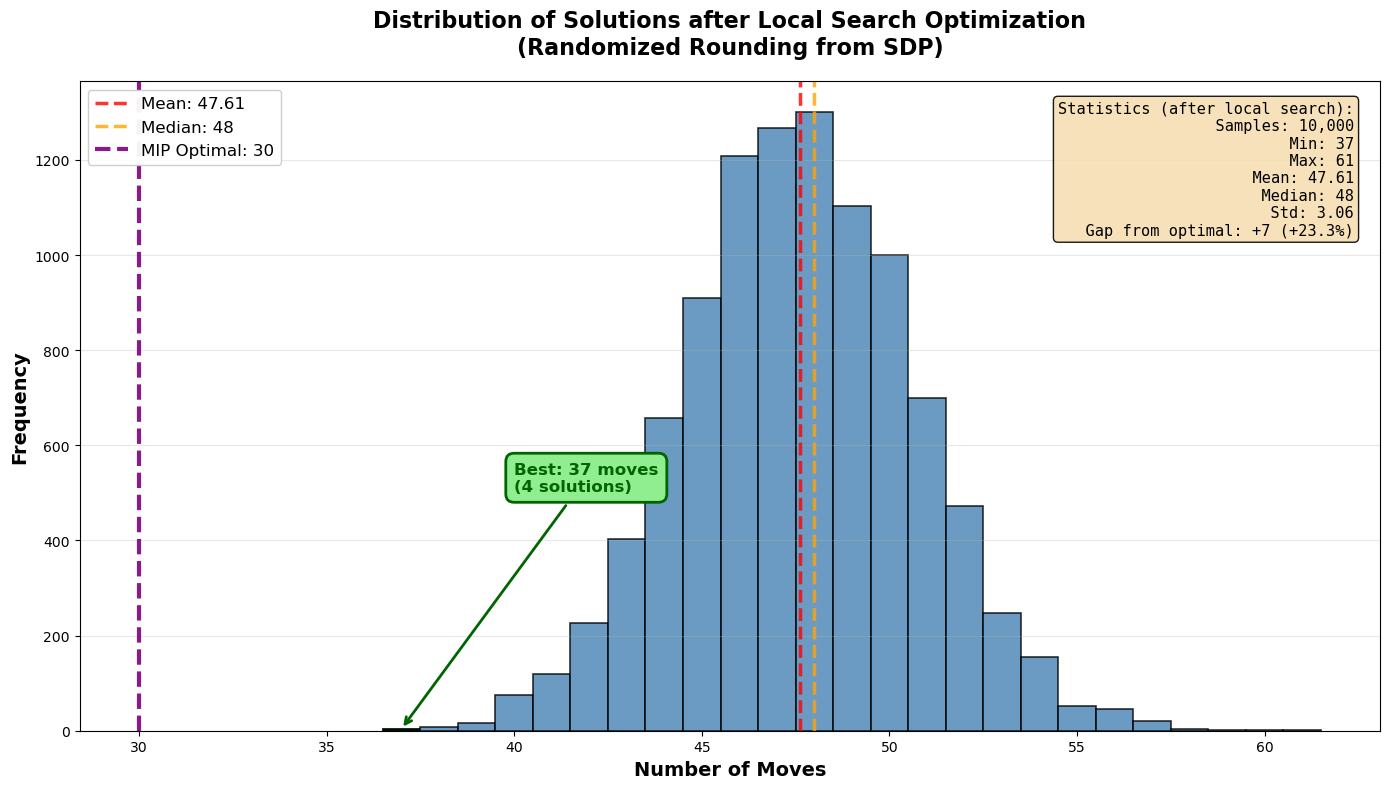

✓ Plot 2 saved: local_search_comparison.png


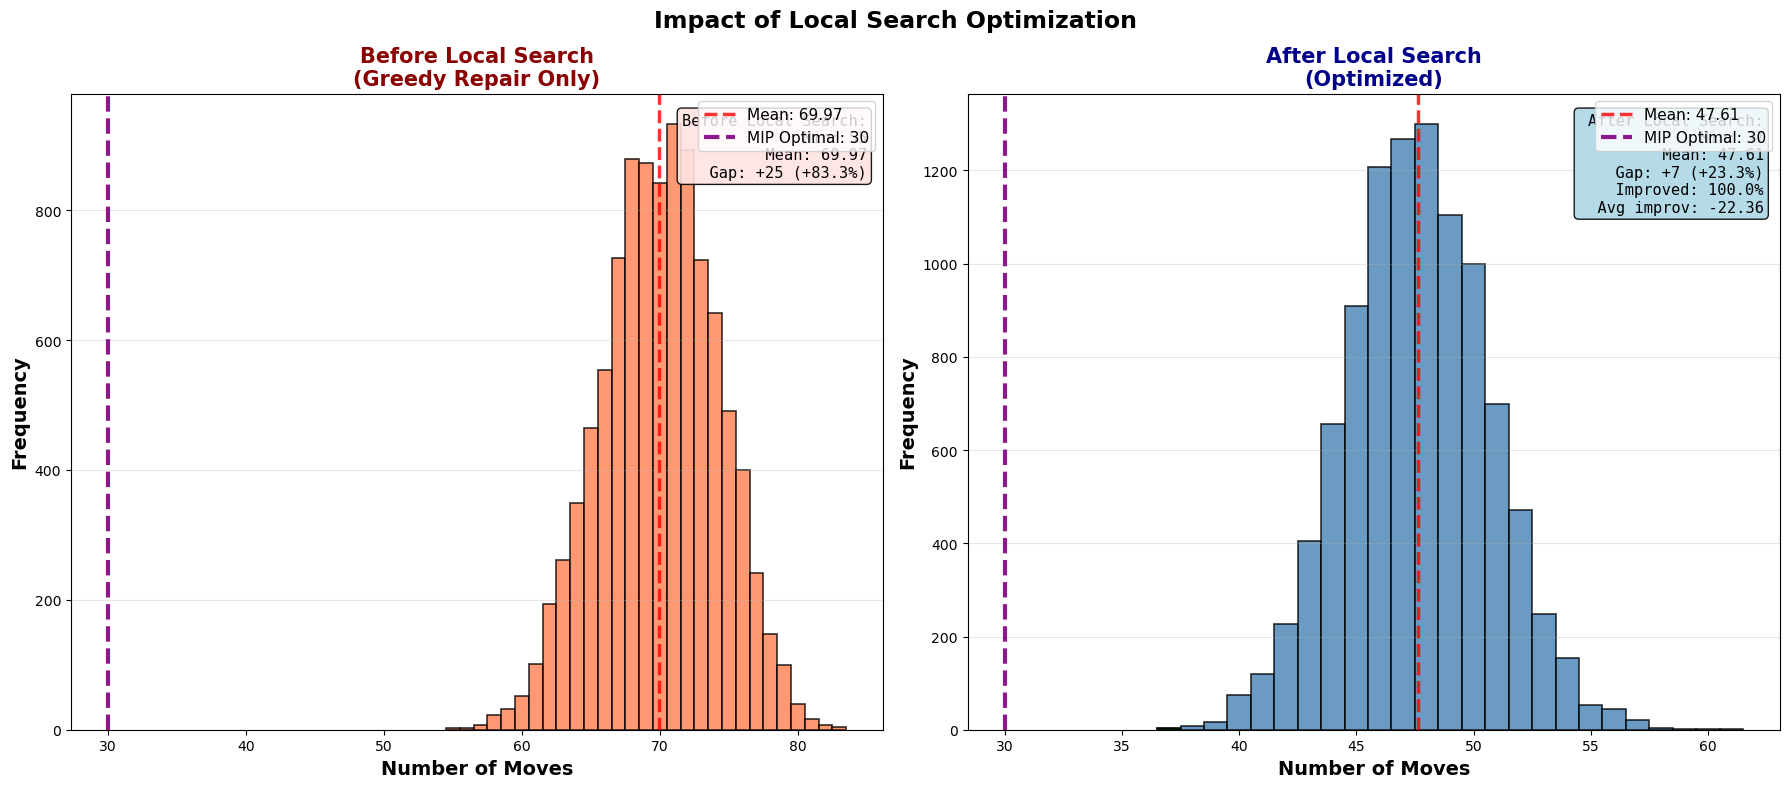

✓ Plot 3 saved: local_search_improvements.png


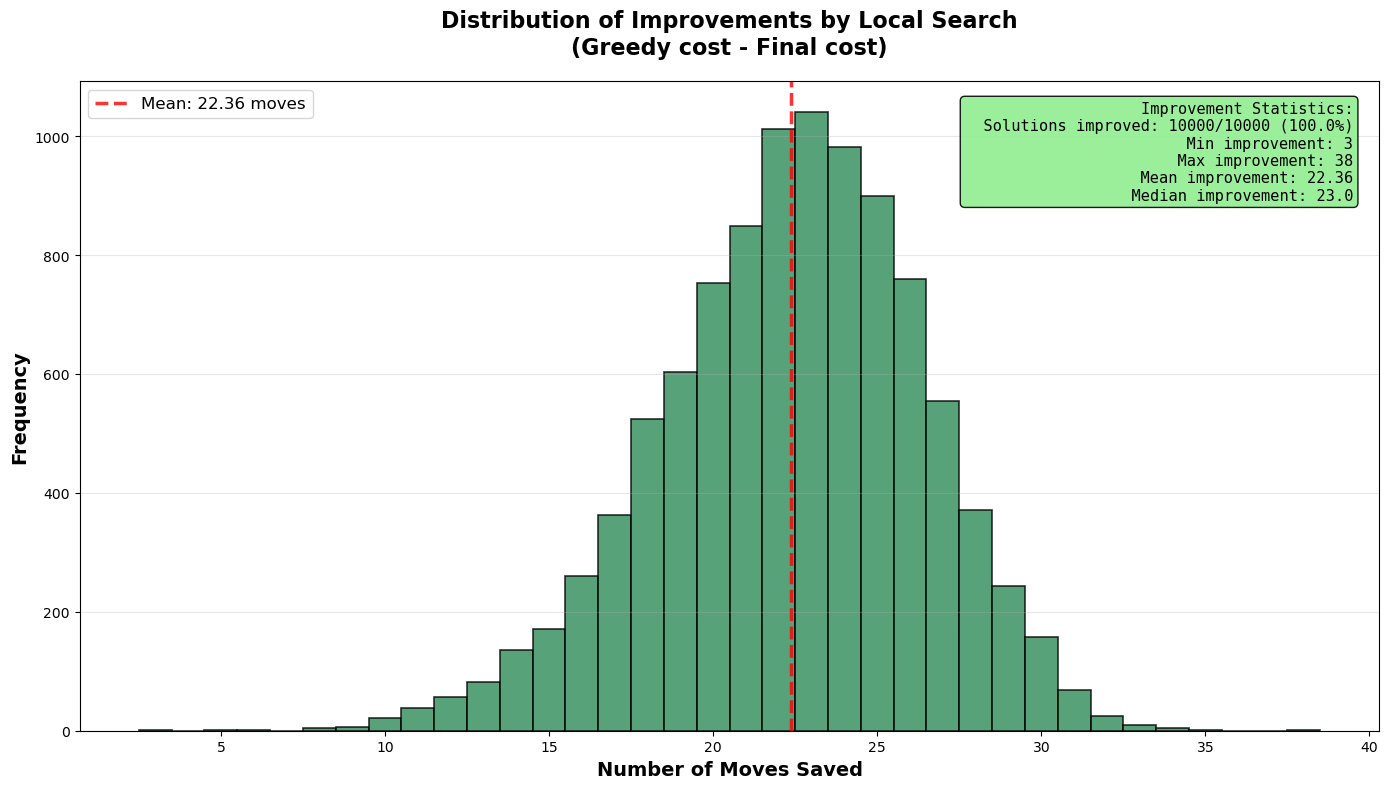

✓ Plot 4 saved: local_search_cumulative.png


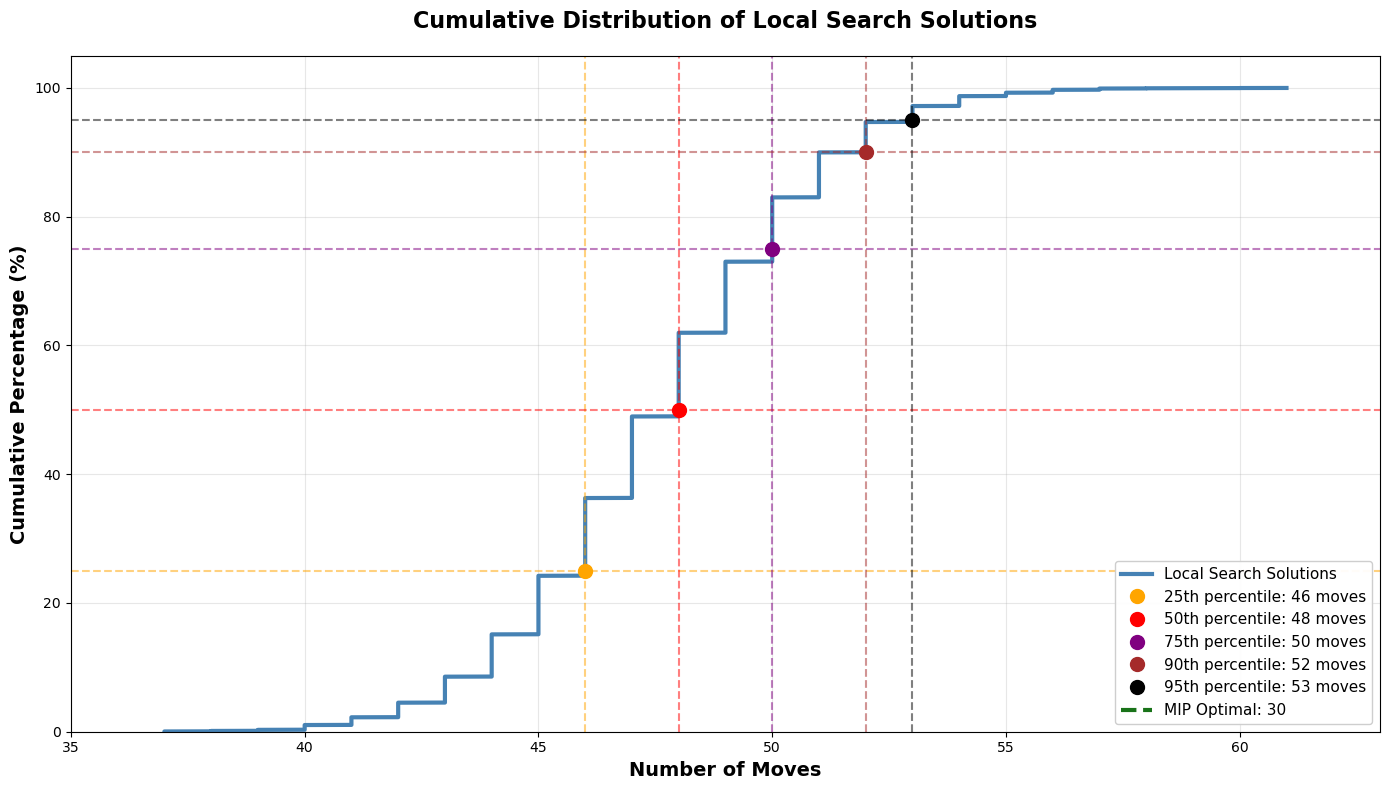


VISUALIZATION SUMMARY

Generated 4 plots:
  1. local_search_distribution.png - Main distribution histogram
  2. local_search_comparison.png - Before/after comparison
  3. local_search_improvements.png - Improvement distribution
  4. local_search_cumulative.png - Cumulative distribution

Key results:
  Best solution: 37 moves (Gap: +7 from optimal)
  Average solution: 47.61 moves
  Solutions improved: 100.0%
  Average improvement: 22.36 moves


In [58]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ============================================================================
# LOCAL SEARCH SOLUTION DISTRIBUTION VISUALIZATION
# ============================================================================

# Assuming 'solutions' list is available from the main randomized rounding code
# Each solution has structure: {'x': array, 'cost': int, 'cost_greedy': int, 'improved': bool}

if 'solutions' in locals() and len(solutions) > 0:
    print("\n" + "="*70)
    print("GENERATING LOCAL SEARCH DISTRIBUTION PLOTS")
    print("="*70)
    
    # Extract costs
    costs_after_ls = [sol['cost'] for sol in solutions]
    costs_greedy = [sol['cost_greedy'] for sol in solutions]
    improvements = [sol['cost_greedy'] - sol['cost'] for sol in solutions if sol['improved']]
    
    # Count frequencies
    cost_counts = Counter(costs_after_ls)
    greedy_counts = Counter(costs_greedy)
    
    # Statistics
    min_cost = min(costs_after_ls)
    max_cost = max(costs_after_ls)
    mean_cost = np.mean(costs_after_ls)
    median_cost = np.median(costs_after_ls)
    std_cost = np.std(costs_after_ls)
    
    min_greedy = min(costs_greedy)
    mean_greedy = np.mean(costs_greedy)
    
    improved_count = sum(1 for sol in solutions if sol['improved'])
    improved_pct = 100 * improved_count / len(solutions)
    
    mean_improvement = np.mean(improvements) if improvements else 0
    max_improvement = max(improvements) if improvements else 0
    
    # ========================================================================
    # FIGURE 1: HISTOGRAM OF COSTS AFTER LOCAL SEARCH
    # ========================================================================
    
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    
    # Create histogram
    bins = np.arange(min_cost - 0.5, max_cost + 1.5, 1)
    counts, edges, patches = ax1.hist(costs_after_ls, bins=bins, 
                                       color='steelblue', 
                                       edgecolor='black', 
                                       alpha=0.8,
                                       linewidth=1.2)
    
    # Highlight best solution
    best_cost = min_cost
    for patch in patches:
        if abs(patch.get_x() + patch.get_width()/2 - best_cost) < 0.5:
            patch.set_facecolor('darkgreen')
            patch.set_alpha(1.0)
    
    # Add vertical lines for statistics
    ax1.axvline(mean_cost, color='red', linestyle='--', linewidth=2.5, 
               label=f'Mean: {mean_cost:.2f}', alpha=0.8)
    ax1.axvline(median_cost, color='orange', linestyle='--', linewidth=2.5, 
               label=f'Median: {median_cost:.0f}', alpha=0.8)
    ax1.axvline(30, color='purple', linestyle='--', linewidth=3, 
               label='MIP Optimal: 30', alpha=0.9)
    
    # Add text box with statistics
    stats_text = f'Statistics (after local search):\n'
    stats_text += f'  Samples: {len(solutions):,}\n'
    stats_text += f'  Min: {min_cost}\n'
    stats_text += f'  Max: {max_cost}\n'
    stats_text += f'  Mean: {mean_cost:.2f}\n'
    stats_text += f'  Median: {median_cost:.0f}\n'
    stats_text += f'  Std: {std_cost:.2f}\n'
    stats_text += f'  Gap from optimal: +{min_cost - 30} (+{100*(min_cost-30)/30:.1f}%)'
    
    ax1.text(0.98, 0.97, stats_text,
            transform=ax1.transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
            family='monospace')
    
    # Labels and title
    ax1.set_xlabel('Number of Moves', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax1.set_title('Distribution of Solutions after Local Search Optimization\n(Randomized Rounding from SDP)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax1.legend(loc='upper left', fontsize=12, framealpha=0.95)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Annotate best solution
    best_count = cost_counts[best_cost]
    ax1.annotate(f'Best: {best_cost} moves\n({best_count} solutions)',
                xy=(best_cost, best_count),
                xytext=(best_cost + 3, best_count + len(solutions)*0.05),
                fontsize=12,
                fontweight='bold',
                color='darkgreen',
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', 
                         edgecolor='darkgreen', linewidth=2))
    
    plt.tight_layout()
    filename1 = 'local_search_distribution.png'
    plt.savefig(filename1, dpi=200, bbox_inches='tight')
    print(f"\n✓ Plot 1 saved: {filename1}")
    plt.show()
    
    # ========================================================================
    # FIGURE 2: COMPARISON BEFORE/AFTER LOCAL SEARCH
    # ========================================================================
    
    fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Left: Before local search (greedy only)
    bins_greedy = np.arange(min_greedy - 0.5, max(costs_greedy) + 1.5, 1)
    ax2a.hist(costs_greedy, bins=bins_greedy, 
             color='coral', 
             edgecolor='black', 
             alpha=0.8,
             linewidth=1.2)
    
    ax2a.axvline(mean_greedy, color='red', linestyle='--', linewidth=2.5, 
                label=f'Mean: {mean_greedy:.2f}', alpha=0.8)
    ax2a.axvline(30, color='purple', linestyle='--', linewidth=3, 
                label='MIP Optimal: 30', alpha=0.9)
    
    stats_greedy = f'Before Local Search:\n'
    stats_greedy += f'  Min: {min_greedy}\n'
    stats_greedy += f'  Mean: {mean_greedy:.2f}\n'
    stats_greedy += f'  Gap: +{min_greedy - 30} (+{100*(min_greedy-30)/30:.1f}%)'
    
    ax2a.text(0.98, 0.97, stats_greedy,
             transform=ax2a.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             fontsize=11,
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.9),
             family='monospace')
    
    ax2a.set_xlabel('Number of Moves', fontsize=14, fontweight='bold')
    ax2a.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax2a.set_title('Before Local Search\n(Greedy Repair Only)', 
                  fontsize=15, fontweight='bold', color='darkred')
    ax2a.legend(loc='upper right', fontsize=11)
    ax2a.grid(True, alpha=0.3, axis='y')
    
    # Right: After local search
    bins_after = np.arange(min_cost - 0.5, max_cost + 1.5, 1)
    counts_after, edges_after, patches_after = ax2b.hist(costs_after_ls, bins=bins_after, 
                                                         color='steelblue', 
                                                         edgecolor='black', 
                                                         alpha=0.8,
                                                         linewidth=1.2)
    
    # Highlight best
    for patch in patches_after:
        if abs(patch.get_x() + patch.get_width()/2 - best_cost) < 0.5:
            patch.set_facecolor('darkgreen')
            patch.set_alpha(1.0)
    
    ax2b.axvline(mean_cost, color='red', linestyle='--', linewidth=2.5, 
                label=f'Mean: {mean_cost:.2f}', alpha=0.8)
    ax2b.axvline(30, color='purple', linestyle='--', linewidth=3, 
                label='MIP Optimal: 30', alpha=0.9)
    
    stats_after = f'After Local Search:\n'
    stats_after += f'  Min: {min_cost}\n'
    stats_after += f'  Mean: {mean_cost:.2f}\n'
    stats_after += f'  Gap: +{min_cost - 30} (+{100*(min_cost-30)/30:.1f}%)\n'
    stats_after += f'  Improved: {improved_pct:.1f}%\n'
    stats_after += f'  Avg improv: -{mean_improvement:.2f}'
    
    ax2b.text(0.98, 0.97, stats_after,
             transform=ax2b.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9),
             family='monospace')
    
    ax2b.set_xlabel('Number of Moves', fontsize=14, fontweight='bold')
    ax2b.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax2b.set_title('After Local Search\n(Optimized)', 
                  fontsize=15, fontweight='bold', color='darkblue')
    ax2b.legend(loc='upper right', fontsize=11)
    ax2b.grid(True, alpha=0.3, axis='y')
    
    # Overall title
    fig2.suptitle('Impact of Local Search Optimization', 
                 fontsize=17, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    filename2 = 'local_search_comparison.png'
    plt.savefig(filename2, dpi=200, bbox_inches='tight')
    print(f"✓ Plot 2 saved: {filename2}")
    plt.show()
    
    # ========================================================================
    # FIGURE 3: IMPROVEMENT DISTRIBUTION
    # ========================================================================
    
    if improvements:
        fig3, ax3 = plt.subplots(figsize=(14, 8))
        
        bins_improv = np.arange(min(improvements) - 0.5, max(improvements) + 1.5, 1)
        ax3.hist(improvements, bins=bins_improv, 
                color='seagreen', 
                edgecolor='black', 
                alpha=0.8,
                linewidth=1.2)
        
        ax3.axvline(mean_improvement, color='red', linestyle='--', linewidth=2.5, 
                   label=f'Mean: {mean_improvement:.2f} moves', alpha=0.8)
        
        stats_improv = f'Improvement Statistics:\n'
        stats_improv += f'  Solutions improved: {improved_count}/{len(solutions)} ({improved_pct:.1f}%)\n'
        stats_improv += f'  Min improvement: {min(improvements)}\n'
        stats_improv += f'  Max improvement: {max_improvement}\n'
        stats_improv += f'  Mean improvement: {mean_improvement:.2f}\n'
        stats_improv += f'  Median improvement: {np.median(improvements):.1f}'
        
        ax3.text(0.98, 0.97, stats_improv,
                transform=ax3.transAxes,
                verticalalignment='top',
                horizontalalignment='right',
                fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
                family='monospace')
        
        ax3.set_xlabel('Number of Moves Saved', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Frequency', fontsize=14, fontweight='bold')
        ax3.set_title('Distribution of Improvements by Local Search\n(Greedy cost - Final cost)', 
                     fontsize=16, fontweight='bold', pad=20)
        ax3.legend(loc='upper left', fontsize=12)
        ax3.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        filename3 = 'local_search_improvements.png'
        plt.savefig(filename3, dpi=200, bbox_inches='tight')
        print(f"✓ Plot 3 saved: {filename3}")
        plt.show()
    
    # ========================================================================
    # FIGURE 4: CONVERGENCE PLOT (CUMULATIVE DISTRIBUTION)
    # ========================================================================
    
    fig4, ax4 = plt.subplots(figsize=(14, 8))
    
    # Sort costs
    sorted_costs = np.sort(costs_after_ls)
    cumulative = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs) * 100
    
    ax4.plot(sorted_costs, cumulative, 
            color='steelblue', 
            linewidth=3,
            label='Local Search Solutions')
    
    # Add horizontal lines for key percentiles
    percentiles = [25, 50, 75, 90, 95]
    colors_perc = ['orange', 'red', 'purple', 'brown', 'black']
    
    for pct, color in zip(percentiles, colors_perc):
        value = np.percentile(costs_after_ls, pct)
        ax4.axhline(pct, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
        ax4.axvline(value, color=color, linestyle='--', linewidth=1.5, alpha=0.5)
        ax4.plot(value, pct, 'o', color=color, markersize=10, 
                label=f'{pct}th percentile: {value:.0f} moves')
    
    # Optimal line
    ax4.axvline(30, color='darkgreen', linestyle='--', linewidth=3, 
               label='MIP Optimal: 30', alpha=0.9)
    
    ax4.set_xlabel('Number of Moves', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Cumulative Percentage (%)', fontsize=14, fontweight='bold')
    ax4.set_title('Cumulative Distribution of Local Search Solutions', 
                 fontsize=16, fontweight='bold', pad=20)
    ax4.legend(loc='lower right', fontsize=11, framealpha=0.95)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([min_cost - 2, max_cost + 2])
    ax4.set_ylim([0, 105])
    
    plt.tight_layout()
    filename4 = 'local_search_cumulative.png'
    plt.savefig(filename4, dpi=200, bbox_inches='tight')
    print(f"✓ Plot 4 saved: {filename4}")
    plt.show()
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*70)
    print("VISUALIZATION SUMMARY")
    print("="*70)
    print(f"\nGenerated 4 plots:")
    print(f"  1. {filename1} - Main distribution histogram")
    print(f"  2. {filename2} - Before/after comparison")
    print(f"  3. {filename3} - Improvement distribution")
    print(f"  4. {filename4} - Cumulative distribution")
    
    print(f"\nKey results:")
    print(f"  Best solution: {min_cost} moves (Gap: +{min_cost-30} from optimal)")
    print(f"  Average solution: {mean_cost:.2f} moves")
    print(f"  Solutions improved: {improved_pct:.1f}%")
    print(f"  Average improvement: {mean_improvement:.2f} moves")
    
else:
    print("\n" + "="*70)
    print("ERROR: 'solutions' list not found")
    print("="*70)
    print("\nPlease run the randomized rounding with local search code first.")
    print("The 'solutions' list should contain dictionaries with keys:")
    print("  - 'x': solution vector")
    print("  - 'cost': final cost after local search")
    print("  - 'cost_greedy': initial greedy cost")
    print("  - 'improved': boolean indicating if local search helped")

### 8.4 Visualization of the best integer solution after randomized rounding with repair


GENERATING VISUALIZATION - BEST LOCAL SEARCH SOLUTION

Calculating moves per phase...
  Phase 0→1: 9 moves
  Phase 1→2: 8 moves
  Phase 2→3: 7 moves
  Phase 3→4: 7 moves
  Phase 4→5: 6 moves
  TOTAL: 37 moves
  ✓ Consistent with stored cost


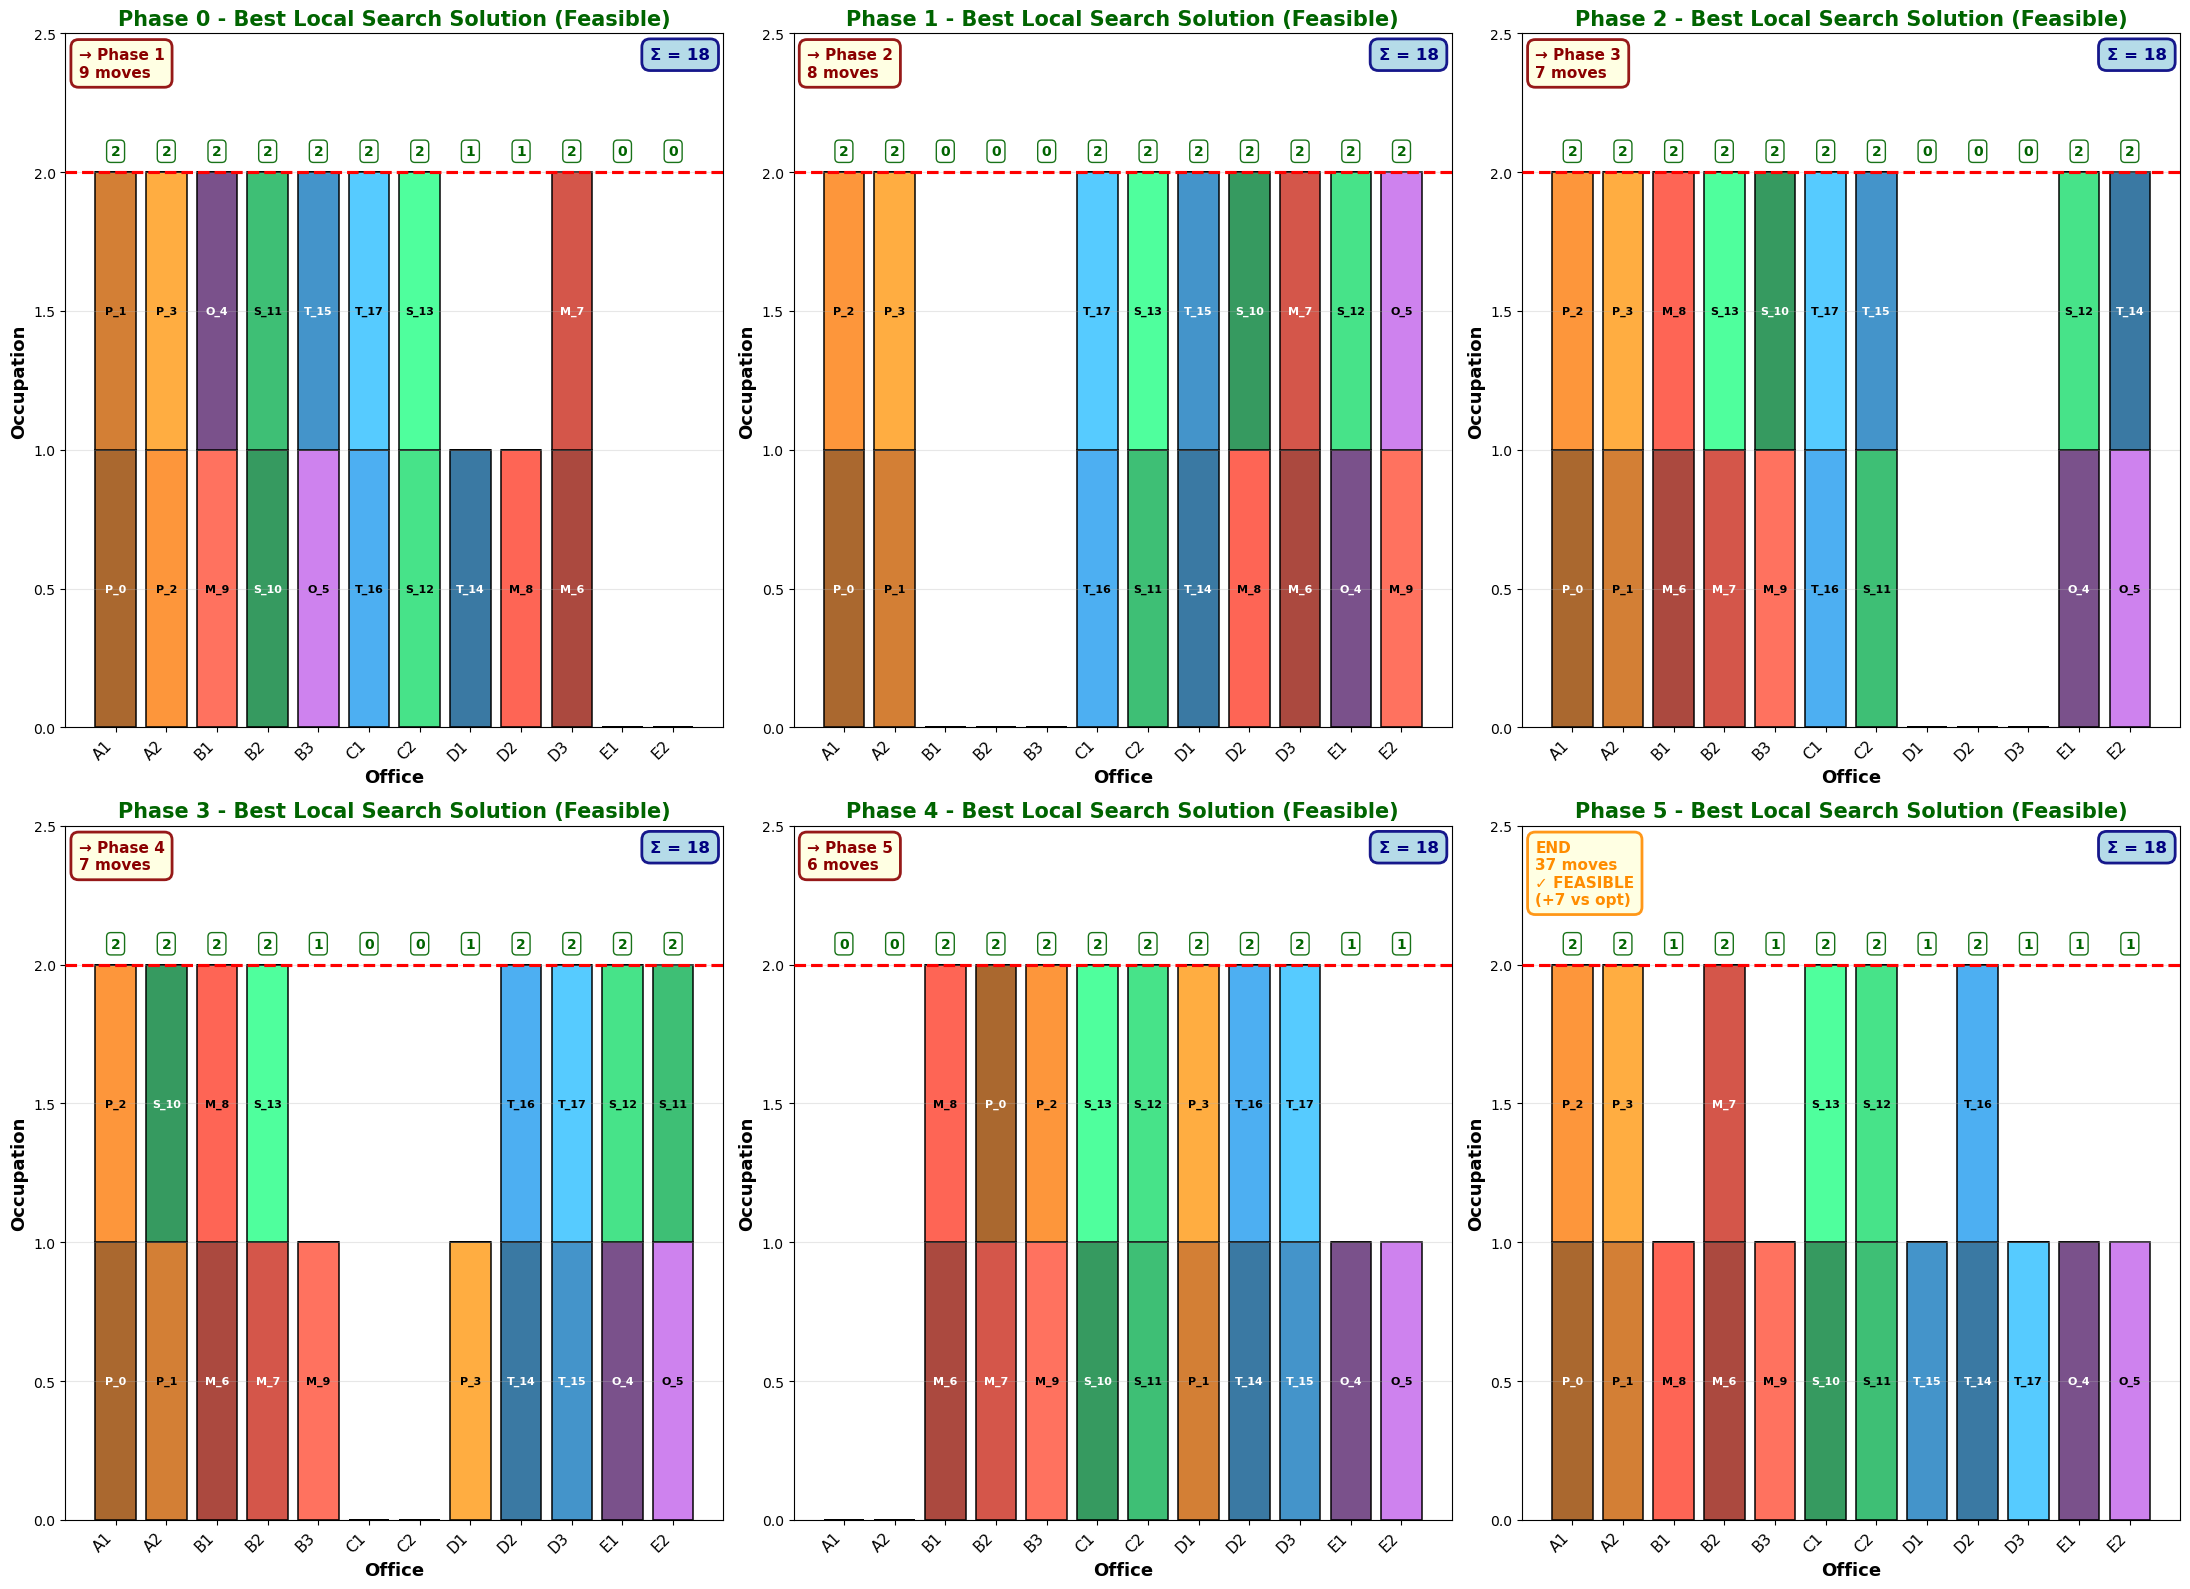


✓ Plot saved: office_occupation_best_local_search_solution.png

DETAILED SOLUTION ANALYSIS

Moves per person:
  P_0: 2 moves (A1 → A1 → A1 → A1 → B2 → A1)
  P_1: 3 moves (A1 → A2 → A2 → A2 → D1 → A2)
  P_2: 3 moves (A2 → A1 → A1 → A1 → B3 → A1)
  P_3: 2 moves (A2 → A2 → A2 → D1 → D1 → A2)
  O_4: 1 moves (B1 → E1 → E1 → E1 → E1 → E1)
  O_5: 1 moves (B3 → E2 → E2 → E2 → E2 → E2)
  M_6: 2 moves (D3 → D3 → B1 → B1 → B1 → B2)
  M_7: 1 moves (D3 → D3 → B2 → B2 → B2 → B2)
  M_8: 1 moves (D2 → D2 → B1 → B1 → B1 → B1)
  M_9: 2 moves (B1 → E2 → B3 → B3 → B3 → B3)
  S_10: 4 moves (B2 → D2 → B3 → A2 → C1 → C1)
  S_11: 3 moves (B2 → C2 → C2 → E2 → C2 → C2)
  S_12: 2 moves (C2 → E1 → E1 → E1 → C2 → C2)
  S_13: 2 moves (C2 → C2 → B2 → B2 → C1 → C1)
  T_14: 2 moves (D1 → D1 → E2 → D2 → D2 → D2)
  T_15: 4 moves (B3 → D1 → C2 → D3 → D3 → D1)
  T_16: 1 moves (C1 → C1 → C1 → D2 → D2 → D2)
  T_17: 1 moves (C1 → C1 → C1 → D3 → D3 → D3)

Moves per service:
  Presidency           (P): 10 moves (avg: 2.5)
  M

In [57]:
# ============================================================================
# VISUALIZATION OF BEST SOLUTION (RANDOMIZED ROUNDING WITH LOCAL SEARCH)
# ============================================================================

if best_solution is not None:
    print("\n" + "="*70)
    print("GENERATING VISUALIZATION - BEST LOCAL SEARCH SOLUTION")
    print("="*70)
    
    # Reconstruct z from binary x
    z_best = np.zeros((K, I, P))
    
    for k in range(K):
        for i in range(I):
            for p in range(P):
                z_best[k, i, p] = best_solution['x'][phi(k, i, p)]
    
    # CALCULATE MOVES PER PHASE
    print("\nCalculating moves per phase...")
    moves_per_phase = []
    
    for p in range(P-1):
        moves = 0
        for k in range(K):
            office_p = -1
            for i in range(I):
                if z_best[k, i, p] > 0.5:
                    office_p = i
                    break
            
            office_p1 = -1
            for i in range(I):
                if z_best[k, i, p+1] > 0.5:
                    office_p1 = i
                    break
            
            if office_p != office_p1 and office_p >= 0 and office_p1 >= 0:
                moves += 1
        
        moves_per_phase.append(moves)
        print(f"  Phase {p}→{p+1}: {moves} moves")
    
    total_moves_best = sum(moves_per_phase)
    print(f"  TOTAL: {total_moves_best} moves")
    
    if total_moves_best != best_solution['cost']:
        print(f"  ⚠️ INCONSISTENCY: stored cost = {best_solution['cost']}")
    else:
        print(f"  ✓ Consistent with stored cost")
    
    # Wrapper class for visualization
    class BestSolutionWrapper:
        def __init__(self, z_array):
            self.value = z_array
    
    z_vis = BestSolutionWrapper(z_best)
    
    # ========================================================================
    # VISUALIZATION
    # ========================================================================
    
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    
    # Base colors by service
    service_colors_base = {
        'M': '#e74c3c',  # Red
        'P': '#e67e22',  # Orange
        'T': '#3498db',  # Blue
        'S': '#2ecc71',  # Green
        'O': '#9b59b6'   # Purple
    }
    
    def generate_color_shades(base_color, n_shades):
        """Generate n shades of a base color"""
        if n_shades == 1:
            return [base_color]
        
        rgb = mcolors.hex2color(base_color)
        shades = []
        for i in range(n_shades):
            factor = 0.7 + (i / max(n_shades - 1, 1)) * 0.6
            new_rgb = tuple(min(1.0, c * factor) for c in rgb)
            shades.append(mcolors.rgb2hex(new_rgb))
        
        return shades
    
    # Map person -> service and person -> color
    person_service = {}
    person_color = {}
    
    for service, people in services.items():
        base_color = service_colors_base[service]
        n_people = len(people)
        colors = generate_color_shades(base_color, n_people)
        
        for idx, k in enumerate(people):
            person_service[k] = service
            person_color[k] = colors[idx]
    
    service_names = {
        'M': 'Mathematics',
        'P': 'Presidency',
        'T': 'Theoretical CS',
        'S': 'Students',
        'O': 'Optimization'
    }
    
    # Office occupation per phase
    fig, axes = plt.subplots(2, 3, figsize=(22, 16))
    axes = axes.flatten()
    
    for p in range(P):
        ax = axes[p]
        
        office_people = {i: [] for i in range(I)}
        office_total = np.zeros(I)
        
        for i in range(I):
            for k in range(K):
                occ = z_vis.value[k, i, p]
                if occ > 0.5:
                    office_people[i].append((k, 1.0))
                    office_total[i] += 1
            
            office_people[i].sort(key=lambda x: (person_service[x[0]], x[0]))
        
        x_pos = np.arange(I)
        bottom = np.zeros(I)
        plotted_people = set()
        
        for i in range(I):
            for k, occ in office_people[i]:
                service = person_service[k]
                color = person_color[k]
                
                values = np.zeros(I)
                values[i] = occ
                
                label = f'{service}_{k}' if k not in plotted_people else None
                if k not in plotted_people:
                    plotted_people.add(k)
                
                bars = ax.bar(x_pos, values, bottom=bottom, 
                              color=color, 
                              alpha=0.9, 
                              edgecolor='black',
                              linewidth=1.2,
                              label=label)
                
                y_pos = bottom[i] + occ/2
                text_color = 'white' if sum(mcolors.hex2color(color)[j]*[0.299,0.587,0.114][j] for j in range(3)) < 0.5 else 'black'
                
                ax.text(i, y_pos, f'{service}_{k}', 
                       ha='center', va='center',
                       fontsize=8, fontweight='bold',
                       color=text_color)
                
                bottom[i] += occ
        
        # Max capacity line
        ax.axhline(y=2, color='red', linestyle='--', linewidth=2.25, label='Max capacity (2)', zorder=10)
        
        # Show occupation above the line
        y_align = 2.05
        for i in range(I):
            occ_total = int(office_total[i])
            text_color = 'red' if occ_total > 2 else 'darkgreen'
            fontweight = 'bold'
            
            ax.text(i, y_align, f'{occ_total}', 
                   ha='center', va='bottom',
                   fontsize=10, fontweight=fontweight,
                   color=text_color,
                   bbox=dict(boxstyle='round,pad=0.3', 
                             facecolor='white' if occ_total <= 2 else 'mistyrose',
                             edgecolor=text_color, 
                             linewidth=2 if occ_total > 2 else 1,
                             alpha=0.9))
        
        # Total occupation sum
        ax.text(0.98, 0.98, f'Σ = {int(office_total.sum())}', 
               transform=ax.transAxes,
               ha='right', va='top',
               fontsize=12, fontweight='bold',
               color='navy',
               bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor='lightblue',
                         edgecolor='navy', 
                         linewidth=2,
                         alpha=0.9))
        
        # Display moves for this transition
        if p < P-1:
            moves_transition = moves_per_phase[p]
            ax.text(0.02, 0.98, f'→ Phase {p+1}\n{moves_transition} moves', 
                   transform=ax.transAxes,
                   ha='left', va='top',
                   fontsize=11, fontweight='bold',
                   color='darkred',
                   bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor='lightyellow',
                             edgecolor='darkred', 
                             linewidth=2,
                             alpha=0.9))
        else:
            # Last phase, show total and status
            if total_moves_best == 30:
                status_text = "✓ OPTIMAL!"
                status_color = 'darkgreen'
                status_bg = 'lightgreen'
            elif total_moves_best < 30:
                status_text = f"✓ BETTER!\n(opt = 30)"
                status_color = 'darkblue'
                status_bg = 'lightcyan'
            else:
                gap = total_moves_best - 30
                status_text = f"✓ FEASIBLE\n(+{gap} vs opt)"
                status_color = 'darkorange'
                status_bg = 'lightyellow'
            
            ax.text(0.02, 0.98, f'END\n{total_moves_best} moves\n{status_text}', 
                   transform=ax.transAxes,
                   ha='left', va='top',
                   fontsize=11, fontweight='bold',
                   color=status_color,
                   bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor=status_bg,
                             edgecolor=status_color, 
                             linewidth=2,
                             alpha=0.9))
        
        ax.set_xlabel('Office', fontsize=13, fontweight='bold')
        ax.set_ylabel('Occupation', fontsize=13, fontweight='bold')
        ax.set_title(f'Phase {p} - Best Local Search Solution (Feasible)', fontsize=15, fontweight='bold', color='darkgreen')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(offices, rotation=45, ha='right', fontsize=11)
        ax.set_ylim([0, 2.5])
        ax.grid(True, alpha=0.3, axis='y', zorder=0)
        
        for i in range(I):
            if office_total[i] > 2:
                ax.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 2.5, fill=False, edgecolor='red', linewidth=3, linestyle=':', zorder=11))
                ax.text(i, 2.55, '⚠', ha='center', va='top', fontsize=18, color='red', fontweight='bold')
    
    plt.tight_layout()
    
    filename = 'office_occupation_best_local_search_solution.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot saved: {filename}")
    
    # ========================================================================
    # DETAILED SOLUTION ANALYSIS
    # ========================================================================
    
    print("\n" + "="*70)
    print("DETAILED SOLUTION ANALYSIS")
    print("="*70)
    
    print("\nMoves per person:")
    moves_per_person = {}
    
    for k in range(K):
        moves = 0
        path = []
        
        for p in range(P):
            for i in range(I):
                if z_best[k, i, p] > 0.5:
                    path.append(offices[i])
                    if p > 0 and path[-1] != path[-2]:
                        moves += 1
                    break
        
        moves_per_person[k] = (moves, path)
        service = person_service[k]
        path_str = ' → '.join(path)
        print(f"  {service}_{k}: {moves} moves ({path_str})")
    
    print("\nMoves per service:")
    for service in ['P', 'M', 'T', 'S', 'O']:
        people = services[service]
        total_moves = sum(moves_per_person[k][0] for k in people)
        avg_moves = total_moves / len(people)
        print(f"  {service_names[service]:20s} ({service}): {total_moves:2d} moves (avg: {avg_moves:.1f})")
    
    # Verify constraints
    print("\n" + "="*70)
    print("CONSTRAINT CHECK")
    print("="*70)
    
    all_ok = True
    
    # C1: Each person in exactly one office
    print("\nC1 - One person/one office:")
    violations_c1 = 0
    for k in range(K):
        for p in range(P):
            sum_x = sum(z_best[k, i, p] for i in range(I))
            if abs(sum_x - 1) > 1e-6:
                violations_c1 += 1
                if violations_c1 <= 3:
                    print(f"  ✗ Person {k}, phase {p}: sum = {sum_x}")
                all_ok = False
    print("  ✓ All persons assigned to exactly one office" if violations_c1 == 0 else f"  ✗ {violations_c1} violations detected")
    
    # C2: Office capacity
    print("\nC2 - Office capacity (max 2):")
    violations_c2 = 0
    for i in range(I):
        for p in range(P):
            sum_x = sum(z_best[k, i, p] for k in range(K))
            if sum_x > 2 + 1e-6:
                violations_c2 += 1
                if violations_c2 <= 3:
                    print(f"  ✗ Office {offices[i]}, phase {p}: occupation = {sum_x}")
                all_ok = False
    print("  ✓ No office over-occupied" if violations_c2 == 0 else f"  ✗ {violations_c2} violations detected")
    
    # C4: Closed offices
    print("\nC4 - Closed offices:")
    violations_c4 = 0
    for p in range(P):
        if p in closed_offices:
            for bf in closed_offices[p]:
                i = office_idx[bf]
                for k in range(K):
                    if z_best[k, i, p] > 1e-6:
                        violations_c4 += 1
                        if violations_c4 <= 3:
                            print(f"  ✗ Office {bf} closed at phase {p}, but person {k} present")
                        all_ok = False
    print("  ✓ No one in closed offices" if violations_c4 == 0 else f"  ✗ {violations_c4} violations detected")
    
    # C5: Initial positions
    print("\nC5 - Initial positions (phase 0):")
    violations_c5 = 0
    for k in range(K):
        i_init = office_idx[initial_positions[k]]
        if z_best[k, i_init, 0] < 1 - 1e-6:
            violations_c5 += 1
            if violations_c5 <= 3:
                real_office = None
                for i in range(I):
                    if z_best[k, i, 0] > 0.5:
                        real_office = offices[i]
                print(f"  ✗ Person {k} should be in {initial_positions[k]}, but is in {real_office}")
            all_ok = False
    print("  ✓ All initial positions respected" if violations_c5 == 0 else f"  ✗ {violations_c5} violations detected")
    
    # C6: Final assignments
    print("\nC6 - Final assignments (phase 5):")
    violations_c6 = 0
    for service, final_offices in final_allocations.items():
        people = services[service]
        office_indices = [office_idx[b] for b in final_offices]
        for k in people:
            sum_x = sum(z_best[k, i, 5] for i in office_indices)
            if abs(sum_x - 1) > 1e-6:
                violations_c6 += 1
                if violations_c6 <= 3:
                    real_office = None
                    for i in range(I):
                        if z_best[k, i, 5] > 0.5:
                            real_office = offices[i]
                    print(f"  ✗ Person {k} (service {service}) should be in {final_offices}, but is in {real_office}")
                all_ok = False
    print("  ✓ All final assignments respected" if violations_c6 == 0 else f"  ✗ {violations_c6} violations detected")
    
    # Final summary
    print("\n" + "="*70)
    print("FINAL SUMMARY - LOCAL SEARCH SOLUTION")
    print("="*70)
    
    print(f"\nMoves per phase:")
    for p in range(P-1):
        print(f"  Phase {p}→{p+1}: {moves_per_phase[p]} moves")
    print(f"\nTOTAL: {total_moves_best} moves")
    
    print(f"\nComparison:")
    print(f"  SDP bound (relaxation):      {problem.value:.2f}")
    print(f"  Best greedy (before LS):     {best_solution['cost_greedy']}")
    print(f"  Best with local search:      {total_moves_best}")
    print(f"  MIP optimal solution:        30")
    
    if best_solution['improved']:
        improvement = best_solution['cost_greedy'] - total_moves_best
        print(f"\n  Local search improvement: -{improvement} moves")
    
    if total_moves_best == 30:
        print(f"\n  🎉 OPTIMAL SOLUTION ACHIEVED BY RANDOMIZED ROUNDING + LOCAL SEARCH!")
    elif total_moves_best < 30:
        print(f"\n  ⚠️ Better than MIP optimal?")
        print(f"     → Check for errors in MIP or calculation")
    else:
        gap = total_moves_best - 30
        gap_pct = 100 * gap / 30
        print(f"\n  Gap: +{gap} moves (+{gap_pct:.1f}%)")
    
    print(f"\nFeasibility: {'✓ FEASIBLE SOLUTION' if all_ok else '✗ VIOLATIONS DETECTED'}")
    
    if not all_ok:
        print(f"\n⚠️ WARNING: Solution is not fully feasible!")
        print(f"   Some constraints are violated.")
    
    print("\n" + "="*70)

else:
    print("\nCannot generate visualization: no solution available")